In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler

current_dir = Path.cwd()
project_root = current_dir.parents[2]

full_set_path_HY3 = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/HY3/FULL_SET/'
full_set_path_HY4 = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/HY4/FULL_SET/'
full_set_path_MCID = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/MCID/FULL_SET/'

feature_selection_path_HY3 = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/HY3/FEATURE_SELECTION/'
feature_selection_path_HY4 = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/HY4/FEATURE_SELECTION/'
feature_selection_path_MCID = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/MCID/FEATURE_SELECTION/'


classification_models = {
    "decision_tree": DecisionTreeClassifier(random_state=42),

    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"

    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "xgboost": XGBClassifier(
    tree_method="hist",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
    ),

    "adaboost": AdaBoostClassifier(
        algorithm="SAMME",
        random_state=42
    ),

    "svm": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight="balanced"
    ),

    "knn": KNeighborsClassifier(
        n_jobs=-1
    ),

    "gaussian_nb": GaussianNB()

    
}

In [14]:
import json

with open(project_root/"SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    datos = json.load(archivo)

print(datos)


{'M_data': ['NP1COG_mean', 'NP1COG_min', 'NP1COG_max', 'NP1COG_var', 'NP1COG_std', 'NP1HALL_mean', 'NP1HALL_min', 'NP1HALL_max', 'NP1HALL_var', 'NP1HALL_std', 'NP1DPRS_mean', 'NP1DPRS_min', 'NP1DPRS_max', 'NP1DPRS_var', 'NP1DPRS_std', 'NP1ANXS_mean', 'NP1ANXS_min', 'NP1ANXS_max', 'NP1ANXS_var', 'NP1ANXS_std', 'NP1APAT_mean', 'NP1APAT_min', 'NP1APAT_max', 'NP1APAT_var', 'NP1APAT_std', 'NP1DDS_mean', 'NP1DDS_min', 'NP1DDS_max', 'NP1DDS_var', 'NP1DDS_std', 'NP1SLPN_mean', 'NP1SLPN_min', 'NP1SLPN_max', 'NP1SLPN_var', 'NP1SLPN_std', 'NP1SLPD_mean', 'NP1SLPD_min', 'NP1SLPD_max', 'NP1SLPD_var', 'NP1SLPD_std', 'NP1PAIN_mean', 'NP1PAIN_min', 'NP1PAIN_max', 'NP1PAIN_var', 'NP1PAIN_std', 'NP1URIN_mean', 'NP1URIN_min', 'NP1URIN_max', 'NP1URIN_var', 'NP1URIN_std', 'NP1CNST_mean', 'NP1CNST_min', 'NP1CNST_max', 'NP1CNST_var', 'NP1CNST_std', 'NP1LTHD_mean', 'NP1LTHD_min', 'NP1LTHD_max', 'NP1LTHD_var', 'NP1LTHD_std', 'NP1FATG_mean', 'NP1FATG_min', 'NP1FATG_max', 'NP1FATG_var', 'NP1FATG_std', 'NP2SPCH_m

In [15]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd


def evaluate_models_10x10_oof_and_test(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    scaler = StandardScaler(),
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
):
    y = y_df.iloc[:, 0].to_numpy()
    X = X_df.to_numpy()
    classes = np.unique(y)

    def build_pipeline(estimator):
        return Pipeline([
            ("scaler", scaler),
            ("model", clone(estimator)),
        ])

    def compute_metrics(y_true, y_pred, y_proba):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "AUC_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
            "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "AUC_weighted": roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"),
        }

    def summarize(metrics_list, suffix):
        df = pd.DataFrame(metrics_list)
        mean = df.mean()
        std = df.std(ddof=1)
        return {
            f"{col}_{suffix}": f"{mean[col]:.{decimals}f} ± {std[col]:.{decimals}f}"
            for col in df.columns
        }


    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    test_summary_rows = []
    cv_summary_rows = []

    for model_name, estimator in models.items():
        print(f"Evaluating {model_name}...")

        test_metrics_all = []
        cv_metrics_all = []

        for train_idx, test_idx in outer.split(X, y):
            X_train, y_train = X[train_idx], y[train_idx]
            X_test, y_test = X[test_idx], y[test_idx]

            inner = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=random_state
            )

            oof_pred = np.zeros(len(y_train), dtype=y_train.dtype)
            oof_proba = np.zeros((len(y_train), len(classes)))

            for tr_idx, val_idx in inner.split(X_train, y_train):
                X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
                X_val = X_train[val_idx]

                model = build_pipeline(estimator)
                model.fit(X_tr, y_tr)

                oof_pred[val_idx] = model.predict(X_val)

                fold_proba = model.predict_proba(X_val)
                fold_classes = model.named_steps["model"].classes_

                aligned_proba = np.zeros((len(val_idx), len(classes)))
                for j, cls in enumerate(fold_classes):
                    aligned_proba[:, np.where(classes == cls)[0][0]] = fold_proba[:, j]

                oof_proba[val_idx] = aligned_proba

            cv_metrics_all.append(compute_metrics(y_train, oof_pred, oof_proba))

            model_full = build_pipeline(estimator)
            model_full.fit(X_train, y_train)

            test_pred = model_full.predict(X_test)
            test_proba_raw = model_full.predict_proba(X_test)
            test_classes = model_full.named_steps["model"].classes_

            test_proba = np.zeros((len(y_test), len(classes)))
            for j, cls in enumerate(test_classes):
                test_proba[:, np.where(classes == cls)[0][0]] = test_proba_raw[:, j]

            test_metrics_all.append(compute_metrics(y_test, test_pred, test_proba))

        test_summary_rows.append(
            pd.Series(summarize(test_metrics_all, "Testing"), name=model_name)
        )
        cv_summary_rows.append(
            pd.Series(summarize(cv_metrics_all, "CV"), name=model_name)
        )

    df_test_summary = pd.DataFrame(test_summary_rows)[[
        "Accuracy_Testing",
        "Precision_macro_Testing", "Recall_macro_Testing", "F1_macro_Testing", "AUC_macro_Testing",
        "Precision_weighted_Testing", "Recall_weighted_Testing", "F1_weighted_Testing", "AUC_weighted_Testing"
    ]]

    df_cv_summary = pd.DataFrame(cv_summary_rows)[[
        "Accuracy_CV",
        "Precision_macro_CV", "Recall_macro_CV", "F1_macro_CV", "AUC_macro_CV",
        "Precision_weighted_CV", "Recall_weighted_CV", "F1_weighted_CV", "AUC_weighted_CV"
    ]]

    df_final_summary = pd.concat([df_test_summary, df_cv_summary], axis=1)
    return df_final_summary

# ALL SET OF FEATURES SC M AND NM

## HY3

In [16]:
X_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)
y_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_data shape:", X_HY3_data.shape)
print("y_HY3_data shape:", y_HY3_data.shape)
X_HY3_data.head()

X_HY3_data shape: (909, 931)
y_HY3_data shape: (909, 1)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,1.000000,1.000000,1.0,1.0,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,0,0,0.0,1.0,16.0,63.6,1.000000,0.666667,1.0,1.0,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0,0,0.0,1.0,15.0,77.0,0.666667,0.666667,1.0,1.0,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,0,0,1.0,1.0,22.0,78.8,1.000000,1.000000,1.0,1.0,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,0,0,1.0,1.0,18.0,74.7,1.000000,1.000000,1.0,1.0,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


In [17]:
df_HY3_full = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_data, 
    y_df=y_HY3_data, 
    models=classification_models, 
    random_state=42
)

df_HY3_full.to_csv(full_set_path_HY3 / "HY3_full_StandardScaler.csv", index=False)
df_HY3_full.head(10)



Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8256 ± 0.0249,0.6038 ± 0.0441,0.6067 ± 0.0462,0.6016 ± 0.0388,0.7500 ± 0.0262,0.8268 ± 0.0191,0.8256 ± 0.0249,0.8255 ± 0.0218,0.8398 ± 0.0201,0.8209 ± 0.0083,0.6252 ± 0.0275,0.6244 ± 0.0361,0.6225 ± 0.0294,0.7567 ± 0.0181,0.8210 ± 0.0099,0.8209 ± 0.0083,0.8206 ± 0.0086,0.8336 ± 0.0093
random_forest,0.8963 ± 0.0151,0.5977 ± 0.0101,0.6143 ± 0.0103,0.6056 ± 0.0102,0.9397 ± 0.0147,0.8739 ± 0.0146,0.8963 ± 0.0151,0.8846 ± 0.0149,0.9572 ± 0.0062,0.8986 ± 0.0069,0.5995 ± 0.0046,0.6169 ± 0.0048,0.6080 ± 0.0047,0.9514 ± 0.0070,0.8732 ± 0.0067,0.8986 ± 0.0069,0.8857 ± 0.0068,0.9595 ± 0.0031
extra_trees,0.8971 ± 0.0135,0.5989 ± 0.0087,0.6148 ± 0.0095,0.6065 ± 0.0090,0.9497 ± 0.0100,0.8755 ± 0.0129,0.8971 ± 0.0135,0.8858 ± 0.0131,0.9582 ± 0.0064,0.8984 ± 0.0053,0.5998 ± 0.0036,0.6169 ± 0.0036,0.6083 ± 0.0036,0.9543 ± 0.0105,0.8738 ± 0.0052,0.8984 ± 0.0053,0.8859 ± 0.0052,0.9606 ± 0.0033
xgboost,0.9007 ± 0.0145,0.8296 ± 0.1045,0.6903 ± 0.0452,0.7179 ± 0.0589,0.9320 ± 0.0183,0.8986 ± 0.0188,0.9007 ± 0.0145,0.8953 ± 0.0157,0.9580 ± 0.0070,0.8953 ± 0.0069,0.7714 ± 0.0791,0.6626 ± 0.0313,0.6794 ± 0.0425,0.9440 ± 0.0095,0.8882 ± 0.0104,0.8953 ± 0.0069,0.8882 ± 0.0078,0.9571 ± 0.0034
adaboost,0.8755 ± 0.0244,0.7191 ± 0.0958,0.6762 ± 0.0395,0.6820 ± 0.0429,0.9096 ± 0.0124,0.8758 ± 0.0211,0.8755 ± 0.0244,0.8739 ± 0.0219,0.9210 ± 0.0155,0.8725 ± 0.0052,0.7402 ± 0.0293,0.7082 ± 0.0352,0.7202 ± 0.0303,0.9178 ± 0.0136,0.8703 ± 0.0072,0.8725 ± 0.0052,0.8708 ± 0.0064,0.9222 ± 0.0101
svm,0.8905 ± 0.0169,0.5938 ± 0.0113,0.6106 ± 0.0117,0.6016 ± 0.0114,0.9426 ± 0.0164,0.8687 ± 0.0166,0.8905 ± 0.0169,0.8787 ± 0.0166,0.9517 ± 0.0086,0.8877 ± 0.0049,0.5920 ± 0.0033,0.6096 ± 0.0033,0.6007 ± 0.0033,0.9474 ± 0.0075,0.8626 ± 0.0047,0.8877 ± 0.0049,0.8750 ± 0.0048,0.9543 ± 0.0035
logistic_regression,0.8678 ± 0.0094,0.6930 ± 0.0662,0.6850 ± 0.0618,0.6860 ± 0.0606,0.9085 ± 0.0298,0.8657 ± 0.0117,0.8678 ± 0.0094,0.8656 ± 0.0101,0.9321 ± 0.0082,0.8722 ± 0.0121,0.7336 ± 0.0302,0.7021 ± 0.0284,0.7143 ± 0.0282,0.9125 ± 0.0159,0.8690 ± 0.0119,0.8722 ± 0.0121,0.8702 ± 0.0119,0.9361 ± 0.0092
knn,0.7447 ± 0.0182,0.5580 ± 0.1063,0.5244 ± 0.0199,0.5070 ± 0.0315,0.7830 ± 0.0190,0.7784 ± 0.0151,0.7447 ± 0.0182,0.7261 ± 0.0206,0.8632 ± 0.0191,0.7454 ± 0.0121,0.5540 ± 0.1056,0.5234 ± 0.0088,0.5041 ± 0.0126,0.7785 ± 0.0110,0.7701 ± 0.0131,0.7454 ± 0.0121,0.7265 ± 0.0134,0.8583 ± 0.0111
gaussian_nb,0.6978 ± 0.0815,0.5980 ± 0.0139,0.6086 ± 0.0705,0.5440 ± 0.0528,0.7712 ± 0.0428,0.8489 ± 0.0135,0.6978 ± 0.0815,0.7438 ± 0.0701,0.8711 ± 0.0112,0.7042 ± 0.0778,0.5991 ± 0.0201,0.6120 ± 0.0658,0.5543 ± 0.0532,0.7723 ± 0.0360,0.8435 ± 0.0185,0.7042 ± 0.0778,0.7518 ± 0.0628,0.8666 ± 0.0140


In [18]:
df_HY3_full_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_data, 
    y_df=y_HY3_data, 
    models=classification_models,
    scaler = MinMaxScaler(), 
    random_state=42
)
df_HY3_full_min_max.to_csv(full_set_path_HY3 / "HY3_full_MinMaxScaler.csv", index=False)
df_HY3_full_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8271 ± 0.0249,0.6130 ± 0.0469,0.6122 ± 0.0464,0.6084 ± 0.0403,0.7531 ± 0.0273,0.8286 ± 0.0202,0.8271 ± 0.0249,0.8271 ± 0.0223,0.8410 ± 0.0205,0.8206 ± 0.0075,0.6252 ± 0.0276,0.6241 ± 0.0362,0.6224 ± 0.0296,0.7565 ± 0.0183,0.8207 ± 0.0093,0.8206 ± 0.0075,0.8203 ± 0.0079,0.8332 ± 0.0088
random_forest,0.8978 ± 0.0141,0.5987 ± 0.0094,0.6154 ± 0.0096,0.6066 ± 0.0095,0.9397 ± 0.0155,0.8754 ± 0.0136,0.8978 ± 0.0141,0.8860 ± 0.0139,0.9570 ± 0.0066,0.8981 ± 0.0075,0.5991 ± 0.0051,0.6166 ± 0.0052,0.6077 ± 0.0051,0.9514 ± 0.0071,0.8727 ± 0.0073,0.8981 ± 0.0075,0.8852 ± 0.0074,0.9595 ± 0.0031
extra_trees,0.8971 ± 0.0135,0.5989 ± 0.0087,0.6148 ± 0.0095,0.6065 ± 0.0090,0.9497 ± 0.0100,0.8755 ± 0.0129,0.8971 ± 0.0135,0.8858 ± 0.0131,0.9582 ± 0.0064,0.8984 ± 0.0053,0.5998 ± 0.0036,0.6169 ± 0.0036,0.6083 ± 0.0036,0.9543 ± 0.0105,0.8738 ± 0.0052,0.8984 ± 0.0053,0.8859 ± 0.0052,0.9606 ± 0.0033
xgboost,0.9007 ± 0.0145,0.8296 ± 0.1045,0.6903 ± 0.0452,0.7179 ± 0.0589,0.9319 ± 0.0184,0.8986 ± 0.0188,0.9007 ± 0.0145,0.8953 ± 0.0157,0.9578 ± 0.0075,0.8954 ± 0.0065,0.7549 ± 0.0559,0.6627 ± 0.0315,0.6793 ± 0.0427,0.9441 ± 0.0096,0.8870 ± 0.0095,0.8954 ± 0.0065,0.8884 ± 0.0075,0.9571 ± 0.0034
adaboost,0.8755 ± 0.0244,0.7191 ± 0.0958,0.6762 ± 0.0395,0.6820 ± 0.0429,0.9096 ± 0.0124,0.8758 ± 0.0211,0.8755 ± 0.0244,0.8739 ± 0.0219,0.9210 ± 0.0155,0.8725 ± 0.0052,0.7402 ± 0.0293,0.7082 ± 0.0352,0.7202 ± 0.0303,0.9178 ± 0.0136,0.8703 ± 0.0072,0.8725 ± 0.0052,0.8708 ± 0.0064,0.9222 ± 0.0101
svm,0.8978 ± 0.0095,0.5988 ± 0.0062,0.6166 ± 0.0062,0.6065 ± 0.0065,0.9446 ± 0.0166,0.8769 ± 0.0087,0.8978 ± 0.0095,0.8858 ± 0.0095,0.9555 ± 0.0096,0.9009 ± 0.0062,0.6004 ± 0.0041,0.6200 ± 0.0042,0.6096 ± 0.0042,0.9498 ± 0.0071,0.8763 ± 0.0060,0.9009 ± 0.0062,0.8877 ± 0.0061,0.9574 ± 0.0033
logistic_regression,0.8725 ± 0.0102,0.7000 ± 0.0675,0.6932 ± 0.0615,0.6937 ± 0.0612,0.9131 ± 0.0186,0.8704 ± 0.0098,0.8725 ± 0.0102,0.8702 ± 0.0099,0.9364 ± 0.0081,0.8794 ± 0.0083,0.7312 ± 0.0342,0.7059 ± 0.0311,0.7159 ± 0.0319,0.9233 ± 0.0125,0.8766 ± 0.0082,0.8794 ± 0.0083,0.8774 ± 0.0080,0.9398 ± 0.0081
knn,0.7458 ± 0.0229,0.5240 ± 0.0099,0.5203 ± 0.0145,0.5001 ± 0.0173,0.7830 ± 0.0264,0.7745 ± 0.0141,0.7458 ± 0.0229,0.7277 ± 0.0260,0.8590 ± 0.0209,0.7454 ± 0.0131,0.5168 ± 0.0077,0.5209 ± 0.0086,0.5014 ± 0.0094,0.7886 ± 0.0055,0.7609 ± 0.0112,0.7454 ± 0.0131,0.7278 ± 0.0139,0.8575 ± 0.0100
gaussian_nb,0.7040 ± 0.0844,0.5998 ± 0.0160,0.6128 ± 0.0706,0.5480 ± 0.0552,0.7767 ± 0.0416,0.8508 ± 0.0156,0.7040 ± 0.0844,0.7489 ± 0.0734,0.8794 ± 0.0099,0.7107 ± 0.0750,0.6005 ± 0.0194,0.6162 ± 0.0645,0.5586 ± 0.0516,0.7784 ± 0.0349,0.8445 ± 0.0173,0.7107 ± 0.0750,0.7570 ± 0.0602,0.8753 ± 0.0110


## HY4

In [19]:
X_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_data shape:", X_HY4_data.shape)
print("y_HY4_data shape:", y_HY4_data.shape)

X_HY4_data shape: (909, 931)
y_HY4_data shape: (909, 1)


In [20]:
df_HY4_full = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_data, 
    y_df=y_HY4_data, 
    models=classification_models, 
    random_state=42
)
df_HY4_full.to_csv(full_set_path_HY4 / "HY4_full_StandardScaler.csv", index=False)
df_HY4_full.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7125 ± 0.0364,0.5103 ± 0.0363,0.5173 ± 0.0548,0.5108 ± 0.0426,0.7059 ± 0.0316,0.7271 ± 0.0317,0.7125 ± 0.0364,0.7183 ± 0.0339,0.7892 ± 0.0286,0.6953 ± 0.0144,0.4893 ± 0.0301,0.4901 ± 0.0333,0.4886 ± 0.0310,0.6893 ± 0.0182,0.7114 ± 0.0126,0.6953 ± 0.0144,0.7027 ± 0.0129,0.7769 ± 0.0106
random_forest,0.8348 ± 0.0126,0.4305 ± 0.0408,0.4832 ± 0.0078,0.4492 ± 0.0086,0.8947 ± 0.0131,0.7300 ± 0.0211,0.8348 ± 0.0126,0.7758 ± 0.0117,0.9310 ± 0.0072,0.8289 ± 0.0044,0.4404 ± 0.0786,0.4803 ± 0.0026,0.4456 ± 0.0029,0.8890 ± 0.0117,0.7301 ± 0.0335,0.8289 ± 0.0044,0.7695 ± 0.0039,0.9244 ± 0.0063
extra_trees,0.8381 ± 0.0099,0.5195 ± 0.1296,0.4903 ± 0.0135,0.4616 ± 0.0219,0.8815 ± 0.0127,0.7625 ± 0.0523,0.8381 ± 0.0099,0.7808 ± 0.0099,0.9243 ± 0.0067,0.8280 ± 0.0043,0.4528 ± 0.0844,0.4813 ± 0.0051,0.4484 ± 0.0088,0.8836 ± 0.0068,0.7313 ± 0.0342,0.8280 ± 0.0043,0.7695 ± 0.0041,0.9215 ± 0.0044
xgboost,0.8293 ± 0.0105,0.6282 ± 0.1102,0.5393 ± 0.0454,0.5383 ± 0.0536,0.8773 ± 0.0179,0.7836 ± 0.0248,0.8293 ± 0.0105,0.7913 ± 0.0143,0.9223 ± 0.0112,0.8204 ± 0.0065,0.6094 ± 0.0774,0.5119 ± 0.0205,0.5094 ± 0.0299,0.8609 ± 0.0124,0.7696 ± 0.0193,0.8204 ± 0.0065,0.7780 ± 0.0071,0.9133 ± 0.0054
adaboost,0.7883 ± 0.0206,0.5808 ± 0.0761,0.5504 ± 0.0618,0.5507 ± 0.0613,0.8493 ± 0.0128,0.7652 ± 0.0169,0.7883 ± 0.0206,0.7730 ± 0.0154,0.9015 ± 0.0091,0.7770 ± 0.0157,0.5912 ± 0.0428,0.5434 ± 0.0275,0.5575 ± 0.0316,0.8488 ± 0.0086,0.7602 ± 0.0129,0.7770 ± 0.0157,0.7668 ± 0.0137,0.8956 ± 0.0081
svm,0.8253 ± 0.0104,0.4128 ± 0.0054,0.4771 ± 0.0061,0.4424 ± 0.0056,0.8827 ± 0.0111,0.7152 ± 0.0093,0.8253 ± 0.0104,0.7658 ± 0.0096,0.9211 ± 0.0051,0.8181 ± 0.0064,0.4098 ± 0.0032,0.4738 ± 0.0037,0.4390 ± 0.0034,0.8754 ± 0.0077,0.7093 ± 0.0056,0.8181 ± 0.0064,0.7590 ± 0.0059,0.9151 ± 0.0046
logistic_regression,0.7491 ± 0.0226,0.5743 ± 0.0596,0.5467 ± 0.0428,0.5487 ± 0.0350,0.8157 ± 0.0197,0.7504 ± 0.0141,0.7491 ± 0.0226,0.7481 ± 0.0168,0.8815 ± 0.0067,0.7467 ± 0.0184,0.5423 ± 0.0295,0.5297 ± 0.0269,0.5345 ± 0.0271,0.8084 ± 0.0123,0.7432 ± 0.0156,0.7467 ± 0.0184,0.7446 ± 0.0168,0.8764 ± 0.0087
knn,0.6645 ± 0.0260,0.4497 ± 0.1006,0.3934 ± 0.0221,0.3781 ± 0.0318,0.7253 ± 0.0188,0.6465 ± 0.0252,0.6645 ± 0.0260,0.6164 ± 0.0283,0.8268 ± 0.0117,0.6604 ± 0.0114,0.4054 ± 0.0218,0.3870 ± 0.0052,0.3675 ± 0.0058,0.7149 ± 0.0097,0.6377 ± 0.0106,0.6604 ± 0.0114,0.6123 ± 0.0113,0.8157 ± 0.0040
gaussian_nb,0.4484 ± 0.0878,0.4513 ± 0.0444,0.4623 ± 0.0894,0.3514 ± 0.0670,0.7281 ± 0.0520,0.6981 ± 0.0481,0.4484 ± 0.0878,0.4800 ± 0.0808,0.8345 ± 0.0191,0.4442 ± 0.0608,0.4447 ± 0.0161,0.4449 ± 0.0366,0.3543 ± 0.0377,0.7122 ± 0.0202,0.6879 ± 0.0199,0.4442 ± 0.0608,0.4867 ± 0.0594,0.8181 ± 0.0109


In [21]:
df_HY4_full_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_data, 
    y_df=y_HY4_data, 
    models=classification_models,
    scaler = MinMaxScaler(), 
    random_state=42
)
df_HY4_full_min_max.to_csv(full_set_path_HY4 / "HY4_full_MinMaxScaler.csv", index=False)
df_HY4_full_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7128 ± 0.0361,0.5102 ± 0.0354,0.5169 ± 0.0540,0.5105 ± 0.0417,0.7058 ± 0.0309,0.7272 ± 0.0300,0.7128 ± 0.0361,0.7186 ± 0.0329,0.7895 ± 0.0277,0.6958 ± 0.0142,0.4903 ± 0.0306,0.4902 ± 0.0333,0.4892 ± 0.0313,0.6893 ± 0.0181,0.7114 ± 0.0122,0.6958 ± 0.0142,0.7030 ± 0.0127,0.7770 ± 0.0105
random_forest,0.8344 ± 0.0122,0.4302 ± 0.0409,0.4830 ± 0.0076,0.4489 ± 0.0085,0.8934 ± 0.0138,0.7295 ± 0.0211,0.8344 ± 0.0122,0.7753 ± 0.0114,0.9311 ± 0.0078,0.8296 ± 0.0046,0.4407 ± 0.0785,0.4807 ± 0.0026,0.4459 ± 0.0029,0.8872 ± 0.0111,0.7306 ± 0.0333,0.8296 ± 0.0046,0.7701 ± 0.0041,0.9237 ± 0.0062
extra_trees,0.8381 ± 0.0099,0.5195 ± 0.1296,0.4903 ± 0.0135,0.4616 ± 0.0219,0.8815 ± 0.0127,0.7625 ± 0.0523,0.8381 ± 0.0099,0.7808 ± 0.0099,0.9243 ± 0.0067,0.8280 ± 0.0043,0.4528 ± 0.0844,0.4813 ± 0.0051,0.4484 ± 0.0088,0.8836 ± 0.0068,0.7313 ± 0.0342,0.8280 ± 0.0043,0.7695 ± 0.0041,0.9215 ± 0.0044
xgboost,0.8289 ± 0.0107,0.6260 ± 0.1206,0.5379 ± 0.0473,0.5358 ± 0.0574,0.8785 ± 0.0177,0.7822 ± 0.0281,0.8289 ± 0.0107,0.7900 ± 0.0150,0.9230 ± 0.0112,0.8206 ± 0.0066,0.6043 ± 0.0746,0.5102 ± 0.0214,0.5063 ± 0.0311,0.8602 ± 0.0126,0.7686 ± 0.0160,0.8206 ± 0.0066,0.7775 ± 0.0070,0.9131 ± 0.0054
adaboost,0.7883 ± 0.0206,0.5808 ± 0.0761,0.5504 ± 0.0618,0.5507 ± 0.0613,0.8493 ± 0.0128,0.7652 ± 0.0169,0.7883 ± 0.0206,0.7730 ± 0.0154,0.9015 ± 0.0091,0.7770 ± 0.0157,0.5912 ± 0.0428,0.5434 ± 0.0275,0.5575 ± 0.0316,0.8488 ± 0.0087,0.7602 ± 0.0129,0.7770 ± 0.0157,0.7668 ± 0.0137,0.8956 ± 0.0081
svm,0.8344 ± 0.0086,0.4169 ± 0.0045,0.4822 ± 0.0052,0.4471 ± 0.0048,0.8844 ± 0.0137,0.7220 ± 0.0079,0.8344 ± 0.0086,0.7740 ± 0.0082,0.9216 ± 0.0062,0.8272 ± 0.0032,0.4134 ± 0.0016,0.4788 ± 0.0019,0.4436 ± 0.0018,0.8758 ± 0.0067,0.7150 ± 0.0028,0.8272 ± 0.0032,0.7669 ± 0.0029,0.9145 ± 0.0037
logistic_regression,0.7560 ± 0.0146,0.5732 ± 0.0659,0.5466 ± 0.0291,0.5485 ± 0.0276,0.8356 ± 0.0156,0.7642 ± 0.0126,0.7560 ± 0.0146,0.7581 ± 0.0116,0.8916 ± 0.0051,0.7428 ± 0.0110,0.5311 ± 0.0140,0.5212 ± 0.0163,0.5248 ± 0.0147,0.8249 ± 0.0088,0.7481 ± 0.0104,0.7428 ± 0.0110,0.7451 ± 0.0100,0.8829 ± 0.0045
knn,0.6560 ± 0.0106,0.3991 ± 0.0302,0.3828 ± 0.0089,0.3628 ± 0.0141,0.7484 ± 0.0226,0.6395 ± 0.0148,0.6560 ± 0.0106,0.6073 ± 0.0116,0.8369 ± 0.0126,0.6596 ± 0.0069,0.4052 ± 0.0202,0.3875 ± 0.0070,0.3683 ± 0.0106,0.7297 ± 0.0104,0.6394 ± 0.0115,0.6596 ± 0.0069,0.6118 ± 0.0086,0.8213 ± 0.0084
gaussian_nb,0.4747 ± 0.0614,0.4533 ± 0.0397,0.4745 ± 0.0708,0.3676 ± 0.0497,0.7342 ± 0.0515,0.6984 ± 0.0438,0.4747 ± 0.0614,0.5042 ± 0.0539,0.8412 ± 0.0182,0.4772 ± 0.0479,0.4496 ± 0.0145,0.4622 ± 0.0297,0.3745 ± 0.0289,0.7194 ± 0.0193,0.6917 ± 0.0179,0.4772 ± 0.0479,0.5161 ± 0.0421,0.8268 ± 0.0099


## HY4_3

In [ ]:
X_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY4_3_data shape:", X_HY4_data.shape)
print("y_HY4_3_data shape:", y_HY4_data.shape)

X_HY4_3_data shape: (909, 931)
y_HY4_3_data shape: (909, 1)


In [79]:
df_HY43_full = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_data, 
    y_df=y_HY43_data, 
    models=classification_models, 
    random_state=42
)
df_HY43_full.to_csv(full_set_path_HY4 / "HY43_full_StandardScaler.csv", index=False)
df_HY43_full.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7593 ± 0.0268,0.6221 ± 0.0305,0.6197 ± 0.0341,0.6200 ± 0.0324,0.7487 ± 0.0227,0.7673 ± 0.0194,0.7593 ± 0.0268,0.7624 ± 0.0228,0.8165 ± 0.0181,0.7483 ± 0.0146,0.6110 ± 0.0185,0.6091 ± 0.0206,0.6097 ± 0.0196,0.7401 ± 0.0131,0.7564 ± 0.0112,0.7483 ± 0.0146,0.7521 ± 0.0128,0.8067 ± 0.0105
random_forest,0.8608 ± 0.0057,0.6078 ± 0.1069,0.6455 ± 0.0060,0.6094 ± 0.0089,0.8856 ± 0.0186,0.7781 ± 0.0370,0.8608 ± 0.0057,0.8115 ± 0.0064,0.9381 ± 0.0106,0.8571 ± 0.0032,0.5721 ± 0.0022,0.6409 ± 0.0024,0.6044 ± 0.0022,0.8851 ± 0.0062,0.7653 ± 0.0029,0.8571 ± 0.0032,0.8084 ± 0.0030,0.9361 ± 0.0039
extra_trees,0.8579 ± 0.0108,0.6396 ± 0.1438,0.6442 ± 0.0103,0.6095 ± 0.0138,0.8806 ± 0.0144,0.7870 ± 0.0512,0.8579 ± 0.0108,0.8095 ± 0.0113,0.9353 ± 0.0084,0.8555 ± 0.0055,0.6490 ± 0.1384,0.6412 ± 0.0047,0.6069 ± 0.0069,0.8767 ± 0.0091,0.7895 ± 0.0445,0.8555 ± 0.0055,0.8079 ± 0.0050,0.9325 ± 0.0044
xgboost,0.8535 ± 0.0111,0.6932 ± 0.0556,0.6492 ± 0.0110,0.6274 ± 0.0135,0.8791 ± 0.0120,0.8071 ± 0.0203,0.8535 ± 0.0111,0.8142 ± 0.0105,0.9325 ± 0.0075,0.8461 ± 0.0039,0.6942 ± 0.0621,0.6465 ± 0.0060,0.6292 ± 0.0112,0.8776 ± 0.0148,0.8028 ± 0.0190,0.8461 ± 0.0039,0.8096 ± 0.0038,0.9296 ± 0.0071
adaboost,0.8179 ± 0.0214,0.6702 ± 0.0372,0.6610 ± 0.0224,0.6610 ± 0.0262,0.8525 ± 0.0172,0.8012 ± 0.0164,0.8179 ± 0.0214,0.8073 ± 0.0168,0.9216 ± 0.0081,0.8053 ± 0.0089,0.6450 ± 0.0092,0.6447 ± 0.0079,0.6434 ± 0.0087,0.8343 ± 0.0119,0.7887 ± 0.0072,0.8053 ± 0.0089,0.7963 ± 0.0075,0.9127 ± 0.0055
svm,0.8531 ± 0.0103,0.5696 ± 0.0074,0.6390 ± 0.0077,0.6020 ± 0.0074,0.8668 ± 0.0164,0.7606 ± 0.0099,0.8531 ± 0.0103,0.8038 ± 0.0099,0.9260 ± 0.0101,0.8458 ± 0.0034,0.5643 ± 0.0023,0.6325 ± 0.0025,0.5963 ± 0.0024,0.8672 ± 0.0106,0.7549 ± 0.0031,0.8458 ± 0.0034,0.7975 ± 0.0032,0.9246 ± 0.0054
logistic_regression,0.7846 ± 0.0237,0.6315 ± 0.0270,0.6310 ± 0.0265,0.6303 ± 0.0268,0.8271 ± 0.0178,0.7812 ± 0.0186,0.7846 ± 0.0237,0.7821 ± 0.0205,0.8979 ± 0.0098,0.7799 ± 0.0133,0.6330 ± 0.0174,0.6334 ± 0.0176,0.6330 ± 0.0175,0.8245 ± 0.0164,0.7784 ± 0.0116,0.7799 ± 0.0133,0.7790 ± 0.0121,0.8939 ± 0.0093
knn,0.6956 ± 0.0225,0.5458 ± 0.0477,0.5263 ± 0.0211,0.5016 ± 0.0275,0.7661 ± 0.0204,0.6986 ± 0.0216,0.6956 ± 0.0225,0.6576 ± 0.0254,0.8465 ± 0.0174,0.6912 ± 0.0093,0.5570 ± 0.0243,0.5232 ± 0.0089,0.5010 ± 0.0124,0.7685 ± 0.0137,0.7025 ± 0.0092,0.6912 ± 0.0093,0.6541 ± 0.0101,0.8433 ± 0.0089
gaussian_nb,0.5205 ± 0.0796,0.6191 ± 0.0250,0.5541 ± 0.0618,0.4858 ± 0.0602,0.8006 ± 0.0223,0.7765 ± 0.0257,0.5205 ± 0.0796,0.5675 ± 0.0707,0.8694 ± 0.0163,0.4934 ± 0.0628,0.6072 ± 0.0161,0.5331 ± 0.0373,0.4655 ± 0.0456,0.7779 ± 0.0113,0.7652 ± 0.0186,0.4934 ± 0.0628,0.5461 ± 0.0579,0.8485 ± 0.0088


In [80]:
df_HY43_full_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_data, 
    y_df=y_HY43_data, 
    scaler = MinMaxScaler(),
    models=classification_models, 
    random_state=42
)
df_HY43_full_min_max.to_csv(full_set_path_HY4 / "HY43_full_MinMaxScaler.csv", index=False)
df_HY43_full_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7597 ± 0.0265,0.6224 ± 0.0303,0.6199 ± 0.0340,0.6203 ± 0.0323,0.7489 ± 0.0225,0.7677 ± 0.0191,0.7597 ± 0.0265,0.7628 ± 0.0225,0.8168 ± 0.0179,0.7478 ± 0.0144,0.6107 ± 0.0184,0.6088 ± 0.0202,0.6094 ± 0.0193,0.7399 ± 0.0131,0.7565 ± 0.0120,0.7478 ± 0.0144,0.7519 ± 0.0130,0.8065 ± 0.0108
random_forest,0.8615 ± 0.0051,0.6082 ± 0.1067,0.6461 ± 0.0056,0.6099 ± 0.0086,0.8857 ± 0.0183,0.7787 ± 0.0367,0.8615 ± 0.0051,0.8122 ± 0.0058,0.9382 ± 0.0103,0.8566 ± 0.0033,0.6051 ± 0.1053,0.6409 ± 0.0028,0.6049 ± 0.0036,0.8846 ± 0.0071,0.7757 ± 0.0342,0.8566 ± 0.0033,0.8081 ± 0.0032,0.9359 ± 0.0043
extra_trees,0.8579 ± 0.0108,0.6396 ± 0.1438,0.6442 ± 0.0103,0.6095 ± 0.0138,0.8806 ± 0.0144,0.7870 ± 0.0512,0.8579 ± 0.0108,0.8095 ± 0.0113,0.9353 ± 0.0084,0.8555 ± 0.0055,0.6490 ± 0.1384,0.6412 ± 0.0047,0.6069 ± 0.0069,0.8767 ± 0.0091,0.7895 ± 0.0445,0.8555 ± 0.0055,0.8079 ± 0.0050,0.9325 ± 0.0044
xgboost,0.8535 ± 0.0111,0.6967 ± 0.0600,0.6509 ± 0.0128,0.6309 ± 0.0175,0.8783 ± 0.0118,0.8084 ± 0.0218,0.8535 ± 0.0111,0.8151 ± 0.0112,0.9321 ± 0.0074,0.8454 ± 0.0036,0.6856 ± 0.0422,0.6456 ± 0.0050,0.6280 ± 0.0095,0.8775 ± 0.0149,0.7999 ± 0.0123,0.8454 ± 0.0036,0.8089 ± 0.0035,0.9297 ± 0.0071
adaboost,0.8179 ± 0.0214,0.6702 ± 0.0372,0.6610 ± 0.0224,0.6610 ± 0.0262,0.8525 ± 0.0172,0.8012 ± 0.0164,0.8179 ± 0.0214,0.8073 ± 0.0168,0.9216 ± 0.0081,0.8052 ± 0.0089,0.6449 ± 0.0093,0.6446 ± 0.0080,0.6432 ± 0.0089,0.8343 ± 0.0119,0.7885 ± 0.0074,0.8052 ± 0.0089,0.7961 ± 0.0076,0.9127 ± 0.0055
svm,0.8623 ± 0.0074,0.5752 ± 0.0050,0.6458 ± 0.0055,0.6083 ± 0.0053,0.8673 ± 0.0160,0.7680 ± 0.0067,0.8623 ± 0.0074,0.8122 ± 0.0071,0.9277 ± 0.0088,0.8542 ± 0.0041,0.5694 ± 0.0027,0.6387 ± 0.0031,0.6021 ± 0.0029,0.8665 ± 0.0101,0.7616 ± 0.0037,0.8542 ± 0.0041,0.8052 ± 0.0039,0.9256 ± 0.0056
logistic_regression,0.7941 ± 0.0257,0.6501 ± 0.0343,0.6491 ± 0.0353,0.6489 ± 0.0348,0.8407 ± 0.0138,0.7961 ± 0.0198,0.7941 ± 0.0257,0.7945 ± 0.0224,0.9077 ± 0.0082,0.7780 ± 0.0073,0.6348 ± 0.0108,0.6346 ± 0.0114,0.6344 ± 0.0110,0.8320 ± 0.0138,0.7835 ± 0.0040,0.7780 ± 0.0073,0.7806 ± 0.0053,0.9012 ± 0.0077
knn,0.6879 ± 0.0270,0.5734 ± 0.0593,0.5246 ± 0.0275,0.5032 ± 0.0357,0.7828 ± 0.0186,0.7058 ± 0.0219,0.6879 ± 0.0270,0.6503 ± 0.0306,0.8478 ± 0.0120,0.6869 ± 0.0060,0.5755 ± 0.0245,0.5240 ± 0.0042,0.5048 ± 0.0074,0.7800 ± 0.0108,0.7065 ± 0.0086,0.6869 ± 0.0060,0.6507 ± 0.0064,0.8472 ± 0.0104
gaussian_nb,0.5451 ± 0.0559,0.6235 ± 0.0193,0.5658 ± 0.0456,0.5059 ± 0.0390,0.8052 ± 0.0187,0.7814 ± 0.0204,0.5451 ± 0.0559,0.5939 ± 0.0436,0.8740 ± 0.0134,0.5269 ± 0.0471,0.6106 ± 0.0134,0.5496 ± 0.0278,0.4897 ± 0.0315,0.7851 ± 0.0109,0.7683 ± 0.0148,0.5269 ± 0.0471,0.5774 ± 0.0399,0.8551 ± 0.0079


## MCID

In [22]:
X_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)
y_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_data shape:", X_MCID_data.shape)
print("y_MCID_data shape:", y_MCID_data.shape)

X_MCID_data shape: (909, 936)
y_MCID_data shape: (909, 1)


In [23]:
df_MCID_full = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_data, 
    y_df=y_MCID_data, 
    models=classification_models, 
    random_state=42
)

df_MCID_full.to_csv(full_set_path_MCID / "MCID_full_StandardScaler.csv", index=False)
df_MCID_full.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4850 ± 0.0345,0.4121 ± 0.0307,0.4124 ± 0.0298,0.4111 ± 0.0301,0.5677 ± 0.0226,0.4893 ± 0.0289,0.4850 ± 0.0345,0.4861 ± 0.0313,0.5846 ± 0.0239,0.4874 ± 0.0230,0.4134 ± 0.0254,0.4133 ± 0.0252,0.4130 ± 0.0250,0.5685 ± 0.0183,0.4912 ± 0.0216,0.4874 ± 0.0230,0.4890 ± 0.0219,0.5857 ± 0.0174
random_forest,0.5714 ± 0.0085,0.4396 ± 0.0351,0.4328 ± 0.0068,0.4090 ± 0.0118,0.7161 ± 0.0161,0.5105 ± 0.0175,0.5714 ± 0.0085,0.5211 ± 0.0073,0.7365 ± 0.0156,0.5651 ± 0.0140,0.4297 ± 0.0372,0.4253 ± 0.0166,0.4023 ± 0.0206,0.7067 ± 0.0090,0.5008 ± 0.0245,0.5651 ± 0.0140,0.5141 ± 0.0173,0.7253 ± 0.0094
extra_trees,0.5861 ± 0.0170,0.4510 ± 0.0404,0.4550 ± 0.0214,0.4278 ± 0.0233,0.7102 ± 0.0147,0.5266 ± 0.0272,0.5861 ± 0.0170,0.5391 ± 0.0181,0.7329 ± 0.0152,0.5755 ± 0.0170,0.4561 ± 0.0355,0.4508 ± 0.0193,0.4274 ± 0.0217,0.7054 ± 0.0125,0.5274 ± 0.0261,0.5755 ± 0.0170,0.5347 ± 0.0189,0.7237 ± 0.0119
xgboost,0.5659 ± 0.0175,0.4484 ± 0.0382,0.4468 ± 0.0267,0.4377 ± 0.0302,0.7028 ± 0.0174,0.5255 ± 0.0284,0.5659 ± 0.0175,0.5381 ± 0.0225,0.7248 ± 0.0182,0.5575 ± 0.0069,0.4485 ± 0.0175,0.4423 ± 0.0101,0.4364 ± 0.0126,0.6881 ± 0.0064,0.5208 ± 0.0103,0.5575 ± 0.0069,0.5325 ± 0.0082,0.7072 ± 0.0059
adaboost,0.5692 ± 0.0317,0.4524 ± 0.0459,0.4489 ± 0.0300,0.4390 ± 0.0334,0.6761 ± 0.0205,0.5288 ± 0.0339,0.5692 ± 0.0317,0.5401 ± 0.0283,0.7024 ± 0.0201,0.5597 ± 0.0104,0.4567 ± 0.0121,0.4506 ± 0.0073,0.4460 ± 0.0081,0.6653 ± 0.0169,0.5287 ± 0.0062,0.5597 ± 0.0104,0.5388 ± 0.0067,0.6887 ± 0.0138
svm,0.5897 ± 0.0158,0.4129 ± 0.0806,0.4469 ± 0.0180,0.4062 ± 0.0215,0.7149 ± 0.0183,0.5004 ± 0.0482,0.5897 ± 0.0158,0.5270 ± 0.0175,0.7367 ± 0.0198,0.5766 ± 0.0120,0.3813 ± 0.0421,0.4346 ± 0.0123,0.3938 ± 0.0115,0.6994 ± 0.0107,0.4778 ± 0.0259,0.5766 ± 0.0120,0.5150 ± 0.0124,0.7182 ± 0.0116
logistic_regression,0.5121 ± 0.0239,0.4301 ± 0.0261,0.4299 ± 0.0251,0.4288 ± 0.0255,0.6200 ± 0.0249,0.5147 ± 0.0249,0.5121 ± 0.0239,0.5123 ± 0.0234,0.6470 ± 0.0228,0.4759 ± 0.0208,0.4070 ± 0.0194,0.4063 ± 0.0201,0.4062 ± 0.0199,0.5876 ± 0.0216,0.4871 ± 0.0187,0.4759 ± 0.0208,0.4810 ± 0.0196,0.6112 ± 0.0204
knn,0.5487 ± 0.0198,0.4439 ± 0.0398,0.4062 ± 0.0219,0.3881 ± 0.0264,0.6373 ± 0.0256,0.5012 ± 0.0333,0.5487 ± 0.0198,0.4885 ± 0.0213,0.6628 ± 0.0263,0.5522 ± 0.0095,0.4455 ± 0.0181,0.4099 ± 0.0110,0.3952 ± 0.0143,0.6324 ± 0.0106,0.5017 ± 0.0117,0.5522 ± 0.0095,0.4946 ± 0.0112,0.6571 ± 0.0116
gaussian_nb,0.4828 ± 0.0433,0.4794 ± 0.0288,0.4594 ± 0.0270,0.4297 ± 0.0251,0.6627 ± 0.0292,0.5793 ± 0.0249,0.4828 ± 0.0433,0.4975 ± 0.0330,0.6926 ± 0.0240,0.4525 ± 0.0426,0.4630 ± 0.0142,0.4445 ± 0.0155,0.4118 ± 0.0316,0.6370 ± 0.0142,0.5659 ± 0.0162,0.4525 ± 0.0426,0.4703 ± 0.0419,0.6672 ± 0.0118


In [24]:
df_MCID_full_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_data, 
    y_df=y_MCID_data, 
    models=classification_models,
    scaler = MinMaxScaler(), 
    random_state=42
)
df_MCID_full_min_max.to_csv(full_set_path_MCID / "MCID_full_MinMaxScaler.csv", index=False)
df_MCID_full_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4861 ± 0.0343,0.4132 ± 0.0309,0.4139 ± 0.0294,0.4123 ± 0.0301,0.5688 ± 0.0223,0.4902 ± 0.0291,0.4861 ± 0.0343,0.4871 ± 0.0313,0.5855 ± 0.0237,0.4860 ± 0.0225,0.4121 ± 0.0246,0.4119 ± 0.0243,0.4117 ± 0.0242,0.5675 ± 0.0176,0.4899 ± 0.0208,0.4860 ± 0.0225,0.4877 ± 0.0214,0.5846 ± 0.0168
random_forest,0.5736 ± 0.0076,0.4450 ± 0.0503,0.4344 ± 0.0089,0.4096 ± 0.0150,0.7166 ± 0.0151,0.5143 ± 0.0263,0.5736 ± 0.0076,0.5224 ± 0.0091,0.7372 ± 0.0145,0.5665 ± 0.0116,0.4370 ± 0.0345,0.4276 ± 0.0133,0.4052 ± 0.0166,0.7073 ± 0.0100,0.5054 ± 0.0209,0.5665 ± 0.0116,0.5162 ± 0.0143,0.7258 ± 0.0101
extra_trees,0.5861 ± 0.0170,0.4510 ± 0.0404,0.4550 ± 0.0214,0.4278 ± 0.0233,0.7102 ± 0.0147,0.5266 ± 0.0272,0.5861 ± 0.0170,0.5391 ± 0.0181,0.7329 ± 0.0152,0.5755 ± 0.0170,0.4561 ± 0.0355,0.4508 ± 0.0193,0.4274 ± 0.0217,0.7054 ± 0.0125,0.5274 ± 0.0261,0.5755 ± 0.0170,0.5347 ± 0.0189,0.7237 ± 0.0119
xgboost,0.5641 ± 0.0188,0.4448 ± 0.0401,0.4440 ± 0.0276,0.4345 ± 0.0311,0.7024 ± 0.0179,0.5227 ± 0.0298,0.5641 ± 0.0188,0.5358 ± 0.0235,0.7247 ± 0.0184,0.5569 ± 0.0072,0.4464 ± 0.0189,0.4409 ± 0.0109,0.4346 ± 0.0129,0.6885 ± 0.0062,0.5196 ± 0.0110,0.5569 ± 0.0072,0.5316 ± 0.0081,0.7078 ± 0.0053
adaboost,0.5692 ± 0.0317,0.4524 ± 0.0459,0.4489 ± 0.0300,0.4390 ± 0.0334,0.6761 ± 0.0205,0.5288 ± 0.0339,0.5692 ± 0.0317,0.5401 ± 0.0283,0.7024 ± 0.0201,0.5597 ± 0.0104,0.4567 ± 0.0121,0.4506 ± 0.0073,0.4460 ± 0.0081,0.6653 ± 0.0169,0.5287 ± 0.0062,0.5597 ± 0.0104,0.5388 ± 0.0067,0.6887 ± 0.0138
svm,0.5905 ± 0.0173,0.3801 ± 0.0416,0.4461 ± 0.0175,0.4030 ± 0.0173,0.7165 ± 0.0193,0.4801 ± 0.0270,0.5905 ± 0.0173,0.5245 ± 0.0171,0.7385 ± 0.0198,0.5822 ± 0.0076,0.3603 ± 0.0071,0.4355 ± 0.0097,0.3931 ± 0.0087,0.6995 ± 0.0102,0.4666 ± 0.0080,0.5822 ± 0.0076,0.5167 ± 0.0084,0.7196 ± 0.0109
logistic_regression,0.5227 ± 0.0134,0.4448 ± 0.0239,0.4446 ± 0.0236,0.4430 ± 0.0222,0.6373 ± 0.0195,0.5312 ± 0.0247,0.5227 ± 0.0134,0.5254 ± 0.0167,0.6652 ± 0.0192,0.4849 ± 0.0180,0.4167 ± 0.0155,0.4157 ± 0.0162,0.4152 ± 0.0158,0.6054 ± 0.0209,0.5025 ± 0.0185,0.4849 ± 0.0180,0.4927 ± 0.0178,0.6316 ± 0.0202
knn,0.5527 ± 0.0190,0.4361 ± 0.0494,0.4008 ± 0.0260,0.3812 ± 0.0341,0.6226 ± 0.0231,0.4992 ± 0.0384,0.5527 ± 0.0190,0.4890 ± 0.0255,0.6526 ± 0.0228,0.5546 ± 0.0098,0.4464 ± 0.0225,0.4076 ± 0.0124,0.3919 ± 0.0153,0.6217 ± 0.0086,0.5039 ± 0.0144,0.5546 ± 0.0098,0.4946 ± 0.0106,0.6451 ± 0.0101
gaussian_nb,0.5103 ± 0.0372,0.4837 ± 0.0360,0.4708 ± 0.0333,0.4486 ± 0.0284,0.6698 ± 0.0256,0.5783 ± 0.0282,0.5103 ± 0.0372,0.5219 ± 0.0286,0.6972 ± 0.0225,0.4791 ± 0.0293,0.4636 ± 0.0161,0.4523 ± 0.0162,0.4289 ± 0.0263,0.6446 ± 0.0102,0.5622 ± 0.0165,0.4791 ± 0.0293,0.4959 ± 0.0281,0.6722 ± 0.0083


# SET OF FEATURES M

## HY3

In [25]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[valid_cols]
y_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_motor_data shape:", X_HY3_motor_data.shape)
print("y_HY3_motor_data shape:", y_HY3_motor_data.shape)

X_HY3_motor_data shape: (909, 300)
y_HY3_motor_data shape: (909, 1)


In [26]:
df_HY3_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_motor_data, 
    y_df=y_HY3_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY3_motor_data.to_csv(full_set_path_HY3 / "HY3_motor_data_StandardScaler.csv", index=False)
df_HY3_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8293 ± 0.0182,0.6258 ± 0.0364,0.6269 ± 0.0377,0.6222 ± 0.0313,0.7607 ± 0.0186,0.8301 ± 0.0144,0.8293 ± 0.0182,0.8289 ± 0.0159,0.8419 ± 0.0152,0.8303 ± 0.0082,0.6443 ± 0.0129,0.6501 ± 0.0238,0.6463 ± 0.0179,0.7728 ± 0.0126,0.8318 ± 0.0089,0.8303 ± 0.0082,0.8309 ± 0.0083,0.8432 ± 0.0084
random_forest,0.9011 ± 0.0093,0.6678 ± 0.1409,0.6268 ± 0.0206,0.6255 ± 0.0356,0.9339 ± 0.0225,0.8843 ± 0.0138,0.9011 ± 0.0093,0.8905 ± 0.0092,0.9586 ± 0.0074,0.8967 ± 0.0056,0.6481 ± 0.1146,0.6211 ± 0.0143,0.6166 ± 0.0245,0.9520 ± 0.0073,0.8757 ± 0.0135,0.8967 ± 0.0056,0.8845 ± 0.0064,0.9614 ± 0.0035
extra_trees,0.8993 ± 0.0105,0.6840 ± 0.1427,0.6302 ± 0.0241,0.6318 ± 0.0395,0.9490 ± 0.0103,0.8849 ± 0.0160,0.8993 ± 0.0105,0.8895 ± 0.0103,0.9604 ± 0.0064,0.8983 ± 0.0044,0.7720 ± 0.1372,0.6380 ± 0.0183,0.6464 ± 0.0322,0.9570 ± 0.0083,0.8886 ± 0.0124,0.8983 ± 0.0044,0.8883 ± 0.0046,0.9623 ± 0.0029
xgboost,0.8912 ± 0.0104,0.7751 ± 0.0848,0.6927 ± 0.0546,0.7124 ± 0.0611,0.9255 ± 0.0254,0.8872 ± 0.0108,0.8912 ± 0.0104,0.8867 ± 0.0103,0.9546 ± 0.0062,0.8896 ± 0.0086,0.7726 ± 0.0666,0.6827 ± 0.0319,0.7070 ± 0.0420,0.9412 ± 0.0098,0.8839 ± 0.0105,0.8896 ± 0.0086,0.8848 ± 0.0092,0.9547 ± 0.0045
adaboost,0.8788 ± 0.0151,0.7394 ± 0.0777,0.6969 ± 0.0321,0.7017 ± 0.0288,0.9180 ± 0.0084,0.8806 ± 0.0118,0.8788 ± 0.0151,0.8777 ± 0.0145,0.9291 ± 0.0102,0.8791 ± 0.0072,0.7623 ± 0.0348,0.7218 ± 0.0288,0.7333 ± 0.0173,0.9198 ± 0.0126,0.8781 ± 0.0062,0.8791 ± 0.0072,0.8777 ± 0.0069,0.9245 ± 0.0106
svm,0.8949 ± 0.0123,0.5966 ± 0.0082,0.6140 ± 0.0083,0.6046 ± 0.0084,0.9464 ± 0.0089,0.8730 ± 0.0118,0.8949 ± 0.0123,0.8830 ± 0.0122,0.9543 ± 0.0070,0.8959 ± 0.0066,0.5973 ± 0.0044,0.6156 ± 0.0046,0.6062 ± 0.0045,0.9494 ± 0.0054,0.8706 ± 0.0064,0.8959 ± 0.0066,0.8830 ± 0.0065,0.9554 ± 0.0036
logistic_regression,0.8505 ± 0.0255,0.6565 ± 0.0385,0.6790 ± 0.0594,0.6602 ± 0.0397,0.8948 ± 0.0278,0.8583 ± 0.0198,0.8505 ± 0.0255,0.8524 ± 0.0226,0.9125 ± 0.0131,0.8497 ± 0.0109,0.6823 ± 0.0307,0.6974 ± 0.0331,0.6889 ± 0.0316,0.9011 ± 0.0160,0.8525 ± 0.0107,0.8497 ± 0.0109,0.8509 ± 0.0107,0.9147 ± 0.0097
knn,0.8502 ± 0.0147,0.6579 ± 0.1409,0.6008 ± 0.0227,0.5979 ± 0.0380,0.8549 ± 0.0348,0.8515 ± 0.0143,0.8502 ± 0.0147,0.8393 ± 0.0148,0.9210 ± 0.0093,0.8550 ± 0.0059,0.7824 ± 0.1250,0.6180 ± 0.0206,0.6247 ± 0.0345,0.8635 ± 0.0078,0.8608 ± 0.0106,0.8550 ± 0.0059,0.8444 ± 0.0053,0.9209 ± 0.0044
gaussian_nb,0.7949 ± 0.0275,0.6495 ± 0.0161,0.7853 ± 0.0389,0.6405 ± 0.0259,0.8978 ± 0.0296,0.8867 ± 0.0156,0.7949 ± 0.0275,0.8230 ± 0.0244,0.9257 ± 0.0115,0.8072 ± 0.0200,0.6593 ± 0.0129,0.7986 ± 0.0290,0.6607 ± 0.0229,0.8912 ± 0.0157,0.8852 ± 0.0084,0.8072 ± 0.0200,0.8330 ± 0.0156,0.9234 ± 0.0069


In [27]:
df_HY3_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_motor_data, 
    y_df=y_HY3_motor_data,
    scaler = MinMaxScaler(), 
    models=classification_models, 
    random_state=42
)
df_HY3_motor_data_min_max.to_csv(full_set_path_HY3 / "HY3_motor_data_MinMaxScaler.csv", index=False)
df_HY3_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8300 ± 0.0196,0.6272 ± 0.0380,0.6274 ± 0.0378,0.6232 ± 0.0324,0.7612 ± 0.0190,0.8306 ± 0.0160,0.8300 ± 0.0196,0.8295 ± 0.0174,0.8425 ± 0.0167,0.8297 ± 0.0078,0.6433 ± 0.0142,0.6479 ± 0.0263,0.6444 ± 0.0202,0.7714 ± 0.0137,0.8307 ± 0.0087,0.8297 ± 0.0078,0.8300 ± 0.0080,0.8424 ± 0.0081
random_forest,0.9011 ± 0.0098,0.6678 ± 0.1409,0.6269 ± 0.0207,0.6254 ± 0.0356,0.9339 ± 0.0226,0.8844 ± 0.0141,0.9011 ± 0.0098,0.8904 ± 0.0096,0.9585 ± 0.0071,0.8980 ± 0.0048,0.6489 ± 0.1137,0.6219 ± 0.0133,0.6175 ± 0.0235,0.9520 ± 0.0074,0.8769 ± 0.0122,0.8980 ± 0.0048,0.8857 ± 0.0055,0.9613 ± 0.0034
extra_trees,0.8993 ± 0.0105,0.6840 ± 0.1427,0.6302 ± 0.0241,0.6318 ± 0.0395,0.9490 ± 0.0103,0.8849 ± 0.0160,0.8993 ± 0.0105,0.8895 ± 0.0103,0.9604 ± 0.0064,0.8983 ± 0.0044,0.7720 ± 0.1372,0.6380 ± 0.0183,0.6464 ± 0.0322,0.9570 ± 0.0083,0.8886 ± 0.0124,0.8983 ± 0.0044,0.8883 ± 0.0046,0.9623 ± 0.0029
xgboost,0.8912 ± 0.0104,0.7751 ± 0.0848,0.6927 ± 0.0546,0.7124 ± 0.0611,0.9263 ± 0.0243,0.8872 ± 0.0108,0.8912 ± 0.0104,0.8867 ± 0.0103,0.9547 ± 0.0061,0.8898 ± 0.0085,0.7727 ± 0.0666,0.6828 ± 0.0319,0.7071 ± 0.0420,0.9414 ± 0.0099,0.8841 ± 0.0105,0.8898 ± 0.0085,0.8850 ± 0.0091,0.9548 ± 0.0044
adaboost,0.8788 ± 0.0151,0.7394 ± 0.0777,0.6969 ± 0.0321,0.7017 ± 0.0288,0.9180 ± 0.0084,0.8806 ± 0.0118,0.8788 ± 0.0151,0.8777 ± 0.0145,0.9291 ± 0.0102,0.8791 ± 0.0072,0.7623 ± 0.0348,0.7218 ± 0.0288,0.7333 ± 0.0173,0.9198 ± 0.0126,0.8781 ± 0.0062,0.8791 ± 0.0072,0.8777 ± 0.0069,0.9245 ± 0.0106
svm,0.8989 ± 0.0121,0.5994 ± 0.0079,0.6171 ± 0.0082,0.6073 ± 0.0082,0.9466 ± 0.0082,0.8776 ± 0.0115,0.8989 ± 0.0121,0.8869 ± 0.0120,0.9562 ± 0.0068,0.8994 ± 0.0059,0.5994 ± 0.0040,0.6184 ± 0.0040,0.6085 ± 0.0040,0.9503 ± 0.0061,0.8742 ± 0.0057,0.8994 ± 0.0059,0.8863 ± 0.0059,0.9572 ± 0.0035
logistic_regression,0.8736 ± 0.0162,0.6687 ± 0.0348,0.7003 ± 0.0599,0.6763 ± 0.0393,0.9310 ± 0.0103,0.8849 ± 0.0101,0.8736 ± 0.0162,0.8761 ± 0.0135,0.9429 ± 0.0069,0.8838 ± 0.0087,0.7202 ± 0.0319,0.7502 ± 0.0299,0.7319 ± 0.0309,0.9331 ± 0.0095,0.8901 ± 0.0067,0.8838 ± 0.0087,0.8855 ± 0.0079,0.9439 ± 0.0052
knn,0.8707 ± 0.0135,0.6744 ± 0.1475,0.6184 ± 0.0331,0.6178 ± 0.0503,0.8641 ± 0.0403,0.8672 ± 0.0171,0.8707 ± 0.0135,0.8604 ± 0.0138,0.9308 ± 0.0092,0.8747 ± 0.0073,0.8413 ± 0.1148,0.6304 ± 0.0165,0.6404 ± 0.0277,0.8652 ± 0.0134,0.8794 ± 0.0114,0.8747 ± 0.0073,0.8644 ± 0.0078,0.9297 ± 0.0054
gaussian_nb,0.8040 ± 0.0249,0.6528 ± 0.0164,0.7910 ± 0.0386,0.6493 ± 0.0241,0.8989 ± 0.0301,0.8869 ± 0.0161,0.8040 ± 0.0249,0.8298 ± 0.0222,0.9259 ± 0.0119,0.8203 ± 0.0130,0.6655 ± 0.0115,0.8067 ± 0.0255,0.6741 ± 0.0176,0.8923 ± 0.0153,0.8861 ± 0.0085,0.8203 ± 0.0130,0.8424 ± 0.0106,0.9231 ± 0.0065


## HY4

In [28]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_motor_data shape:", X_HY4_motor_data.shape)
print("y_HY4_motor_data shape:", y_HY4_motor_data.shape)

X_HY4_motor_data shape: (909, 300)
y_HY4_motor_data shape: (909, 1)


In [29]:
df_HY4_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_motor_data, 
    y_df=y_HY4_motor_data, 
    models=classification_models, 
    random_state=42
)
    
df_HY4_motor_data.to_csv(full_set_path_HY4 / "HY4_motor_data_StandardScaler.csv", index=False)
df_HY4_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7333 ± 0.0198,0.5288 ± 0.0242,0.5346 ± 0.0368,0.5278 ± 0.0270,0.7184 ± 0.0202,0.7443 ± 0.0153,0.7333 ± 0.0198,0.7371 ± 0.0160,0.8044 ± 0.0126,0.7192 ± 0.0157,0.5124 ± 0.0218,0.5163 ± 0.0241,0.5134 ± 0.0226,0.7070 ± 0.0139,0.7341 ± 0.0155,0.7192 ± 0.0157,0.7262 ± 0.0154,0.7955 ± 0.0126
random_forest,0.8432 ± 0.0116,0.6964 ± 0.1742,0.5099 ± 0.0218,0.4989 ± 0.0382,0.8933 ± 0.0145,0.8256 ± 0.0480,0.8432 ± 0.0116,0.7940 ± 0.0134,0.9290 ± 0.0098,0.8330 ± 0.0062,0.6490 ± 0.1458,0.4951 ± 0.0119,0.4758 ± 0.0213,0.8924 ± 0.0089,0.8029 ± 0.0398,0.8330 ± 0.0062,0.7814 ± 0.0092,0.9277 ± 0.0041
extra_trees,0.8447 ± 0.0098,0.7710 ± 0.1495,0.5325 ± 0.0290,0.5361 ± 0.0446,0.8952 ± 0.0103,0.8416 ± 0.0319,0.8447 ± 0.0098,0.8010 ± 0.0098,0.9298 ± 0.0078,0.8351 ± 0.0065,0.7549 ± 0.1163,0.5156 ± 0.0205,0.5111 ± 0.0323,0.8911 ± 0.0103,0.8222 ± 0.0246,0.8351 ± 0.0065,0.7870 ± 0.0081,0.9265 ± 0.0048
xgboost,0.8260 ± 0.0124,0.6452 ± 0.0578,0.5629 ± 0.0522,0.5685 ± 0.0526,0.8762 ± 0.0124,0.7916 ± 0.0152,0.8260 ± 0.0124,0.7963 ± 0.0117,0.9194 ± 0.0102,0.8153 ± 0.0127,0.6182 ± 0.0672,0.5352 ± 0.0337,0.5447 ± 0.0426,0.8676 ± 0.0121,0.7757 ± 0.0204,0.8153 ± 0.0127,0.7841 ± 0.0141,0.9158 ± 0.0077
adaboost,0.7949 ± 0.0151,0.6378 ± 0.0368,0.5752 ± 0.0369,0.5880 ± 0.0320,0.8553 ± 0.0148,0.7705 ± 0.0151,0.7949 ± 0.0151,0.7788 ± 0.0143,0.9035 ± 0.0099,0.7759 ± 0.0135,0.5879 ± 0.0407,0.5490 ± 0.0272,0.5609 ± 0.0298,0.8506 ± 0.0076,0.7573 ± 0.0173,0.7759 ± 0.0135,0.7650 ± 0.0152,0.8971 ± 0.0068
svm,0.8308 ± 0.0093,0.5158 ± 0.1149,0.4833 ± 0.0066,0.4530 ± 0.0096,0.8820 ± 0.0064,0.7644 ± 0.0510,0.8308 ± 0.0093,0.7741 ± 0.0090,0.9197 ± 0.0051,0.8231 ± 0.0035,0.5275 ± 0.0965,0.4794 ± 0.0033,0.4486 ± 0.0064,0.8792 ± 0.0031,0.7645 ± 0.0427,0.8231 ± 0.0035,0.7666 ± 0.0039,0.9160 ± 0.0037
logistic_regression,0.7355 ± 0.0338,0.5527 ± 0.0425,0.5589 ± 0.0480,0.5517 ± 0.0440,0.8129 ± 0.0291,0.7533 ± 0.0207,0.7355 ± 0.0338,0.7421 ± 0.0267,0.8684 ± 0.0147,0.7134 ± 0.0131,0.5250 ± 0.0228,0.5273 ± 0.0260,0.5245 ± 0.0238,0.8013 ± 0.0214,0.7340 ± 0.0123,0.7134 ± 0.0131,0.7228 ± 0.0125,0.8603 ± 0.0131
knn,0.7641 ± 0.0102,0.5792 ± 0.1286,0.4831 ± 0.0306,0.4882 ± 0.0470,0.8002 ± 0.0259,0.7302 ± 0.0224,0.7641 ± 0.0102,0.7324 ± 0.0114,0.8777 ± 0.0139,0.7550 ± 0.0087,0.5874 ± 0.1064,0.4713 ± 0.0193,0.4731 ± 0.0305,0.7922 ± 0.0126,0.7203 ± 0.0188,0.7550 ± 0.0087,0.7226 ± 0.0111,0.8740 ± 0.0080
gaussian_nb,0.6223 ± 0.0411,0.5228 ± 0.0348,0.6222 ± 0.0528,0.4814 ± 0.0460,0.8388 ± 0.0361,0.7666 ± 0.0364,0.6223 ± 0.0411,0.6326 ± 0.0464,0.8909 ± 0.0152,0.6148 ± 0.0296,0.5186 ± 0.0206,0.6085 ± 0.0357,0.4816 ± 0.0282,0.8195 ± 0.0133,0.7590 ± 0.0235,0.6148 ± 0.0296,0.6313 ± 0.0349,0.8800 ± 0.0065


In [30]:
df_HY4_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_motor_data, 
    y_df=y_HY4_motor_data, 
    models=classification_models,
    scaler= MinMaxScaler(), 
    random_state=42
)
    
df_HY4_motor_data_min_max.to_csv(full_set_path_HY4 / "HY4_motor_data_MinMaxScaler.csv", index=False)
df_HY4_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7322 ± 0.0186,0.5281 ± 0.0233,0.5340 ± 0.0372,0.5271 ± 0.0270,0.7180 ± 0.0204,0.7442 ± 0.0153,0.7322 ± 0.0186,0.7365 ± 0.0152,0.8039 ± 0.0121,0.7189 ± 0.0162,0.5125 ± 0.0223,0.5158 ± 0.0242,0.5133 ± 0.0229,0.7067 ± 0.0140,0.7338 ± 0.0154,0.7189 ± 0.0162,0.7259 ± 0.0156,0.7952 ± 0.0127
random_forest,0.8429 ± 0.0120,0.6725 ± 0.1549,0.5069 ± 0.0206,0.4938 ± 0.0356,0.8926 ± 0.0141,0.8233 ± 0.0462,0.8429 ± 0.0120,0.7936 ± 0.0138,0.9284 ± 0.0097,0.8341 ± 0.0063,0.6591 ± 0.1082,0.4968 ± 0.0118,0.4787 ± 0.0207,0.8925 ± 0.0091,0.8116 ± 0.0287,0.8341 ± 0.0063,0.7830 ± 0.0091,0.9278 ± 0.0042
extra_trees,0.8447 ± 0.0098,0.7710 ± 0.1495,0.5325 ± 0.0290,0.5361 ± 0.0446,0.8952 ± 0.0103,0.8416 ± 0.0319,0.8447 ± 0.0098,0.8010 ± 0.0098,0.9298 ± 0.0078,0.8351 ± 0.0065,0.7549 ± 0.1163,0.5156 ± 0.0205,0.5111 ± 0.0323,0.8911 ± 0.0103,0.8222 ± 0.0246,0.8351 ± 0.0065,0.7870 ± 0.0081,0.9265 ± 0.0048
xgboost,0.8260 ± 0.0124,0.6666 ± 0.0781,0.5662 ± 0.0489,0.5746 ± 0.0457,0.8768 ± 0.0125,0.7927 ± 0.0170,0.8260 ± 0.0124,0.7968 ± 0.0117,0.9198 ± 0.0100,0.8151 ± 0.0125,0.6178 ± 0.0668,0.5351 ± 0.0335,0.5446 ± 0.0424,0.8675 ± 0.0120,0.7756 ± 0.0202,0.8151 ± 0.0125,0.7840 ± 0.0139,0.9158 ± 0.0076
adaboost,0.7949 ± 0.0151,0.6378 ± 0.0368,0.5752 ± 0.0369,0.5880 ± 0.0320,0.8553 ± 0.0148,0.7705 ± 0.0151,0.7949 ± 0.0151,0.7788 ± 0.0143,0.9035 ± 0.0099,0.7759 ± 0.0135,0.5879 ± 0.0407,0.5490 ± 0.0272,0.5609 ± 0.0298,0.8506 ± 0.0076,0.7573 ± 0.0173,0.7759 ± 0.0135,0.7650 ± 0.0152,0.8971 ± 0.0068
svm,0.8341 ± 0.0099,0.4842 ± 0.1123,0.4845 ± 0.0090,0.4532 ± 0.0137,0.8851 ± 0.0057,0.7527 ± 0.0528,0.8341 ± 0.0099,0.7766 ± 0.0112,0.9226 ± 0.0052,0.8253 ± 0.0048,0.4782 ± 0.0718,0.4797 ± 0.0036,0.4477 ± 0.0063,0.8842 ± 0.0032,0.7439 ± 0.0304,0.8253 ± 0.0048,0.7679 ± 0.0048,0.9195 ± 0.0037
logistic_regression,0.7399 ± 0.0288,0.5534 ± 0.0366,0.5786 ± 0.0519,0.5589 ± 0.0433,0.8555 ± 0.0144,0.7675 ± 0.0170,0.7399 ± 0.0288,0.7499 ± 0.0228,0.9005 ± 0.0119,0.7330 ± 0.0055,0.5445 ± 0.0114,0.5588 ± 0.0191,0.5481 ± 0.0133,0.8523 ± 0.0107,0.7588 ± 0.0097,0.7330 ± 0.0055,0.7439 ± 0.0067,0.8958 ± 0.0076
knn,0.7832 ± 0.0173,0.5580 ± 0.1147,0.4923 ± 0.0311,0.4943 ± 0.0444,0.8089 ± 0.0269,0.7442 ± 0.0249,0.7832 ± 0.0173,0.7531 ± 0.0191,0.8899 ± 0.0140,0.7723 ± 0.0071,0.5898 ± 0.0823,0.4818 ± 0.0148,0.4838 ± 0.0229,0.8012 ± 0.0141,0.7332 ± 0.0137,0.7723 ± 0.0071,0.7406 ± 0.0096,0.8864 ± 0.0082
gaussian_nb,0.6385 ± 0.0337,0.5293 ± 0.0300,0.6293 ± 0.0487,0.4980 ± 0.0373,0.8403 ± 0.0358,0.7710 ± 0.0304,0.6385 ± 0.0337,0.6528 ± 0.0359,0.8914 ± 0.0146,0.6261 ± 0.0249,0.5209 ± 0.0172,0.6083 ± 0.0327,0.4914 ± 0.0226,0.8207 ± 0.0137,0.7603 ± 0.0196,0.6261 ± 0.0249,0.6457 ± 0.0282,0.8806 ± 0.0068


## HY4_3

In [87]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY43_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY43_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY43_motor_data shape:", X_HY4_data.shape)
print("y_HY43_motor_data shape:", y_HY4_data.shape)

X_HY43_motor_data shape: (909, 931)
y_HY43_motor_data shape: (909, 1)


In [88]:
df_HY43_motor = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_motor_data, 
    y_df=y_HY43_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY43_motor.to_csv(full_set_path_HY4 / "HY43_motor_StandardScaler.csv", index=False)
df_HY43_motor.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7505 ± 0.0204,0.6161 ± 0.0283,0.6156 ± 0.0329,0.6141 ± 0.0287,0.7450 ± 0.0208,0.7637 ± 0.0209,0.7505 ± 0.0204,0.7561 ± 0.0186,0.8117 ± 0.0155,0.7541 ± 0.0213,0.6248 ± 0.0258,0.6241 ± 0.0291,0.6235 ± 0.0273,0.7500 ± 0.0194,0.7683 ± 0.0182,0.7541 ± 0.0213,0.7607 ± 0.0193,0.8139 ± 0.0158
random_forest,0.8696 ± 0.0060,0.8681 ± 0.0619,0.6688 ± 0.0111,0.6535 ± 0.0203,0.8922 ± 0.0115,0.8698 ± 0.0195,0.8696 ± 0.0060,0.8299 ± 0.0081,0.9405 ± 0.0073,0.8621 ± 0.0044,0.8094 ± 0.0521,0.6585 ± 0.0101,0.6398 ± 0.0177,0.8905 ± 0.0066,0.8462 ± 0.0177,0.8621 ± 0.0044,0.8217 ± 0.0074,0.9385 ± 0.0038
extra_trees,0.8637 ± 0.0048,0.7714 ± 0.1459,0.6586 ± 0.0099,0.6367 ± 0.0206,0.8852 ± 0.0131,0.8344 ± 0.0478,0.8637 ± 0.0048,0.8213 ± 0.0067,0.9368 ± 0.0081,0.8605 ± 0.0062,0.8027 ± 0.0646,0.6574 ± 0.0116,0.6387 ± 0.0198,0.8904 ± 0.0057,0.8432 ± 0.0224,0.8605 ± 0.0062,0.8204 ± 0.0093,0.9384 ± 0.0030
xgboost,0.8491 ± 0.0116,0.7097 ± 0.0388,0.6677 ± 0.0197,0.6631 ± 0.0260,0.8822 ± 0.0147,0.8145 ± 0.0189,0.8491 ± 0.0116,0.8221 ± 0.0139,0.9338 ± 0.0084,0.8425 ± 0.0044,0.6912 ± 0.0274,0.6569 ± 0.0089,0.6508 ± 0.0128,0.8763 ± 0.0115,0.8049 ± 0.0094,0.8425 ± 0.0044,0.8151 ± 0.0058,0.9285 ± 0.0059
adaboost,0.8231 ± 0.0125,0.6551 ± 0.0236,0.6506 ± 0.0141,0.6461 ± 0.0188,0.8470 ± 0.0110,0.7932 ± 0.0126,0.8231 ± 0.0125,0.8050 ± 0.0108,0.9185 ± 0.0049,0.8127 ± 0.0106,0.6515 ± 0.0252,0.6488 ± 0.0184,0.6474 ± 0.0216,0.8353 ± 0.0092,0.7906 ± 0.0142,0.8127 ± 0.0106,0.8005 ± 0.0123,0.9124 ± 0.0054
svm,0.8590 ± 0.0067,0.7234 ± 0.1637,0.6492 ± 0.0067,0.6200 ± 0.0146,0.8628 ± 0.0146,0.8151 ± 0.0521,0.8590 ± 0.0067,0.8131 ± 0.0058,0.9240 ± 0.0081,0.8491 ± 0.0046,0.6951 ± 0.1326,0.6375 ± 0.0052,0.6052 ± 0.0081,0.8633 ± 0.0075,0.8005 ± 0.0449,0.8491 ± 0.0046,0.8029 ± 0.0054,0.9223 ± 0.0043
logistic_regression,0.7538 ± 0.0163,0.6292 ± 0.0179,0.6272 ± 0.0198,0.6254 ± 0.0180,0.8059 ± 0.0131,0.7782 ± 0.0151,0.7538 ± 0.0163,0.7642 ± 0.0143,0.8779 ± 0.0084,0.7505 ± 0.0102,0.6269 ± 0.0123,0.6263 ± 0.0149,0.6248 ± 0.0132,0.8024 ± 0.0152,0.7726 ± 0.0091,0.7505 ± 0.0102,0.7606 ± 0.0090,0.8746 ± 0.0094
knn,0.7853 ± 0.0231,0.6338 ± 0.0366,0.6155 ± 0.0259,0.6081 ± 0.0312,0.8235 ± 0.0216,0.7643 ± 0.0223,0.7853 ± 0.0231,0.7616 ± 0.0247,0.8918 ± 0.0164,0.7890 ± 0.0069,0.6355 ± 0.0243,0.6156 ± 0.0134,0.6079 ± 0.0180,0.8307 ± 0.0140,0.7629 ± 0.0111,0.7890 ± 0.0069,0.7635 ± 0.0080,0.8941 ± 0.0066
gaussian_nb,0.7150 ± 0.0364,0.6642 ± 0.0276,0.6555 ± 0.0431,0.6256 ± 0.0372,0.8469 ± 0.0168,0.8179 ± 0.0229,0.7150 ± 0.0364,0.7397 ± 0.0333,0.9068 ± 0.0136,0.6950 ± 0.0355,0.6430 ± 0.0148,0.6307 ± 0.0259,0.6047 ± 0.0297,0.8307 ± 0.0073,0.7975 ± 0.0125,0.6950 ± 0.0355,0.7217 ± 0.0332,0.8938 ± 0.0046


In [89]:
df_HY43_motor_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_motor_data, 
    y_df=y_HY43_motor_data,
    scaler=MinMaxScaler(),
    models=classification_models, 
    random_state=42
)
df_HY43_motor_min_max.to_csv(full_set_path_HY4 / "HY43_motor_MinMaxScaler.csv", index=False)
df_HY43_motor_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7502 ± 0.0190,0.6159 ± 0.0281,0.6153 ± 0.0326,0.6139 ± 0.0283,0.7448 ± 0.0204,0.7636 ± 0.0206,0.7502 ± 0.0190,0.7559 ± 0.0177,0.8115 ± 0.0148,0.7541 ± 0.0215,0.6251 ± 0.0255,0.6244 ± 0.0288,0.6239 ± 0.0271,0.7502 ± 0.0193,0.7685 ± 0.0182,0.7541 ± 0.0215,0.7608 ± 0.0195,0.8140 ± 0.0160
random_forest,0.8696 ± 0.0063,0.8600 ± 0.0614,0.6697 ± 0.0113,0.6552 ± 0.0208,0.8924 ± 0.0115,0.8673 ± 0.0200,0.8696 ± 0.0063,0.8304 ± 0.0082,0.9406 ± 0.0072,0.8634 ± 0.0047,0.8213 ± 0.0449,0.6598 ± 0.0100,0.6415 ± 0.0172,0.8903 ± 0.0068,0.8507 ± 0.0154,0.8634 ± 0.0047,0.8230 ± 0.0075,0.9384 ± 0.0039
extra_trees,0.8637 ± 0.0048,0.7714 ± 0.1459,0.6586 ± 0.0099,0.6367 ± 0.0206,0.8852 ± 0.0131,0.8344 ± 0.0478,0.8637 ± 0.0048,0.8213 ± 0.0067,0.9368 ± 0.0081,0.8605 ± 0.0062,0.8027 ± 0.0646,0.6574 ± 0.0116,0.6387 ± 0.0198,0.8904 ± 0.0057,0.8432 ± 0.0224,0.8605 ± 0.0062,0.8204 ± 0.0093,0.9384 ± 0.0030
xgboost,0.8491 ± 0.0116,0.7097 ± 0.0388,0.6677 ± 0.0197,0.6631 ± 0.0260,0.8822 ± 0.0147,0.8145 ± 0.0189,0.8491 ± 0.0116,0.8221 ± 0.0139,0.9338 ± 0.0084,0.8423 ± 0.0045,0.6906 ± 0.0274,0.6568 ± 0.0090,0.6507 ± 0.0128,0.8761 ± 0.0114,0.8047 ± 0.0094,0.8423 ± 0.0045,0.8150 ± 0.0059,0.9284 ± 0.0059
adaboost,0.8231 ± 0.0125,0.6551 ± 0.0236,0.6506 ± 0.0141,0.6461 ± 0.0188,0.8470 ± 0.0110,0.7932 ± 0.0126,0.8231 ± 0.0125,0.8050 ± 0.0108,0.9185 ± 0.0049,0.8127 ± 0.0106,0.6515 ± 0.0252,0.6488 ± 0.0184,0.6474 ± 0.0216,0.8353 ± 0.0092,0.7906 ± 0.0142,0.8127 ± 0.0106,0.8005 ± 0.0123,0.9124 ± 0.0054
svm,0.8593 ± 0.0092,0.6853 ± 0.1352,0.6486 ± 0.0073,0.6185 ± 0.0127,0.8685 ± 0.0151,0.8033 ± 0.0441,0.8593 ± 0.0092,0.8133 ± 0.0075,0.9280 ± 0.0082,0.8513 ± 0.0055,0.6130 ± 0.0730,0.6376 ± 0.0045,0.6032 ± 0.0058,0.8696 ± 0.0076,0.7750 ± 0.0240,0.8513 ± 0.0055,0.8039 ± 0.0054,0.9265 ± 0.0042
logistic_regression,0.7722 ± 0.0187,0.6503 ± 0.0140,0.6493 ± 0.0183,0.6464 ± 0.0169,0.8503 ± 0.0130,0.7989 ± 0.0104,0.7722 ± 0.0187,0.7832 ± 0.0149,0.9146 ± 0.0061,0.7656 ± 0.0168,0.6451 ± 0.0196,0.6448 ± 0.0236,0.6416 ± 0.0211,0.8405 ± 0.0149,0.7943 ± 0.0152,0.7656 ± 0.0168,0.7780 ± 0.0158,0.9060 ± 0.0080
knn,0.8004 ± 0.0231,0.6402 ± 0.0507,0.6301 ± 0.0311,0.6242 ± 0.0382,0.8429 ± 0.0165,0.7755 ± 0.0255,0.8004 ± 0.0231,0.7796 ± 0.0248,0.9057 ± 0.0125,0.8019 ± 0.0097,0.6421 ± 0.0295,0.6279 ± 0.0148,0.6211 ± 0.0198,0.8443 ± 0.0126,0.7742 ± 0.0132,0.8019 ± 0.0097,0.7788 ± 0.0098,0.9051 ± 0.0070
gaussian_nb,0.7187 ± 0.0340,0.6629 ± 0.0282,0.6557 ± 0.0424,0.6280 ± 0.0356,0.8475 ± 0.0170,0.8159 ± 0.0238,0.7187 ± 0.0340,0.7432 ± 0.0311,0.9069 ± 0.0136,0.6994 ± 0.0315,0.6424 ± 0.0140,0.6315 ± 0.0240,0.6079 ± 0.0257,0.8311 ± 0.0077,0.7965 ± 0.0115,0.6994 ± 0.0315,0.7264 ± 0.0282,0.8941 ± 0.0048


## MCID

In [31]:
cols=datos['M_data']
X_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[cols]
y_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_motor_data shape:", X_MCID_motor_data.shape)
print("y_MCID_motor_data shape:", y_MCID_motor_data.shape)

X_MCID_motor_data shape: (909, 305)
y_MCID_motor_data shape: (909, 1)


In [32]:
df_MCID_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_motor_data, 
    y_df=y_MCID_motor_data, 
    models=classification_models, 
    random_state=42
)

df_MCID_motor_data.to_csv(full_set_path_MCID / "MCID_motor_data_StandardScaler.csv", index=False)
df_MCID_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4853 ± 0.0288,0.4083 ± 0.0291,0.4090 ± 0.0317,0.4068 ± 0.0303,0.5661 ± 0.0221,0.4883 ± 0.0236,0.4853 ± 0.0288,0.4853 ± 0.0256,0.5849 ± 0.0201,0.4904 ± 0.0175,0.4133 ± 0.0215,0.4123 ± 0.0207,0.4125 ± 0.0212,0.5668 ± 0.0153,0.4871 ± 0.0186,0.4904 ± 0.0175,0.4885 ± 0.0182,0.5818 ± 0.0166
random_forest,0.5791 ± 0.0199,0.4406 ± 0.0571,0.4513 ± 0.0249,0.4295 ± 0.0308,0.7039 ± 0.0152,0.5215 ± 0.0356,0.5791 ± 0.0199,0.5386 ± 0.0212,0.7281 ± 0.0174,0.5667 ± 0.0090,0.4483 ± 0.0257,0.4395 ± 0.0116,0.4238 ± 0.0141,0.6978 ± 0.0108,0.5192 ± 0.0155,0.5667 ± 0.0090,0.5292 ± 0.0101,0.7188 ± 0.0098
extra_trees,0.5769 ± 0.0198,0.4553 ± 0.0286,0.4563 ± 0.0192,0.4393 ± 0.0221,0.6959 ± 0.0177,0.5318 ± 0.0187,0.5769 ± 0.0198,0.5433 ± 0.0169,0.7188 ± 0.0184,0.5637 ± 0.0170,0.4567 ± 0.0333,0.4475 ± 0.0219,0.4320 ± 0.0224,0.6946 ± 0.0100,0.5289 ± 0.0252,0.5637 ± 0.0170,0.5336 ± 0.0186,0.7137 ± 0.0103
xgboost,0.5407 ± 0.0168,0.4323 ± 0.0219,0.4294 ± 0.0182,0.4232 ± 0.0203,0.6675 ± 0.0163,0.5065 ± 0.0189,0.5407 ± 0.0168,0.5178 ± 0.0179,0.6884 ± 0.0173,0.5390 ± 0.0078,0.4311 ± 0.0143,0.4311 ± 0.0102,0.4261 ± 0.0116,0.6757 ± 0.0100,0.5094 ± 0.0088,0.5390 ± 0.0078,0.5206 ± 0.0075,0.6960 ± 0.0096
adaboost,0.5645 ± 0.0187,0.4599 ± 0.0438,0.4524 ± 0.0253,0.4431 ± 0.0319,0.6922 ± 0.0215,0.5333 ± 0.0270,0.5645 ± 0.0187,0.5400 ± 0.0210,0.7144 ± 0.0208,0.5536 ± 0.0128,0.4462 ± 0.0266,0.4437 ± 0.0170,0.4378 ± 0.0195,0.6780 ± 0.0139,0.5242 ± 0.0175,0.5536 ± 0.0128,0.5340 ± 0.0138,0.6980 ± 0.0124
svm,0.5857 ± 0.0124,0.4138 ± 0.0692,0.4540 ± 0.0167,0.4109 ± 0.0180,0.6983 ± 0.0186,0.5062 ± 0.0433,0.5857 ± 0.0124,0.5301 ± 0.0146,0.7193 ± 0.0201,0.5750 ± 0.0118,0.4002 ± 0.0403,0.4461 ± 0.0144,0.4037 ± 0.0131,0.6926 ± 0.0113,0.4961 ± 0.0263,0.5750 ± 0.0118,0.5222 ± 0.0121,0.7113 ± 0.0124
logistic_regression,0.4824 ± 0.0277,0.4142 ± 0.0290,0.4126 ± 0.0299,0.4122 ± 0.0293,0.5623 ± 0.0373,0.4921 ± 0.0275,0.4824 ± 0.0277,0.4862 ± 0.0270,0.5880 ± 0.0372,0.4901 ± 0.0141,0.4233 ± 0.0166,0.4227 ± 0.0173,0.4220 ± 0.0167,0.5635 ± 0.0148,0.5064 ± 0.0147,0.4901 ± 0.0141,0.4974 ± 0.0142,0.5916 ± 0.0156
knn,0.5491 ± 0.0159,0.4374 ± 0.0300,0.4163 ± 0.0213,0.4064 ± 0.0259,0.6551 ± 0.0115,0.5062 ± 0.0249,0.5491 ± 0.0159,0.5069 ± 0.0202,0.6830 ± 0.0108,0.5462 ± 0.0118,0.4412 ± 0.0209,0.4195 ± 0.0185,0.4117 ± 0.0224,0.6529 ± 0.0107,0.5053 ± 0.0176,0.5462 ± 0.0118,0.5067 ± 0.0174,0.6768 ± 0.0102
gaussian_nb,0.5553 ± 0.0290,0.4741 ± 0.0332,0.4740 ± 0.0240,0.4594 ± 0.0279,0.7046 ± 0.0189,0.5600 ± 0.0255,0.5553 ± 0.0290,0.5469 ± 0.0245,0.7200 ± 0.0186,0.5420 ± 0.0154,0.4739 ± 0.0142,0.4720 ± 0.0137,0.4602 ± 0.0126,0.6828 ± 0.0075,0.5585 ± 0.0145,0.5420 ± 0.0154,0.5413 ± 0.0115,0.6998 ± 0.0078


In [33]:
df_MCID_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_motor_data, 
    y_df=y_MCID_motor_data, 
    models=classification_models,
    scaler=MinMaxScaler(), 
    random_state=42
)

df_MCID_motor_data_min_max.to_csv(full_set_path_MCID / "MCID_motor_data_MinMaxScaler.csv", index=False)
df_MCID_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4842 ± 0.0297,0.4071 ± 0.0301,0.4081 ± 0.0327,0.4058 ± 0.0312,0.5654 ± 0.0230,0.4873 ± 0.0250,0.4842 ± 0.0297,0.4843 ± 0.0267,0.5842 ± 0.0213,0.4904 ± 0.0172,0.4139 ± 0.0210,0.4130 ± 0.0204,0.4131 ± 0.0208,0.5672 ± 0.0152,0.4876 ± 0.0185,0.4904 ± 0.0172,0.4888 ± 0.0179,0.5821 ± 0.0164
random_forest,0.5758 ± 0.0166,0.4351 ± 0.0521,0.4478 ± 0.0190,0.4258 ± 0.0240,0.7050 ± 0.0146,0.5177 ± 0.0308,0.5758 ± 0.0166,0.5356 ± 0.0156,0.7291 ± 0.0168,0.5667 ± 0.0101,0.4530 ± 0.0249,0.4401 ± 0.0128,0.4256 ± 0.0140,0.6975 ± 0.0115,0.5214 ± 0.0161,0.5667 ± 0.0101,0.5298 ± 0.0108,0.7185 ± 0.0102
extra_trees,0.5769 ± 0.0198,0.4553 ± 0.0286,0.4563 ± 0.0192,0.4393 ± 0.0221,0.6959 ± 0.0177,0.5318 ± 0.0187,0.5769 ± 0.0198,0.5433 ± 0.0169,0.7188 ± 0.0184,0.5637 ± 0.0170,0.4567 ± 0.0333,0.4475 ± 0.0219,0.4320 ± 0.0224,0.6946 ± 0.0100,0.5289 ± 0.0252,0.5637 ± 0.0170,0.5336 ± 0.0186,0.7137 ± 0.0103
xgboost,0.5403 ± 0.0170,0.4316 ± 0.0224,0.4290 ± 0.0183,0.4228 ± 0.0206,0.6673 ± 0.0164,0.5064 ± 0.0189,0.5403 ± 0.0170,0.5177 ± 0.0179,0.6883 ± 0.0174,0.5395 ± 0.0064,0.4321 ± 0.0135,0.4317 ± 0.0093,0.4268 ± 0.0108,0.6762 ± 0.0106,0.5101 ± 0.0081,0.5395 ± 0.0064,0.5211 ± 0.0067,0.6963 ± 0.0098
adaboost,0.5645 ± 0.0187,0.4599 ± 0.0438,0.4524 ± 0.0253,0.4431 ± 0.0319,0.6922 ± 0.0215,0.5333 ± 0.0270,0.5645 ± 0.0187,0.5400 ± 0.0210,0.7144 ± 0.0208,0.5536 ± 0.0128,0.4462 ± 0.0266,0.4437 ± 0.0170,0.4378 ± 0.0195,0.6780 ± 0.0139,0.5242 ± 0.0175,0.5536 ± 0.0128,0.5340 ± 0.0138,0.6980 ± 0.0124
svm,0.5842 ± 0.0172,0.4281 ± 0.1215,0.4521 ± 0.0212,0.4087 ± 0.0215,0.7013 ± 0.0199,0.5132 ± 0.0733,0.5842 ± 0.0172,0.5282 ± 0.0179,0.7226 ± 0.0206,0.5786 ± 0.0109,0.4147 ± 0.0484,0.4485 ± 0.0133,0.4084 ± 0.0153,0.6933 ± 0.0112,0.5052 ± 0.0311,0.5786 ± 0.0109,0.5264 ± 0.0130,0.7126 ± 0.0118
logistic_regression,0.5238 ± 0.0285,0.4494 ± 0.0285,0.4478 ± 0.0289,0.4473 ± 0.0284,0.6371 ± 0.0240,0.5382 ± 0.0282,0.5238 ± 0.0285,0.5299 ± 0.0275,0.6703 ± 0.0234,0.5134 ± 0.0163,0.4466 ± 0.0185,0.4447 ± 0.0190,0.4440 ± 0.0183,0.6314 ± 0.0153,0.5358 ± 0.0177,0.5134 ± 0.0163,0.5231 ± 0.0166,0.6616 ± 0.0155
knn,0.5538 ± 0.0168,0.4485 ± 0.0317,0.4269 ± 0.0195,0.4195 ± 0.0228,0.6627 ± 0.0251,0.5132 ± 0.0249,0.5538 ± 0.0168,0.5149 ± 0.0175,0.6902 ± 0.0247,0.5436 ± 0.0083,0.4375 ± 0.0173,0.4198 ± 0.0128,0.4111 ± 0.0147,0.6595 ± 0.0086,0.5031 ± 0.0136,0.5436 ± 0.0083,0.5054 ± 0.0107,0.6825 ± 0.0088
gaussian_nb,0.5546 ± 0.0256,0.4688 ± 0.0348,0.4699 ± 0.0265,0.4575 ± 0.0288,0.7049 ± 0.0189,0.5553 ± 0.0262,0.5546 ± 0.0256,0.5460 ± 0.0228,0.7201 ± 0.0186,0.5429 ± 0.0168,0.4728 ± 0.0163,0.4708 ± 0.0162,0.4605 ± 0.0159,0.6832 ± 0.0072,0.5569 ± 0.0149,0.5429 ± 0.0168,0.5420 ± 0.0138,0.6998 ± 0.0072


# SET OF FEATURES NM

## HY3

In [34]:
cols=datos['NM_data']
X_HY3_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[cols]
y_HY3_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_NO_motor_data shape:", X_HY3_NO_motor_data.shape)
print("y_HY3_NO_motor_data shape:", y_HY3_NO_motor_data.shape)

X_HY3_NO_motor_data shape: (909, 625)
y_HY3_NO_motor_data shape: (909, 1)


In [35]:
df_HY3_NO_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_NO_motor_data, 
    y_df=y_HY3_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY3_NO_motor_data.to_csv(full_set_path_HY3 / "HY3_NO_motor_data_StandardScaler.csv", index=False)
df_HY3_NO_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.5648 ± 0.0304,0.3908 ± 0.0222,0.3894 ± 0.0215,0.3891 ± 0.0213,0.5571 ± 0.0192,0.5689 ± 0.0311,0.5648 ± 0.0304,0.5658 ± 0.0305,0.5871 ± 0.0287,0.5640 ± 0.0227,0.4001 ± 0.0178,0.4000 ± 0.0190,0.3998 ± 0.0181,0.5627 ± 0.0160,0.5671 ± 0.0230,0.5640 ± 0.0227,0.5653 ± 0.0228,0.5881 ± 0.0220
random_forest,0.6634 ± 0.0354,0.4461 ± 0.0248,0.4488 ± 0.0248,0.4429 ± 0.0251,0.7452 ± 0.0460,0.6507 ± 0.0356,0.6634 ± 0.0354,0.6504 ± 0.0361,0.7334 ± 0.0336,0.6557 ± 0.0177,0.4412 ± 0.0123,0.4437 ± 0.0127,0.4374 ± 0.0131,0.7276 ± 0.0199,0.6414 ± 0.0177,0.6557 ± 0.0177,0.6412 ± 0.0185,0.7214 ± 0.0157
extra_trees,0.6711 ± 0.0212,0.4497 ± 0.0149,0.4549 ± 0.0145,0.4494 ± 0.0146,0.7440 ± 0.0287,0.6563 ± 0.0213,0.6711 ± 0.0212,0.6594 ± 0.0211,0.7418 ± 0.0290,0.6648 ± 0.0118,0.4451 ± 0.0082,0.4514 ± 0.0084,0.4456 ± 0.0085,0.7338 ± 0.0200,0.6478 ± 0.0118,0.6648 ± 0.0118,0.6524 ± 0.0120,0.7362 ± 0.0124
xgboost,0.6729 ± 0.0312,0.4502 ± 0.0221,0.4583 ± 0.0204,0.4528 ± 0.0210,0.7425 ± 0.0281,0.6581 ± 0.0313,0.6729 ± 0.0312,0.6633 ± 0.0309,0.7458 ± 0.0311,0.6752 ± 0.0131,0.4507 ± 0.0090,0.4613 ± 0.0090,0.4556 ± 0.0090,0.7396 ± 0.0084,0.6570 ± 0.0130,0.6752 ± 0.0131,0.6655 ± 0.0130,0.7477 ± 0.0084
adaboost,0.6311 ± 0.0241,0.4646 ± 0.1075,0.4380 ± 0.0198,0.4368 ± 0.0304,0.6936 ± 0.0190,0.6253 ± 0.0238,0.6311 ± 0.0241,0.6219 ± 0.0230,0.6453 ± 0.0231,0.6116 ± 0.0189,0.4373 ± 0.0451,0.4255 ± 0.0168,0.4252 ± 0.0218,0.6779 ± 0.0199,0.6011 ± 0.0187,0.6116 ± 0.0189,0.6054 ± 0.0189,0.6248 ± 0.0208
svm,0.6648 ± 0.0231,0.4448 ± 0.0159,0.4510 ± 0.0166,0.4455 ± 0.0167,0.7682 ± 0.0337,0.6496 ± 0.0229,0.6648 ± 0.0231,0.6536 ± 0.0238,0.7383 ± 0.0265,0.6538 ± 0.0145,0.4371 ± 0.0096,0.4444 ± 0.0106,0.4386 ± 0.0106,0.7482 ± 0.0184,0.6364 ± 0.0140,0.6538 ± 0.0145,0.6420 ± 0.0150,0.7244 ± 0.0149
logistic_regression,0.6223 ± 0.0186,0.4659 ± 0.0417,0.4706 ± 0.0493,0.4667 ± 0.0442,0.6919 ± 0.0427,0.6216 ± 0.0182,0.6223 ± 0.0186,0.6209 ± 0.0181,0.6837 ± 0.0311,0.6080 ± 0.0179,0.4715 ± 0.0245,0.4602 ± 0.0210,0.4642 ± 0.0222,0.6894 ± 0.0320,0.6059 ± 0.0170,0.6080 ± 0.0179,0.6067 ± 0.0175,0.6730 ± 0.0194
knn,0.5495 ± 0.0244,0.3746 ± 0.0182,0.3832 ± 0.0170,0.3679 ± 0.0166,0.5671 ± 0.0230,0.5509 ± 0.0274,0.5495 ± 0.0244,0.5342 ± 0.0245,0.5955 ± 0.0277,0.5327 ± 0.0194,0.3623 ± 0.0126,0.3727 ± 0.0128,0.3571 ± 0.0145,0.5634 ± 0.0139,0.5312 ± 0.0186,0.5327 ± 0.0194,0.5169 ± 0.0220,0.5853 ± 0.0159
gaussian_nb,0.3429 ± 0.1174,0.3946 ± 0.0284,0.3764 ± 0.0909,0.2869 ± 0.0732,0.5423 ± 0.0553,0.5653 ± 0.0401,0.3429 ± 0.1174,0.3903 ± 0.0976,0.5527 ± 0.0261,0.3591 ± 0.1104,0.3866 ± 0.0317,0.3899 ± 0.0989,0.2992 ± 0.0757,0.5497 ± 0.0598,0.5451 ± 0.0372,0.3591 ± 0.1104,0.3963 ± 0.0945,0.5512 ± 0.0297


In [36]:
df_HY3_NO_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_NO_motor_data, 
    y_df=y_HY3_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY3_NO_motor_data_min_max.to_csv(full_set_path_HY3 / "HY3_NO_motor_data_MinMaxScaler.csv", index=False)
df_HY3_NO_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.5648 ± 0.0304,0.3908 ± 0.0222,0.3894 ± 0.0215,0.3891 ± 0.0213,0.5571 ± 0.0192,0.5689 ± 0.0311,0.5648 ± 0.0304,0.5658 ± 0.0305,0.5871 ± 0.0287,0.5640 ± 0.0227,0.4001 ± 0.0178,0.4000 ± 0.0190,0.3998 ± 0.0181,0.5627 ± 0.0160,0.5671 ± 0.0230,0.5640 ± 0.0227,0.5653 ± 0.0228,0.5881 ± 0.0220
random_forest,0.6634 ± 0.0354,0.4461 ± 0.0248,0.4488 ± 0.0248,0.4429 ± 0.0251,0.7452 ± 0.0460,0.6507 ± 0.0356,0.6634 ± 0.0354,0.6504 ± 0.0361,0.7334 ± 0.0336,0.6557 ± 0.0177,0.4412 ± 0.0123,0.4437 ± 0.0127,0.4374 ± 0.0131,0.7276 ± 0.0199,0.6414 ± 0.0177,0.6557 ± 0.0177,0.6412 ± 0.0185,0.7214 ± 0.0157
extra_trees,0.6711 ± 0.0212,0.4497 ± 0.0149,0.4549 ± 0.0145,0.4494 ± 0.0146,0.7440 ± 0.0287,0.6563 ± 0.0213,0.6711 ± 0.0212,0.6594 ± 0.0211,0.7418 ± 0.0290,0.6648 ± 0.0118,0.4451 ± 0.0082,0.4514 ± 0.0084,0.4456 ± 0.0085,0.7338 ± 0.0200,0.6478 ± 0.0118,0.6648 ± 0.0118,0.6524 ± 0.0120,0.7362 ± 0.0124
xgboost,0.6729 ± 0.0312,0.4502 ± 0.0221,0.4583 ± 0.0204,0.4528 ± 0.0210,0.7425 ± 0.0281,0.6581 ± 0.0313,0.6729 ± 0.0312,0.6633 ± 0.0309,0.7458 ± 0.0311,0.6752 ± 0.0131,0.4507 ± 0.0090,0.4613 ± 0.0090,0.4556 ± 0.0090,0.7396 ± 0.0084,0.6570 ± 0.0130,0.6752 ± 0.0131,0.6655 ± 0.0130,0.7477 ± 0.0084
adaboost,0.6311 ± 0.0241,0.4646 ± 0.1075,0.4380 ± 0.0198,0.4368 ± 0.0304,0.6936 ± 0.0190,0.6253 ± 0.0238,0.6311 ± 0.0241,0.6219 ± 0.0230,0.6453 ± 0.0231,0.6116 ± 0.0189,0.4373 ± 0.0451,0.4255 ± 0.0168,0.4252 ± 0.0218,0.6779 ± 0.0199,0.6011 ± 0.0187,0.6116 ± 0.0189,0.6054 ± 0.0189,0.6248 ± 0.0208
svm,0.6648 ± 0.0231,0.4448 ± 0.0159,0.4510 ± 0.0166,0.4455 ± 0.0167,0.7682 ± 0.0337,0.6496 ± 0.0229,0.6648 ± 0.0231,0.6536 ± 0.0238,0.7383 ± 0.0265,0.6538 ± 0.0145,0.4371 ± 0.0096,0.4444 ± 0.0106,0.4386 ± 0.0106,0.7482 ± 0.0184,0.6364 ± 0.0140,0.6538 ± 0.0145,0.6420 ± 0.0150,0.7244 ± 0.0149
logistic_regression,0.6223 ± 0.0186,0.4659 ± 0.0417,0.4706 ± 0.0493,0.4667 ± 0.0442,0.6919 ± 0.0427,0.6216 ± 0.0182,0.6223 ± 0.0186,0.6209 ± 0.0181,0.6837 ± 0.0311,0.6080 ± 0.0179,0.4715 ± 0.0245,0.4602 ± 0.0210,0.4642 ± 0.0222,0.6894 ± 0.0320,0.6059 ± 0.0170,0.6080 ± 0.0179,0.6067 ± 0.0175,0.6730 ± 0.0194
knn,0.5495 ± 0.0244,0.3746 ± 0.0182,0.3832 ± 0.0170,0.3679 ± 0.0166,0.5671 ± 0.0230,0.5509 ± 0.0274,0.5495 ± 0.0244,0.5342 ± 0.0245,0.5955 ± 0.0277,0.5327 ± 0.0194,0.3623 ± 0.0126,0.3727 ± 0.0128,0.3571 ± 0.0145,0.5634 ± 0.0139,0.5312 ± 0.0186,0.5327 ± 0.0194,0.5169 ± 0.0220,0.5853 ± 0.0159
gaussian_nb,0.3429 ± 0.1174,0.3946 ± 0.0284,0.3764 ± 0.0909,0.2869 ± 0.0732,0.5423 ± 0.0553,0.5653 ± 0.0401,0.3429 ± 0.1174,0.3903 ± 0.0976,0.5527 ± 0.0261,0.3591 ± 0.1104,0.3866 ± 0.0317,0.3899 ± 0.0989,0.2992 ± 0.0757,0.5497 ± 0.0598,0.5451 ± 0.0372,0.3591 ± 0.1104,0.3963 ± 0.0945,0.5512 ± 0.0297


## HY4

In [37]:
cols=datos['NM_data']
X_HY4_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[cols]
y_HY4_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_NO_motor_data shape:", X_HY4_NO_motor_data.shape)
print("y_HY4_NO_motor_data shape:", y_HY4_NO_motor_data.shape)

X_HY4_NO_motor_data shape: (909, 625)
y_HY4_NO_motor_data shape: (909, 1)


In [38]:
df_HY4_NO_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_NO_motor_data, 
    y_df=y_HY4_NO_motor_data, 
    models=classification_models, 
    random_state=42
)

df_HY4_NO_motor_data.to_csv(full_set_path_HY4 / "HY4_NO_motor_data_StandardScaler.csv", index=False)
df_HY4_NO_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4513 ± 0.0224,0.2994 ± 0.0267,0.3067 ± 0.0447,0.3004 ± 0.0309,0.5441 ± 0.0243,0.4597 ± 0.0184,0.4513 ± 0.0224,0.4544 ± 0.0198,0.5630 ± 0.0158,0.4509 ± 0.0254,0.2988 ± 0.0259,0.3005 ± 0.0279,0.2992 ± 0.0267,0.5407 ± 0.0183,0.4574 ± 0.0245,0.4509 ± 0.0254,0.4539 ± 0.0247,0.5618 ± 0.0200
random_forest,0.5923 ± 0.0128,0.2965 ± 0.0073,0.3416 ± 0.0074,0.3164 ± 0.0069,0.6788 ± 0.0294,0.5134 ± 0.0124,0.5923 ± 0.0128,0.5483 ± 0.0118,0.6990 ± 0.0197,0.5808 ± 0.0180,0.2898 ± 0.0090,0.3357 ± 0.0104,0.3110 ± 0.0097,0.6678 ± 0.0146,0.5012 ± 0.0155,0.5808 ± 0.0180,0.5380 ± 0.0166,0.6841 ± 0.0139
extra_trees,0.6128 ± 0.0216,0.3066 ± 0.0112,0.3538 ± 0.0126,0.3279 ± 0.0117,0.6928 ± 0.0160,0.5313 ± 0.0194,0.6128 ± 0.0216,0.5680 ± 0.0201,0.7173 ± 0.0144,0.6020 ± 0.0162,0.3006 ± 0.0083,0.3481 ± 0.0095,0.3226 ± 0.0089,0.6734 ± 0.0200,0.5199 ± 0.0143,0.6020 ± 0.0162,0.5579 ± 0.0152,0.6994 ± 0.0110
xgboost,0.6059 ± 0.0199,0.3330 ± 0.0380,0.3527 ± 0.0118,0.3332 ± 0.0133,0.6766 ± 0.0198,0.5433 ± 0.0217,0.6059 ± 0.0199,0.5683 ± 0.0178,0.7184 ± 0.0172,0.5890 ± 0.0117,0.3225 ± 0.0237,0.3433 ± 0.0076,0.3240 ± 0.0090,0.6679 ± 0.0124,0.5269 ± 0.0140,0.5890 ± 0.0117,0.5523 ± 0.0115,0.7013 ± 0.0110
adaboost,0.5634 ± 0.0340,0.3387 ± 0.0582,0.3405 ± 0.0294,0.3269 ± 0.0369,0.6569 ± 0.0143,0.5164 ± 0.0272,0.5634 ± 0.0340,0.5317 ± 0.0291,0.6512 ± 0.0240,0.5533 ± 0.0164,0.3132 ± 0.0256,0.3255 ± 0.0111,0.3106 ± 0.0142,0.6410 ± 0.0180,0.5012 ± 0.0175,0.5533 ± 0.0164,0.5219 ± 0.0159,0.6354 ± 0.0162
svm,0.5971 ± 0.0192,0.2982 ± 0.0100,0.3445 ± 0.0115,0.3192 ± 0.0108,0.7023 ± 0.0212,0.5167 ± 0.0174,0.5971 ± 0.0192,0.5531 ± 0.0185,0.7060 ± 0.0115,0.5896 ± 0.0117,0.2944 ± 0.0058,0.3410 ± 0.0067,0.3159 ± 0.0062,0.6923 ± 0.0101,0.5093 ± 0.0099,0.5896 ± 0.0117,0.5464 ± 0.0107,0.7010 ± 0.0107
logistic_regression,0.4868 ± 0.0203,0.3546 ± 0.0783,0.3367 ± 0.0286,0.3388 ± 0.0366,0.6237 ± 0.0179,0.5060 ± 0.0225,0.4868 ± 0.0203,0.4943 ± 0.0193,0.6354 ± 0.0180,0.4926 ± 0.0193,0.3429 ± 0.0192,0.3346 ± 0.0208,0.3372 ± 0.0199,0.6201 ± 0.0211,0.5065 ± 0.0201,0.4926 ± 0.0193,0.4989 ± 0.0196,0.6355 ± 0.0203
knn,0.4864 ± 0.0200,0.2888 ± 0.0358,0.2846 ± 0.0163,0.2590 ± 0.0199,0.5645 ± 0.0174,0.4573 ± 0.0313,0.4864 ± 0.0200,0.4299 ± 0.0225,0.5887 ± 0.0125,0.4855 ± 0.0201,0.2910 ± 0.0253,0.2868 ± 0.0144,0.2608 ± 0.0190,0.5607 ± 0.0118,0.4611 ± 0.0288,0.4855 ± 0.0201,0.4291 ± 0.0236,0.5846 ± 0.0155
gaussian_nb,0.1249 ± 0.0220,0.2872 ± 0.0254,0.2879 ± 0.0673,0.1209 ± 0.0206,0.5432 ± 0.0429,0.4400 ± 0.0440,0.1249 ± 0.0220,0.1128 ± 0.0101,0.5479 ± 0.0131,0.1382 ± 0.0231,0.2658 ± 0.0338,0.2834 ± 0.0385,0.1292 ± 0.0178,0.5293 ± 0.0313,0.4028 ± 0.0556,0.1382 ± 0.0231,0.1283 ± 0.0218,0.5346 ± 0.0155


In [40]:
df_HY4_NO_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_NO_motor_data, 
    y_df=y_HY4_NO_motor_data, 
    models=classification_models,
    scaler=MinMaxScaler(),
    random_state=42
)

df_HY4_NO_motor_data_min_max.to_csv(full_set_path_HY4 / "HY4_NO_motor_data_MinMaxScaler.csv", index=False)
df_HY4_NO_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4520 ± 0.0225,0.2996 ± 0.0255,0.3071 ± 0.0430,0.3007 ± 0.0294,0.5444 ± 0.0231,0.4602 ± 0.0180,0.4520 ± 0.0225,0.4550 ± 0.0198,0.5636 ± 0.0155,0.4511 ± 0.0239,0.2989 ± 0.0246,0.3006 ± 0.0267,0.2993 ± 0.0255,0.5407 ± 0.0174,0.4573 ± 0.0231,0.4511 ± 0.0239,0.4539 ± 0.0232,0.5617 ± 0.0189
random_forest,0.5989 ± 0.0137,0.2998 ± 0.0077,0.3455 ± 0.0081,0.3201 ± 0.0075,0.6776 ± 0.0305,0.5190 ± 0.0134,0.5989 ± 0.0137,0.5545 ± 0.0129,0.6987 ± 0.0200,0.5813 ± 0.0165,0.2901 ± 0.0083,0.3360 ± 0.0096,0.3112 ± 0.0089,0.6653 ± 0.0180,0.5015 ± 0.0142,0.5813 ± 0.0165,0.5383 ± 0.0153,0.6827 ± 0.0148
extra_trees,0.6128 ± 0.0216,0.3066 ± 0.0112,0.3538 ± 0.0126,0.3279 ± 0.0117,0.6928 ± 0.0160,0.5313 ± 0.0194,0.6128 ± 0.0216,0.5680 ± 0.0201,0.7173 ± 0.0144,0.6020 ± 0.0162,0.3006 ± 0.0083,0.3481 ± 0.0095,0.3226 ± 0.0089,0.6734 ± 0.0200,0.5199 ± 0.0143,0.6020 ± 0.0162,0.5579 ± 0.0152,0.6994 ± 0.0110
xgboost,0.6073 ± 0.0194,0.3342 ± 0.0385,0.3535 ± 0.0118,0.3340 ± 0.0136,0.6760 ± 0.0186,0.5447 ± 0.0223,0.6073 ± 0.0194,0.5696 ± 0.0178,0.7185 ± 0.0173,0.5874 ± 0.0140,0.3231 ± 0.0217,0.3423 ± 0.0089,0.3231 ± 0.0098,0.6665 ± 0.0116,0.5261 ± 0.0161,0.5874 ± 0.0140,0.5508 ± 0.0137,0.7006 ± 0.0117
adaboost,0.5634 ± 0.0340,0.3387 ± 0.0582,0.3405 ± 0.0294,0.3269 ± 0.0369,0.6569 ± 0.0143,0.5164 ± 0.0272,0.5634 ± 0.0340,0.5317 ± 0.0291,0.6512 ± 0.0240,0.5533 ± 0.0164,0.3132 ± 0.0256,0.3255 ± 0.0111,0.3106 ± 0.0142,0.6410 ± 0.0180,0.5012 ± 0.0175,0.5533 ± 0.0164,0.5219 ± 0.0159,0.6354 ± 0.0162
svm,0.5799 ± 0.0317,0.2893 ± 0.0161,0.3340 ± 0.0184,0.3094 ± 0.0172,0.6977 ± 0.0235,0.5008 ± 0.0277,0.5799 ± 0.0317,0.5364 ± 0.0296,0.6919 ± 0.0243,0.5748 ± 0.0107,0.2863 ± 0.0054,0.3316 ± 0.0063,0.3068 ± 0.0060,0.6852 ± 0.0183,0.4950 ± 0.0094,0.5748 ± 0.0107,0.5312 ± 0.0103,0.6825 ± 0.0167
logistic_regression,0.4960 ± 0.0283,0.3523 ± 0.0415,0.3569 ± 0.0494,0.3504 ± 0.0440,0.6459 ± 0.0172,0.5275 ± 0.0300,0.4960 ± 0.0283,0.5090 ± 0.0288,0.6530 ± 0.0229,0.4921 ± 0.0197,0.3640 ± 0.0202,0.3542 ± 0.0159,0.3564 ± 0.0165,0.6395 ± 0.0269,0.5181 ± 0.0200,0.4921 ± 0.0197,0.5037 ± 0.0197,0.6521 ± 0.0180
knn,0.4744 ± 0.0175,0.2800 ± 0.0234,0.2839 ± 0.0149,0.2639 ± 0.0183,0.5731 ± 0.0265,0.4375 ± 0.0248,0.4744 ± 0.0175,0.4281 ± 0.0182,0.5709 ± 0.0220,0.4656 ± 0.0106,0.2755 ± 0.0107,0.2761 ± 0.0054,0.2550 ± 0.0070,0.5512 ± 0.0183,0.4277 ± 0.0118,0.4656 ± 0.0106,0.4169 ± 0.0102,0.5522 ± 0.0146
gaussian_nb,0.1282 ± 0.0201,0.2828 ± 0.0229,0.2948 ± 0.0627,0.1224 ± 0.0225,0.5468 ± 0.0437,0.4320 ± 0.0372,0.1282 ± 0.0201,0.1129 ± 0.0111,0.5526 ± 0.0146,0.1403 ± 0.0203,0.2623 ± 0.0343,0.2863 ± 0.0324,0.1297 ± 0.0163,0.5323 ± 0.0308,0.3968 ± 0.0575,0.1403 ± 0.0203,0.1285 ± 0.0217,0.5380 ± 0.0152


## HY4_3

In [84]:
cols=datos['NM_data']
X_HY43_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[cols]
y_HY43_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY43_NO_motor_data shape:", X_HY4_data.shape)
print("y_HY43_NO_motor_data shape:", y_HY4_data.shape)

X_HY43_NO_motor_data shape: (909, 931)
y_HY43_NO_motor_data shape: (909, 1)


In [85]:
df_HY43_NO_motor = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_NO_motor_data, 
    y_df=y_HY43_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY43_NO_motor.to_csv(full_set_path_HY4 / "HY43_NO_motor_StandardScaler.csv", index=False)
df_HY43_NO_motor.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4901 ± 0.0493,0.3907 ± 0.0445,0.3896 ± 0.0450,0.3895 ± 0.0442,0.5538 ± 0.0363,0.4933 ± 0.0480,0.4901 ± 0.0493,0.4909 ± 0.0477,0.5770 ± 0.0420,0.4936 ± 0.0235,0.4032 ± 0.0242,0.4023 ± 0.0256,0.4023 ± 0.0249,0.5612 ± 0.0190,0.4999 ± 0.0228,0.4936 ± 0.0235,0.4964 ± 0.0231,0.5802 ± 0.0197
random_forest,0.6234 ± 0.0148,0.4157 ± 0.0099,0.4669 ± 0.0111,0.4396 ± 0.0106,0.6605 ± 0.0238,0.5550 ± 0.0132,0.6234 ± 0.0148,0.5869 ± 0.0141,0.7041 ± 0.0154,0.6140 ± 0.0106,0.4094 ± 0.0070,0.4591 ± 0.0079,0.4327 ± 0.0075,0.6614 ± 0.0190,0.5475 ± 0.0094,0.6140 ± 0.0106,0.5787 ± 0.0100,0.7070 ± 0.0113
extra_trees,0.6341 ± 0.0176,0.4234 ± 0.0118,0.4749 ± 0.0132,0.4472 ± 0.0122,0.6638 ± 0.0147,0.5653 ± 0.0157,0.6341 ± 0.0176,0.5972 ± 0.0163,0.7184 ± 0.0144,0.6256 ± 0.0137,0.4174 ± 0.0090,0.4679 ± 0.0102,0.4411 ± 0.0097,0.6636 ± 0.0183,0.5583 ± 0.0120,0.6256 ± 0.0137,0.5898 ± 0.0129,0.7136 ± 0.0114
xgboost,0.6315 ± 0.0202,0.4709 ± 0.0529,0.4771 ± 0.0146,0.4571 ± 0.0152,0.6893 ± 0.0202,0.5838 ± 0.0220,0.6315 ± 0.0202,0.6005 ± 0.0192,0.7358 ± 0.0207,0.6225 ± 0.0173,0.4678 ± 0.0334,0.4698 ± 0.0125,0.4506 ± 0.0125,0.6715 ± 0.0165,0.5764 ± 0.0164,0.6225 ± 0.0173,0.5923 ± 0.0161,0.7225 ± 0.0135
adaboost,0.6275 ± 0.0192,0.4272 ± 0.0257,0.4707 ± 0.0155,0.4456 ± 0.0166,0.6594 ± 0.0242,0.5648 ± 0.0202,0.6275 ± 0.0192,0.5931 ± 0.0190,0.7074 ± 0.0233,0.6212 ± 0.0218,0.4418 ± 0.0408,0.4656 ± 0.0158,0.4422 ± 0.0142,0.6461 ± 0.0224,0.5664 ± 0.0205,0.6212 ± 0.0218,0.5887 ± 0.0199,0.7014 ± 0.0153
svm,0.6245 ± 0.0154,0.4170 ± 0.0105,0.4678 ± 0.0115,0.4404 ± 0.0108,0.6689 ± 0.0214,0.5568 ± 0.0141,0.6245 ± 0.0154,0.5880 ± 0.0145,0.7168 ± 0.0151,0.6186 ± 0.0137,0.4125 ± 0.0092,0.4626 ± 0.0103,0.4360 ± 0.0097,0.6632 ± 0.0139,0.5518 ± 0.0123,0.6186 ± 0.0137,0.5831 ± 0.0129,0.7108 ± 0.0100
logistic_regression,0.5333 ± 0.0271,0.4477 ± 0.0240,0.4471 ± 0.0265,0.4450 ± 0.0249,0.6221 ± 0.0327,0.5509 ± 0.0258,0.5333 ± 0.0271,0.5404 ± 0.0266,0.6546 ± 0.0320,0.5143 ± 0.0229,0.4290 ± 0.0196,0.4250 ± 0.0211,0.4253 ± 0.0202,0.6076 ± 0.0243,0.5351 ± 0.0222,0.5143 ± 0.0229,0.5238 ± 0.0223,0.6421 ± 0.0250
knn,0.4971 ± 0.0185,0.4071 ± 0.0338,0.3841 ± 0.0205,0.3552 ± 0.0298,0.5907 ± 0.0173,0.4983 ± 0.0263,0.4971 ± 0.0185,0.4509 ± 0.0276,0.6048 ± 0.0165,0.5000 ± 0.0167,0.4084 ± 0.0244,0.3851 ± 0.0145,0.3574 ± 0.0202,0.5966 ± 0.0188,0.5024 ± 0.0162,0.5000 ± 0.0167,0.4548 ± 0.0185,0.6083 ± 0.0169
gaussian_nb,0.1747 ± 0.0173,0.3703 ± 0.0529,0.3502 ± 0.0166,0.1633 ± 0.0196,0.5600 ± 0.0172,0.4562 ± 0.0709,0.1747 ± 0.0173,0.1505 ± 0.0272,0.5755 ± 0.0179,0.1750 ± 0.0125,0.3630 ± 0.0282,0.3456 ± 0.0155,0.1676 ± 0.0126,0.5345 ± 0.0104,0.4478 ± 0.0376,0.1750 ± 0.0125,0.1578 ± 0.0144,0.5437 ± 0.0133


In [86]:
df_HY43_NO_motor_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_NO_motor_data, 
    y_df=y_HY43_NO_motor_data,
    scaler=MinMaxScaler(),
    models=classification_models, 
    random_state=42
)
df_HY43_NO_motor_min_max.to_csv(full_set_path_HY4 / "HY43_motor_MinMaxScaler.csv", index=False)
df_HY43_NO_motor_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4894 ± 0.0500,0.3902 ± 0.0449,0.3890 ± 0.0454,0.3889 ± 0.0446,0.5533 ± 0.0367,0.4925 ± 0.0487,0.4894 ± 0.0500,0.4901 ± 0.0485,0.5763 ± 0.0426,0.4948 ± 0.0233,0.4041 ± 0.0239,0.4032 ± 0.0253,0.4033 ± 0.0246,0.5620 ± 0.0189,0.5011 ± 0.0229,0.4948 ± 0.0233,0.4977 ± 0.0231,0.5812 ± 0.0198
random_forest,0.6179 ± 0.0176,0.4120 ± 0.0116,0.4627 ± 0.0132,0.4356 ± 0.0126,0.6606 ± 0.0236,0.5501 ± 0.0155,0.6179 ± 0.0176,0.5817 ± 0.0168,0.7036 ± 0.0156,0.6148 ± 0.0070,0.4099 ± 0.0046,0.4597 ± 0.0052,0.4333 ± 0.0049,0.6599 ± 0.0204,0.5482 ± 0.0062,0.6148 ± 0.0070,0.5795 ± 0.0066,0.7064 ± 0.0120
extra_trees,0.6341 ± 0.0176,0.4234 ± 0.0118,0.4749 ± 0.0132,0.4472 ± 0.0122,0.6638 ± 0.0147,0.5653 ± 0.0157,0.6341 ± 0.0176,0.5972 ± 0.0163,0.7184 ± 0.0144,0.6256 ± 0.0137,0.4174 ± 0.0090,0.4679 ± 0.0102,0.4411 ± 0.0097,0.6636 ± 0.0183,0.5583 ± 0.0120,0.6256 ± 0.0137,0.5898 ± 0.0129,0.7136 ± 0.0114
xgboost,0.6308 ± 0.0204,0.4703 ± 0.0536,0.4766 ± 0.0149,0.4565 ± 0.0157,0.6897 ± 0.0194,0.5830 ± 0.0228,0.6308 ± 0.0204,0.5998 ± 0.0196,0.7367 ± 0.0191,0.6220 ± 0.0175,0.4707 ± 0.0344,0.4698 ± 0.0131,0.4510 ± 0.0137,0.6722 ± 0.0152,0.5769 ± 0.0177,0.6220 ± 0.0175,0.5920 ± 0.0164,0.7229 ± 0.0124
adaboost,0.6275 ± 0.0192,0.4272 ± 0.0257,0.4707 ± 0.0155,0.4456 ± 0.0166,0.6594 ± 0.0242,0.5648 ± 0.0202,0.6275 ± 0.0192,0.5931 ± 0.0190,0.7074 ± 0.0233,0.6212 ± 0.0218,0.4418 ± 0.0408,0.4656 ± 0.0158,0.4422 ± 0.0142,0.6461 ± 0.0224,0.5664 ± 0.0205,0.6212 ± 0.0218,0.5887 ± 0.0199,0.7014 ± 0.0153
svm,0.6103 ± 0.0219,0.4075 ± 0.0147,0.4570 ± 0.0165,0.4298 ± 0.0158,0.6586 ± 0.0222,0.5440 ± 0.0196,0.6103 ± 0.0219,0.5739 ± 0.0211,0.6988 ± 0.0164,0.6014 ± 0.0171,0.4013 ± 0.0112,0.4495 ± 0.0128,0.4234 ± 0.0122,0.6523 ± 0.0184,0.5366 ± 0.0151,0.6014 ± 0.0171,0.5664 ± 0.0163,0.6924 ± 0.0146
logistic_regression,0.5359 ± 0.0290,0.4552 ± 0.0290,0.4515 ± 0.0338,0.4503 ± 0.0312,0.6363 ± 0.0328,0.5626 ± 0.0285,0.5359 ± 0.0290,0.5474 ± 0.0285,0.6723 ± 0.0319,0.5256 ± 0.0193,0.4430 ± 0.0189,0.4382 ± 0.0205,0.4378 ± 0.0190,0.6210 ± 0.0191,0.5531 ± 0.0209,0.5256 ± 0.0193,0.5380 ± 0.0198,0.6594 ± 0.0201
knn,0.4755 ± 0.0201,0.3807 ± 0.0233,0.3705 ± 0.0125,0.3476 ± 0.0163,0.5536 ± 0.0216,0.4584 ± 0.0199,0.4755 ± 0.0201,0.4363 ± 0.0180,0.5518 ± 0.0242,0.4830 ± 0.0158,0.3811 ± 0.0219,0.3726 ± 0.0130,0.3508 ± 0.0163,0.5621 ± 0.0178,0.4649 ± 0.0194,0.4830 ± 0.0158,0.4456 ± 0.0172,0.5664 ± 0.0185
gaussian_nb,0.1747 ± 0.0166,0.3621 ± 0.0499,0.3469 ± 0.0138,0.1640 ± 0.0198,0.5608 ± 0.0186,0.4457 ± 0.0673,0.1747 ± 0.0166,0.1520 ± 0.0288,0.5772 ± 0.0191,0.1769 ± 0.0136,0.3658 ± 0.0310,0.3445 ± 0.0147,0.1704 ± 0.0147,0.5371 ± 0.0112,0.4518 ± 0.0412,0.1769 ± 0.0136,0.1620 ± 0.0178,0.5473 ± 0.0145


## MCID

In [41]:
cols=datos['NM_data']
X_MCID_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[cols]
y_MCID_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_NO_motor_data shape:", X_MCID_NO_motor_data.shape)
print("y_MCID_NO_motor_data shape:", y_MCID_NO_motor_data.shape)

X_MCID_NO_motor_data shape: (909, 625)
y_MCID_NO_motor_data shape: (909, 1)


In [42]:
df_MCID_NO_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_NO_motor_data, 
    y_df=y_MCID_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_MCID_NO_motor_data.to_csv(full_set_path_MCID / "MCID_NO_motor_data_StandardScaler.csv", index=False)
df_MCID_NO_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4099 ± 0.0328,0.3439 ± 0.0310,0.3447 ± 0.0318,0.3437 ± 0.0313,0.5090 ± 0.0235,0.4093 ± 0.0274,0.4099 ± 0.0328,0.4091 ± 0.0298,0.5099 ± 0.0232,0.4186 ± 0.0154,0.3556 ± 0.0177,0.3556 ± 0.0181,0.3552 ± 0.0178,0.5189 ± 0.0139,0.4248 ± 0.0173,0.4186 ± 0.0154,0.4213 ± 0.0159,0.5234 ± 0.0152
random_forest,0.5388 ± 0.0129,0.3698 ± 0.1143,0.3535 ± 0.0106,0.2896 ± 0.0153,0.5789 ± 0.0211,0.4399 ± 0.0714,0.5388 ± 0.0129,0.4196 ± 0.0139,0.5898 ± 0.0224,0.5322 ± 0.0101,0.3419 ± 0.1248,0.3442 ± 0.0119,0.2751 ± 0.0205,0.5749 ± 0.0118,0.4136 ± 0.0765,0.5322 ± 0.0101,0.4080 ± 0.0182,0.5891 ± 0.0142
extra_trees,0.5286 ± 0.0203,0.3663 ± 0.1102,0.3562 ± 0.0168,0.3064 ± 0.0236,0.5749 ± 0.0180,0.4323 ± 0.0666,0.5286 ± 0.0203,0.4305 ± 0.0213,0.5883 ± 0.0201,0.5269 ± 0.0126,0.3398 ± 0.0563,0.3571 ± 0.0148,0.3106 ± 0.0200,0.5735 ± 0.0095,0.4177 ± 0.0360,0.5269 ± 0.0126,0.4349 ± 0.0181,0.5860 ± 0.0135
xgboost,0.5154 ± 0.0192,0.3782 ± 0.0473,0.3763 ± 0.0208,0.3557 ± 0.0287,0.5739 ± 0.0146,0.4472 ± 0.0329,0.5154 ± 0.0192,0.4619 ± 0.0222,0.5894 ± 0.0171,0.5014 ± 0.0171,0.3752 ± 0.0271,0.3694 ± 0.0204,0.3545 ± 0.0235,0.5680 ± 0.0162,0.4418 ± 0.0236,0.5014 ± 0.0171,0.4560 ± 0.0213,0.5775 ± 0.0204
adaboost,0.5201 ± 0.0270,0.3562 ± 0.0369,0.3672 ± 0.0170,0.3343 ± 0.0183,0.5516 ± 0.0154,0.4316 ± 0.0267,0.5201 ± 0.0270,0.4496 ± 0.0183,0.5681 ± 0.0214,0.5184 ± 0.0136,0.3719 ± 0.0374,0.3677 ± 0.0166,0.3388 ± 0.0217,0.5422 ± 0.0216,0.4397 ± 0.0258,0.5184 ± 0.0136,0.4519 ± 0.0183,0.5580 ± 0.0238
svm,0.5396 ± 0.0096,0.3422 ± 0.0559,0.3487 ± 0.0114,0.2747 ± 0.0236,0.6075 ± 0.0204,0.4250 ± 0.0476,0.5396 ± 0.0096,0.4078 ± 0.0200,0.6223 ± 0.0232,0.5376 ± 0.0059,0.3128 ± 0.0332,0.3462 ± 0.0093,0.2728 ± 0.0204,0.5930 ± 0.0167,0.4016 ± 0.0286,0.5376 ± 0.0059,0.4073 ± 0.0174,0.6053 ± 0.0173
logistic_regression,0.4311 ± 0.0262,0.3781 ± 0.0334,0.3793 ± 0.0353,0.3767 ± 0.0335,0.5620 ± 0.0224,0.4498 ± 0.0310,0.4311 ± 0.0262,0.4385 ± 0.0275,0.5715 ± 0.0238,0.4214 ± 0.0136,0.3687 ± 0.0149,0.3689 ± 0.0165,0.3674 ± 0.0157,0.5374 ± 0.0203,0.4407 ± 0.0121,0.4214 ± 0.0136,0.4295 ± 0.0129,0.5489 ± 0.0190
knn,0.5103 ± 0.0288,0.3733 ± 0.0544,0.3569 ± 0.0256,0.3282 ± 0.0313,0.5645 ± 0.0295,0.4384 ± 0.0411,0.5103 ± 0.0288,0.4376 ± 0.0275,0.5719 ± 0.0310,0.5110 ± 0.0120,0.3880 ± 0.0215,0.3662 ± 0.0132,0.3445 ± 0.0163,0.5513 ± 0.0154,0.4473 ± 0.0175,0.5110 ± 0.0120,0.4467 ± 0.0135,0.5578 ± 0.0143
gaussian_nb,0.2590 ± 0.0535,0.4194 ± 0.0383,0.3453 ± 0.0294,0.2382 ± 0.0477,0.5619 ± 0.0242,0.5177 ± 0.0472,0.2590 ± 0.0535,0.2177 ± 0.0820,0.5827 ± 0.0182,0.2662 ± 0.0518,0.3872 ± 0.0245,0.3494 ± 0.0218,0.2534 ± 0.0529,0.5439 ± 0.0137,0.4727 ± 0.0360,0.2662 ± 0.0518,0.2351 ± 0.0782,0.5653 ± 0.0135


In [43]:
df_MCID_NO_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_NO_motor_data, 
    y_df=y_MCID_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_MCID_NO_motor_data_min_max.to_csv(full_set_path_MCID / "MCID_NO_motor_data_MinMaxScaler.csv", index=False)
df_MCID_NO_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4099 ± 0.0328,0.3439 ± 0.0310,0.3447 ± 0.0318,0.3437 ± 0.0313,0.5090 ± 0.0235,0.4093 ± 0.0274,0.4099 ± 0.0328,0.4091 ± 0.0298,0.5099 ± 0.0232,0.4186 ± 0.0154,0.3556 ± 0.0177,0.3556 ± 0.0181,0.3552 ± 0.0178,0.5189 ± 0.0139,0.4248 ± 0.0173,0.4186 ± 0.0154,0.4213 ± 0.0159,0.5234 ± 0.0152
random_forest,0.5388 ± 0.0129,0.3698 ± 0.1143,0.3535 ± 0.0106,0.2896 ± 0.0153,0.5789 ± 0.0211,0.4399 ± 0.0714,0.5388 ± 0.0129,0.4196 ± 0.0139,0.5898 ± 0.0224,0.5322 ± 0.0101,0.3419 ± 0.1248,0.3442 ± 0.0119,0.2751 ± 0.0205,0.5749 ± 0.0118,0.4136 ± 0.0765,0.5322 ± 0.0101,0.4080 ± 0.0182,0.5891 ± 0.0142
extra_trees,0.5286 ± 0.0203,0.3663 ± 0.1102,0.3562 ± 0.0168,0.3064 ± 0.0236,0.5749 ± 0.0180,0.4323 ± 0.0666,0.5286 ± 0.0203,0.4305 ± 0.0213,0.5883 ± 0.0201,0.5269 ± 0.0126,0.3398 ± 0.0563,0.3571 ± 0.0148,0.3106 ± 0.0200,0.5735 ± 0.0095,0.4177 ± 0.0360,0.5269 ± 0.0126,0.4349 ± 0.0181,0.5860 ± 0.0135
xgboost,0.5154 ± 0.0192,0.3782 ± 0.0473,0.3763 ± 0.0208,0.3557 ± 0.0287,0.5739 ± 0.0146,0.4472 ± 0.0329,0.5154 ± 0.0192,0.4619 ± 0.0222,0.5894 ± 0.0171,0.5014 ± 0.0171,0.3752 ± 0.0271,0.3694 ± 0.0204,0.3545 ± 0.0235,0.5680 ± 0.0162,0.4418 ± 0.0236,0.5014 ± 0.0171,0.4560 ± 0.0213,0.5775 ± 0.0204
adaboost,0.5201 ± 0.0270,0.3562 ± 0.0369,0.3672 ± 0.0170,0.3343 ± 0.0183,0.5516 ± 0.0154,0.4316 ± 0.0267,0.5201 ± 0.0270,0.4496 ± 0.0183,0.5681 ± 0.0214,0.5184 ± 0.0136,0.3719 ± 0.0374,0.3677 ± 0.0166,0.3388 ± 0.0217,0.5422 ± 0.0216,0.4397 ± 0.0258,0.5184 ± 0.0136,0.4519 ± 0.0183,0.5580 ± 0.0238
svm,0.5396 ± 0.0096,0.3422 ± 0.0559,0.3487 ± 0.0114,0.2747 ± 0.0236,0.6075 ± 0.0204,0.4250 ± 0.0476,0.5396 ± 0.0096,0.4078 ± 0.0200,0.6223 ± 0.0232,0.5376 ± 0.0059,0.3128 ± 0.0332,0.3462 ± 0.0093,0.2728 ± 0.0204,0.5930 ± 0.0167,0.4016 ± 0.0286,0.5376 ± 0.0059,0.4073 ± 0.0174,0.6053 ± 0.0173
logistic_regression,0.4311 ± 0.0262,0.3781 ± 0.0334,0.3793 ± 0.0353,0.3767 ± 0.0335,0.5620 ± 0.0224,0.4498 ± 0.0310,0.4311 ± 0.0262,0.4385 ± 0.0275,0.5715 ± 0.0238,0.4214 ± 0.0136,0.3687 ± 0.0149,0.3689 ± 0.0165,0.3674 ± 0.0157,0.5374 ± 0.0203,0.4407 ± 0.0121,0.4214 ± 0.0136,0.4295 ± 0.0129,0.5489 ± 0.0190
knn,0.5103 ± 0.0288,0.3733 ± 0.0544,0.3569 ± 0.0256,0.3282 ± 0.0313,0.5645 ± 0.0295,0.4384 ± 0.0411,0.5103 ± 0.0288,0.4376 ± 0.0275,0.5719 ± 0.0310,0.5110 ± 0.0120,0.3880 ± 0.0215,0.3662 ± 0.0132,0.3445 ± 0.0163,0.5513 ± 0.0154,0.4473 ± 0.0175,0.5110 ± 0.0120,0.4467 ± 0.0135,0.5578 ± 0.0143
gaussian_nb,0.2590 ± 0.0535,0.4194 ± 0.0383,0.3453 ± 0.0294,0.2382 ± 0.0477,0.5619 ± 0.0242,0.5177 ± 0.0472,0.2590 ± 0.0535,0.2177 ± 0.0820,0.5827 ± 0.0182,0.2662 ± 0.0518,0.3872 ± 0.0245,0.3494 ± 0.0218,0.2534 ± 0.0529,0.5439 ± 0.0137,0.4727 ± 0.0360,0.2662 ± 0.0518,0.2351 ± 0.0782,0.5653 ± 0.0135


# SET OF FEATURES SC M

## HY3

In [62]:
cols=datos['SC_data'] + datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY3_SC_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[valid_cols]
y_HY3_SC_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_SC_motor_data shape:", X_HY3_SC_motor_data.shape)
print("y_HY3_SC_motor_data shape:", y_HY3_SC_motor_data.shape)


X_HY3_SC_motor_data shape: (909, 306)
y_HY3_SC_motor_data shape: (909, 1)


In [63]:
df_HY3_SC_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_SC_motor_data, 
    y_df=y_HY3_SC_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY3_SC_motor_data.to_csv(full_set_path_HY3 / "HY3_SC_motor_data_StandardScaler.csv", index=False)
df_HY3_SC_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8271 ± 0.0187,0.6298 ± 0.0471,0.6261 ± 0.0360,0.6216 ± 0.0299,0.7605 ± 0.0193,0.8315 ± 0.0150,0.8271 ± 0.0187,0.8280 ± 0.0159,0.8423 ± 0.0149,0.8281 ± 0.0101,0.6429 ± 0.0216,0.6506 ± 0.0305,0.6450 ± 0.0245,0.7726 ± 0.0148,0.8307 ± 0.0083,0.8281 ± 0.0101,0.8291 ± 0.0091,0.8420 ± 0.0083
random_forest,0.8993 ± 0.0103,0.6664 ± 0.1397,0.6257 ± 0.0197,0.6241 ± 0.0345,0.9363 ± 0.0182,0.8824 ± 0.0134,0.8993 ± 0.0103,0.8885 ± 0.0099,0.9593 ± 0.0048,0.8984 ± 0.0059,0.6658 ± 0.1414,0.6222 ± 0.0133,0.6179 ± 0.0235,0.9527 ± 0.0096,0.8786 ± 0.0143,0.8984 ± 0.0059,0.8861 ± 0.0062,0.9610 ± 0.0028
extra_trees,0.9018 ± 0.0122,0.7522 ± 0.1641,0.6456 ± 0.0299,0.6563 ± 0.0503,0.9465 ± 0.0176,0.8926 ± 0.0152,0.9018 ± 0.0122,0.8932 ± 0.0109,0.9614 ± 0.0056,0.8976 ± 0.0035,0.7673 ± 0.1157,0.6445 ± 0.0195,0.6567 ± 0.0335,0.9581 ± 0.0056,0.8880 ± 0.0089,0.8976 ± 0.0035,0.8885 ± 0.0030,0.9622 ± 0.0027
xgboost,0.8971 ± 0.0141,0.8113 ± 0.0871,0.7013 ± 0.0513,0.7278 ± 0.0616,0.9231 ± 0.0242,0.8949 ± 0.0162,0.8971 ± 0.0141,0.8929 ± 0.0148,0.9561 ± 0.0045,0.8947 ± 0.0042,0.7926 ± 0.0504,0.6933 ± 0.0285,0.7199 ± 0.0360,0.9410 ± 0.0088,0.8897 ± 0.0063,0.8947 ± 0.0042,0.8900 ± 0.0052,0.9564 ± 0.0039
adaboost,0.8780 ± 0.0188,0.7307 ± 0.0870,0.6917 ± 0.0388,0.6959 ± 0.0377,0.9191 ± 0.0074,0.8798 ± 0.0159,0.8780 ± 0.0188,0.8771 ± 0.0173,0.9320 ± 0.0123,0.8756 ± 0.0090,0.7462 ± 0.0336,0.7175 ± 0.0399,0.7271 ± 0.0348,0.9191 ± 0.0132,0.8740 ± 0.0105,0.8756 ± 0.0090,0.8742 ± 0.0098,0.9242 ± 0.0098
svm,0.8960 ± 0.0115,0.5973 ± 0.0076,0.6147 ± 0.0076,0.6053 ± 0.0078,0.9465 ± 0.0096,0.8741 ± 0.0108,0.8960 ± 0.0115,0.8841 ± 0.0114,0.9549 ± 0.0071,0.8967 ± 0.0075,0.5978 ± 0.0050,0.6162 ± 0.0052,0.6067 ± 0.0051,0.9502 ± 0.0055,0.8714 ± 0.0073,0.8967 ± 0.0075,0.8837 ± 0.0074,0.9567 ± 0.0035
logistic_regression,0.8524 ± 0.0205,0.6539 ± 0.0319,0.6713 ± 0.0504,0.6561 ± 0.0345,0.8949 ± 0.0259,0.8599 ± 0.0158,0.8524 ± 0.0205,0.8542 ± 0.0179,0.9175 ± 0.0120,0.8542 ± 0.0135,0.6930 ± 0.0380,0.7075 ± 0.0351,0.6992 ± 0.0365,0.8991 ± 0.0173,0.8571 ± 0.0127,0.8542 ± 0.0135,0.8555 ± 0.0130,0.9202 ± 0.0095
knn,0.8560 ± 0.0161,0.6279 ± 0.1146,0.6001 ± 0.0231,0.5938 ± 0.0361,0.8640 ± 0.0338,0.8536 ± 0.0160,0.8560 ± 0.0161,0.8448 ± 0.0167,0.9249 ± 0.0090,0.8597 ± 0.0080,0.8590 ± 0.0598,0.6280 ± 0.0220,0.6403 ± 0.0327,0.8669 ± 0.0089,0.8710 ± 0.0058,0.8597 ± 0.0080,0.8498 ± 0.0085,0.9221 ± 0.0049
gaussian_nb,0.7927 ± 0.0295,0.6485 ± 0.0153,0.7841 ± 0.0351,0.6382 ± 0.0250,0.9019 ± 0.0270,0.8861 ± 0.0164,0.7927 ± 0.0295,0.8207 ± 0.0265,0.9265 ± 0.0114,0.8009 ± 0.0256,0.6546 ± 0.0156,0.7842 ± 0.0424,0.6522 ± 0.0290,0.8857 ± 0.0232,0.8831 ± 0.0086,0.8009 ± 0.0256,0.8280 ± 0.0198,0.9225 ± 0.0067


In [64]:
df_HY3_SC_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_SC_motor_data, 
    y_df=y_HY3_SC_motor_data, 
    models=classification_models,
    scaler=MinMaxScaler(), 
    random_state=42
)
df_HY3_SC_motor_data_min_max.to_csv(full_set_path_HY3 / "HY3_SC_motor_data_MinMaxScaler.csv", index=False)
df_HY3_SC_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8282 ± 0.0193,0.6347 ± 0.0499,0.6269 ± 0.0363,0.6232 ± 0.0306,0.7612 ± 0.0196,0.8325 ± 0.0155,0.8282 ± 0.0193,0.8288 ± 0.0163,0.8431 ± 0.0153,0.8278 ± 0.0104,0.6424 ± 0.0202,0.6504 ± 0.0298,0.6447 ± 0.0236,0.7724 ± 0.0142,0.8304 ± 0.0086,0.8278 ± 0.0104,0.8288 ± 0.0094,0.8417 ± 0.0086
random_forest,0.8993 ± 0.0110,0.6664 ± 0.1404,0.6257 ± 0.0205,0.6241 ± 0.0352,0.9357 ± 0.0183,0.8824 ± 0.0146,0.8993 ± 0.0110,0.8885 ± 0.0108,0.9591 ± 0.0052,0.8992 ± 0.0062,0.6663 ± 0.1411,0.6228 ± 0.0131,0.6185 ± 0.0233,0.9525 ± 0.0096,0.8794 ± 0.0141,0.8992 ± 0.0062,0.8869 ± 0.0065,0.9609 ± 0.0028
extra_trees,0.9018 ± 0.0122,0.7522 ± 0.1641,0.6456 ± 0.0299,0.6563 ± 0.0503,0.9465 ± 0.0176,0.8926 ± 0.0152,0.9018 ± 0.0122,0.8932 ± 0.0109,0.9614 ± 0.0056,0.8976 ± 0.0035,0.7673 ± 0.1157,0.6445 ± 0.0195,0.6567 ± 0.0335,0.9581 ± 0.0056,0.8880 ± 0.0089,0.8976 ± 0.0035,0.8885 ± 0.0030,0.9622 ± 0.0027
xgboost,0.8974 ± 0.0140,0.8116 ± 0.0875,0.7015 ± 0.0511,0.7281 ± 0.0614,0.9249 ± 0.0224,0.8953 ± 0.0163,0.8974 ± 0.0140,0.8932 ± 0.0147,0.9564 ± 0.0042,0.8943 ± 0.0042,0.7923 ± 0.0504,0.6931 ± 0.0286,0.7197 ± 0.0360,0.9410 ± 0.0089,0.8894 ± 0.0063,0.8943 ± 0.0042,0.8897 ± 0.0053,0.9565 ± 0.0039
adaboost,0.8780 ± 0.0188,0.7307 ± 0.0870,0.6917 ± 0.0388,0.6959 ± 0.0377,0.9191 ± 0.0074,0.8798 ± 0.0159,0.8780 ± 0.0188,0.8771 ± 0.0173,0.9320 ± 0.0123,0.8756 ± 0.0090,0.7462 ± 0.0336,0.7175 ± 0.0399,0.7271 ± 0.0348,0.9191 ± 0.0132,0.8740 ± 0.0105,0.8756 ± 0.0090,0.8742 ± 0.0098,0.9242 ± 0.0098
svm,0.9000 ± 0.0122,0.6001 ± 0.0080,0.6177 ± 0.0082,0.6080 ± 0.0083,0.9478 ± 0.0085,0.8785 ± 0.0115,0.9000 ± 0.0122,0.8880 ± 0.0121,0.9579 ± 0.0070,0.8997 ± 0.0061,0.5996 ± 0.0041,0.6186 ± 0.0041,0.6088 ± 0.0042,0.9514 ± 0.0064,0.8745 ± 0.0059,0.8997 ± 0.0061,0.8866 ± 0.0061,0.9591 ± 0.0036
logistic_regression,0.8740 ± 0.0200,0.6737 ± 0.0347,0.7050 ± 0.0627,0.6802 ± 0.0396,0.9321 ± 0.0083,0.8848 ± 0.0126,0.8740 ± 0.0200,0.8763 ± 0.0174,0.9454 ± 0.0070,0.8846 ± 0.0084,0.7251 ± 0.0374,0.7522 ± 0.0349,0.7356 ± 0.0349,0.9337 ± 0.0093,0.8900 ± 0.0068,0.8846 ± 0.0084,0.8861 ± 0.0077,0.9468 ± 0.0050
knn,0.8722 ± 0.0121,0.6586 ± 0.1225,0.6193 ± 0.0313,0.6180 ± 0.0476,0.8620 ± 0.0383,0.8670 ± 0.0133,0.8722 ± 0.0121,0.8620 ± 0.0119,0.9308 ± 0.0079,0.8774 ± 0.0092,0.8039 ± 0.1605,0.6270 ± 0.0201,0.6326 ± 0.0348,0.8639 ± 0.0161,0.8781 ± 0.0180,0.8774 ± 0.0092,0.8663 ± 0.0098,0.9303 ± 0.0041
gaussian_nb,0.8084 ± 0.0263,0.6547 ± 0.0168,0.7940 ± 0.0373,0.6537 ± 0.0246,0.9037 ± 0.0272,0.8867 ± 0.0168,0.8084 ± 0.0263,0.8323 ± 0.0237,0.9266 ± 0.0118,0.8167 ± 0.0172,0.6611 ± 0.0149,0.7940 ± 0.0377,0.6682 ± 0.0237,0.8863 ± 0.0230,0.8826 ± 0.0083,0.8167 ± 0.0172,0.8390 ± 0.0134,0.9219 ± 0.0064


## HY4

In [65]:
cols=datos['SC_data'] + datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY4_SC_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY4_SC_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_SC_motor_data shape:", X_HY4_SC_motor_data.shape)
print("y_HY4_SC_motor_data shape:", y_HY4_SC_motor_data.shape)


X_HY4_SC_motor_data shape: (909, 306)
y_HY4_SC_motor_data shape: (909, 1)


In [66]:
df_HY4_SC_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_SC_motor_data, 
    y_df=y_HY4_SC_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY4_SC_motor_data.to_csv(full_set_path_HY4 / "HY4_SC_motor_data_StandardScaler.csv", index=False)
df_HY4_SC_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7363 ± 0.0214,0.5297 ± 0.0310,0.5357 ± 0.0315,0.5303 ± 0.0307,0.7198 ± 0.0183,0.7489 ± 0.0203,0.7363 ± 0.0214,0.7415 ± 0.0203,0.8077 ± 0.0167,0.7212 ± 0.0147,0.5223 ± 0.0277,0.5253 ± 0.0322,0.5224 ± 0.0289,0.7117 ± 0.0182,0.7349 ± 0.0165,0.7212 ± 0.0147,0.7275 ± 0.0149,0.7962 ± 0.0123
random_forest,0.8462 ± 0.0095,0.6876 ± 0.1393,0.5122 ± 0.0144,0.5016 ± 0.0281,0.8926 ± 0.0080,0.8236 ± 0.0393,0.8462 ± 0.0095,0.7971 ± 0.0103,0.9292 ± 0.0062,0.8333 ± 0.0074,0.6394 ± 0.1028,0.4948 ± 0.0084,0.4746 ± 0.0138,0.8938 ± 0.0104,0.8029 ± 0.0365,0.8333 ± 0.0074,0.7811 ± 0.0088,0.9282 ± 0.0042
extra_trees,0.8447 ± 0.0098,0.7502 ± 0.1336,0.5365 ± 0.0305,0.5416 ± 0.0449,0.8927 ± 0.0146,0.8354 ± 0.0266,0.8447 ± 0.0098,0.8020 ± 0.0099,0.9294 ± 0.0062,0.8341 ± 0.0083,0.7445 ± 0.0771,0.5188 ± 0.0223,0.5174 ± 0.0363,0.8926 ± 0.0100,0.8235 ± 0.0170,0.8341 ± 0.0083,0.7882 ± 0.0118,0.9279 ± 0.0044
xgboost,0.8308 ± 0.0152,0.6930 ± 0.0829,0.5649 ± 0.0328,0.5777 ± 0.0308,0.8827 ± 0.0151,0.8045 ± 0.0238,0.8308 ± 0.0152,0.8018 ± 0.0141,0.9246 ± 0.0101,0.8176 ± 0.0104,0.6458 ± 0.0338,0.5496 ± 0.0178,0.5646 ± 0.0215,0.8695 ± 0.0109,0.7803 ± 0.0159,0.8176 ± 0.0104,0.7879 ± 0.0114,0.9174 ± 0.0053
adaboost,0.7971 ± 0.0159,0.6464 ± 0.0406,0.5872 ± 0.0383,0.5973 ± 0.0350,0.8609 ± 0.0194,0.7793 ± 0.0117,0.7971 ± 0.0159,0.7840 ± 0.0116,0.9073 ± 0.0130,0.7704 ± 0.0168,0.5784 ± 0.0399,0.5395 ± 0.0338,0.5515 ± 0.0365,0.8496 ± 0.0078,0.7528 ± 0.0165,0.7704 ± 0.0168,0.7600 ± 0.0163,0.8953 ± 0.0084
svm,0.8315 ± 0.0093,0.5162 ± 0.1148,0.4838 ± 0.0064,0.4534 ± 0.0093,0.8840 ± 0.0066,0.7651 ± 0.0508,0.8315 ± 0.0093,0.7748 ± 0.0089,0.9208 ± 0.0048,0.8239 ± 0.0027,0.5320 ± 0.0955,0.4799 ± 0.0029,0.4490 ± 0.0061,0.8794 ± 0.0035,0.7670 ± 0.0418,0.8239 ± 0.0027,0.7673 ± 0.0029,0.9162 ± 0.0035
logistic_regression,0.7337 ± 0.0374,0.5515 ± 0.0506,0.5526 ± 0.0465,0.5463 ± 0.0435,0.8151 ± 0.0277,0.7504 ± 0.0213,0.7337 ± 0.0374,0.7398 ± 0.0294,0.8721 ± 0.0146,0.7165 ± 0.0128,0.5286 ± 0.0238,0.5319 ± 0.0248,0.5288 ± 0.0243,0.8014 ± 0.0201,0.7350 ± 0.0100,0.7165 ± 0.0128,0.7250 ± 0.0110,0.8626 ± 0.0126
knn,0.7685 ± 0.0140,0.5816 ± 0.1361,0.4892 ± 0.0364,0.4951 ± 0.0531,0.8067 ± 0.0232,0.7390 ± 0.0265,0.7685 ± 0.0140,0.7396 ± 0.0171,0.8847 ± 0.0146,0.7580 ± 0.0082,0.6012 ± 0.1063,0.4785 ± 0.0136,0.4827 ± 0.0231,0.7990 ± 0.0109,0.7279 ± 0.0163,0.7580 ± 0.0082,0.7281 ± 0.0077,0.8780 ± 0.0065
gaussian_nb,0.6176 ± 0.0422,0.5173 ± 0.0362,0.6180 ± 0.0522,0.4741 ± 0.0444,0.8416 ± 0.0337,0.7624 ± 0.0391,0.6176 ± 0.0422,0.6268 ± 0.0468,0.8910 ± 0.0148,0.6119 ± 0.0276,0.5151 ± 0.0189,0.6018 ± 0.0357,0.4771 ± 0.0261,0.8176 ± 0.0166,0.7560 ± 0.0216,0.6119 ± 0.0276,0.6280 ± 0.0326,0.8793 ± 0.0069


In [67]:
df_HY4_SC_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_SC_motor_data, 
    y_df=y_HY4_SC_motor_data,
    scaler=MinMaxScaler(), 
    models=classification_models, 
    random_state=42
)
df_HY4_SC_motor_data_min_max.to_csv(full_set_path_HY4 / "HY4_SC_motor_data_MinMaxScaler.csv", index=False)
df_HY4_SC_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7359 ± 0.0200,0.5293 ± 0.0291,0.5361 ± 0.0305,0.5301 ± 0.0292,0.7200 ± 0.0176,0.7495 ± 0.0205,0.7359 ± 0.0200,0.7414 ± 0.0197,0.8078 ± 0.0163,0.7220 ± 0.0141,0.5220 ± 0.0288,0.5244 ± 0.0333,0.5219 ± 0.0300,0.7114 ± 0.0185,0.7352 ± 0.0158,0.7220 ± 0.0141,0.7280 ± 0.0143,0.7966 ± 0.0117
random_forest,0.8469 ± 0.0091,0.7140 ± 0.1019,0.5145 ± 0.0109,0.5061 ± 0.0221,0.8927 ± 0.0083,0.8355 ± 0.0193,0.8469 ± 0.0091,0.7991 ± 0.0084,0.9292 ± 0.0060,0.8336 ± 0.0072,0.6409 ± 0.0981,0.4958 ± 0.0077,0.4766 ± 0.0128,0.8938 ± 0.0102,0.8038 ± 0.0340,0.8336 ± 0.0072,0.7821 ± 0.0088,0.9281 ± 0.0042
extra_trees,0.8447 ± 0.0098,0.7502 ± 0.1336,0.5365 ± 0.0305,0.5416 ± 0.0449,0.8927 ± 0.0146,0.8354 ± 0.0266,0.8447 ± 0.0098,0.8020 ± 0.0099,0.9294 ± 0.0062,0.8341 ± 0.0083,0.7445 ± 0.0771,0.5188 ± 0.0223,0.5174 ± 0.0363,0.8926 ± 0.0100,0.8235 ± 0.0170,0.8341 ± 0.0083,0.7882 ± 0.0118,0.9279 ± 0.0044
xgboost,0.8308 ± 0.0152,0.6909 ± 0.0781,0.5655 ± 0.0325,0.5788 ± 0.0307,0.8832 ± 0.0153,0.8038 ± 0.0224,0.8308 ± 0.0152,0.8022 ± 0.0144,0.9248 ± 0.0101,0.8175 ± 0.0101,0.6452 ± 0.0324,0.5495 ± 0.0176,0.5645 ± 0.0212,0.8695 ± 0.0108,0.7801 ± 0.0154,0.8175 ± 0.0101,0.7878 ± 0.0112,0.9174 ± 0.0052
adaboost,0.7974 ± 0.0151,0.6466 ± 0.0412,0.5874 ± 0.0380,0.5976 ± 0.0347,0.8610 ± 0.0194,0.7795 ± 0.0117,0.7974 ± 0.0151,0.7842 ± 0.0110,0.9073 ± 0.0130,0.7704 ± 0.0168,0.5784 ± 0.0399,0.5395 ± 0.0338,0.5515 ± 0.0365,0.8496 ± 0.0078,0.7528 ± 0.0165,0.7704 ± 0.0168,0.7600 ± 0.0163,0.8953 ± 0.0084
svm,0.8333 ± 0.0074,0.4508 ± 0.0817,0.4829 ± 0.0055,0.4500 ± 0.0079,0.8878 ± 0.0074,0.7378 ± 0.0379,0.8333 ± 0.0074,0.7751 ± 0.0074,0.9245 ± 0.0052,0.8239 ± 0.0055,0.4649 ± 0.0554,0.4786 ± 0.0032,0.4465 ± 0.0046,0.8857 ± 0.0041,0.7377 ± 0.0232,0.8239 ± 0.0055,0.7666 ± 0.0049,0.9204 ± 0.0039
logistic_regression,0.7374 ± 0.0288,0.5511 ± 0.0401,0.5784 ± 0.0524,0.5570 ± 0.0453,0.8592 ± 0.0146,0.7676 ± 0.0200,0.7374 ± 0.0288,0.7482 ± 0.0234,0.9033 ± 0.0116,0.7324 ± 0.0079,0.5469 ± 0.0110,0.5592 ± 0.0166,0.5496 ± 0.0120,0.8528 ± 0.0114,0.7594 ± 0.0098,0.7324 ± 0.0079,0.7437 ± 0.0081,0.8969 ± 0.0078
knn,0.7853 ± 0.0080,0.5751 ± 0.1116,0.5051 ± 0.0339,0.5115 ± 0.0516,0.8145 ± 0.0242,0.7504 ± 0.0191,0.7853 ± 0.0080,0.7578 ± 0.0106,0.8944 ± 0.0122,0.7758 ± 0.0091,0.6046 ± 0.0756,0.4895 ± 0.0123,0.4936 ± 0.0194,0.8010 ± 0.0139,0.7425 ± 0.0113,0.7758 ± 0.0091,0.7467 ± 0.0097,0.8892 ± 0.0073
gaussian_nb,0.6396 ± 0.0344,0.5280 ± 0.0327,0.6326 ± 0.0489,0.4985 ± 0.0365,0.8430 ± 0.0338,0.7687 ± 0.0344,0.6396 ± 0.0344,0.6530 ± 0.0354,0.8922 ± 0.0141,0.6278 ± 0.0261,0.5211 ± 0.0170,0.6101 ± 0.0343,0.4932 ± 0.0246,0.8185 ± 0.0169,0.7596 ± 0.0181,0.6278 ± 0.0261,0.6472 ± 0.0291,0.8798 ± 0.0075


## HY4_3

In [90]:
cols=datos['SC_data'] + datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY43_SC_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY43_SC_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY43_SC_motor_data shape:", X_HY4_data.shape)
print("y_HY43_SC_motor_data shape:", y_HY4_data.shape)

X_HY43_SC_motor_data shape: (909, 931)
y_HY43_SC_motor_data shape: (909, 1)


In [91]:
df_HY43_SC_motor = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_SC_motor_data, 
    y_df=y_HY43_SC_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY43_SC_motor.to_csv(full_set_path_HY4 / "HY43_motor_StandardScaler.csv", index=False)
df_HY43_SC_motor.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7549 ± 0.0196,0.6232 ± 0.0264,0.6222 ± 0.0315,0.6210 ± 0.0279,0.7498 ± 0.0205,0.7705 ± 0.0197,0.7549 ± 0.0196,0.7615 ± 0.0185,0.8162 ± 0.0152,0.7571 ± 0.0191,0.6257 ± 0.0213,0.6244 ± 0.0237,0.6246 ± 0.0229,0.7505 ± 0.0157,0.7673 ± 0.0126,0.7571 ± 0.0191,0.7619 ± 0.0158,0.8147 ± 0.0126
random_forest,0.8674 ± 0.0117,0.8265 ± 0.1151,0.6663 ± 0.0188,0.6496 ± 0.0310,0.8898 ± 0.0145,0.8550 ± 0.0423,0.8674 ± 0.0117,0.8274 ± 0.0159,0.9394 ± 0.0093,0.8648 ± 0.0052,0.8109 ± 0.0946,0.6620 ± 0.0117,0.6447 ± 0.0214,0.8906 ± 0.0078,0.8479 ± 0.0337,0.8648 ± 0.0052,0.8247 ± 0.0091,0.9385 ± 0.0044
extra_trees,0.8652 ± 0.0100,0.8458 ± 0.1082,0.6647 ± 0.0134,0.6485 ± 0.0228,0.8865 ± 0.0147,0.8596 ± 0.0353,0.8652 ± 0.0100,0.8253 ± 0.0116,0.9378 ± 0.0086,0.8616 ± 0.0068,0.8219 ± 0.0455,0.6622 ± 0.0128,0.6478 ± 0.0214,0.8904 ± 0.0067,0.8500 ± 0.0170,0.8616 ± 0.0068,0.8234 ± 0.0096,0.9380 ± 0.0032
xgboost,0.8484 ± 0.0155,0.7015 ± 0.0503,0.6629 ± 0.0172,0.6562 ± 0.0222,0.8892 ± 0.0125,0.8122 ± 0.0216,0.8484 ± 0.0155,0.8205 ± 0.0140,0.9375 ± 0.0077,0.8423 ± 0.0065,0.6838 ± 0.0338,0.6561 ± 0.0127,0.6492 ± 0.0184,0.8822 ± 0.0116,0.8030 ± 0.0130,0.8423 ± 0.0065,0.8149 ± 0.0082,0.9317 ± 0.0064
adaboost,0.8198 ± 0.0154,0.6632 ± 0.0268,0.6540 ± 0.0147,0.6523 ± 0.0175,0.8571 ± 0.0114,0.7971 ± 0.0106,0.8198 ± 0.0154,0.8057 ± 0.0104,0.9240 ± 0.0026,0.8137 ± 0.0128,0.6563 ± 0.0265,0.6517 ± 0.0197,0.6511 ± 0.0223,0.8457 ± 0.0085,0.7927 ± 0.0149,0.8137 ± 0.0128,0.8020 ± 0.0136,0.9172 ± 0.0051
svm,0.8601 ± 0.0057,0.7243 ± 0.1635,0.6500 ± 0.0065,0.6209 ± 0.0146,0.8655 ± 0.0131,0.8164 ± 0.0518,0.8601 ± 0.0057,0.8142 ± 0.0050,0.9254 ± 0.0077,0.8503 ± 0.0044,0.6517 ± 0.1185,0.6380 ± 0.0050,0.6053 ± 0.0086,0.8647 ± 0.0074,0.7875 ± 0.0394,0.8503 ± 0.0044,0.8040 ± 0.0050,0.9229 ± 0.0041
logistic_regression,0.7531 ± 0.0176,0.6267 ± 0.0255,0.6241 ± 0.0306,0.6226 ± 0.0267,0.8130 ± 0.0136,0.7781 ± 0.0173,0.7531 ± 0.0176,0.7638 ± 0.0161,0.8833 ± 0.0077,0.7481 ± 0.0088,0.6211 ± 0.0114,0.6187 ± 0.0133,0.6183 ± 0.0121,0.8072 ± 0.0149,0.7700 ± 0.0085,0.7481 ± 0.0088,0.7582 ± 0.0079,0.8793 ± 0.0096
knn,0.7879 ± 0.0281,0.6506 ± 0.0486,0.6274 ± 0.0362,0.6240 ± 0.0430,0.8374 ± 0.0201,0.7728 ± 0.0282,0.7879 ± 0.0281,0.7677 ± 0.0310,0.9005 ± 0.0161,0.7892 ± 0.0091,0.6358 ± 0.0236,0.6176 ± 0.0138,0.6108 ± 0.0176,0.8348 ± 0.0103,0.7646 ± 0.0120,0.7892 ± 0.0091,0.7652 ± 0.0093,0.8977 ± 0.0065
gaussian_nb,0.7154 ± 0.0356,0.6625 ± 0.0266,0.6532 ± 0.0414,0.6247 ± 0.0360,0.8471 ± 0.0167,0.8164 ± 0.0218,0.7154 ± 0.0356,0.7398 ± 0.0325,0.9070 ± 0.0136,0.6947 ± 0.0341,0.6427 ± 0.0150,0.6301 ± 0.0256,0.6043 ± 0.0286,0.8300 ± 0.0081,0.7973 ± 0.0128,0.6947 ± 0.0341,0.7215 ± 0.0317,0.8935 ± 0.0050


In [92]:
df_HY43_SC_motor_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_SC_motor_data, 
    y_df=y_HY43_SC_motor_data,
    scaler=MinMaxScaler(),
    models=classification_models, 
    random_state=42
)
df_HY43_SC_motor_min_max.to_csv(full_set_path_HY4 / "HY43_motor_MinMaxScaler.csv", index=False)
df_HY43_SC_motor_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7535 ± 0.0236,0.6208 ± 0.0304,0.6195 ± 0.0363,0.6185 ± 0.0323,0.7480 ± 0.0240,0.7689 ± 0.0231,0.7535 ± 0.0236,0.7601 ± 0.0223,0.8150 ± 0.0183,0.7563 ± 0.0192,0.6251 ± 0.0211,0.6238 ± 0.0237,0.6239 ± 0.0227,0.7501 ± 0.0158,0.7673 ± 0.0133,0.7563 ± 0.0192,0.7615 ± 0.0162,0.8145 ± 0.0130
random_forest,0.8685 ± 0.0119,0.8353 ± 0.1120,0.6680 ± 0.0192,0.6521 ± 0.0317,0.8905 ± 0.0147,0.8584 ± 0.0418,0.8685 ± 0.0119,0.8287 ± 0.0162,0.9397 ± 0.0094,0.8643 ± 0.0055,0.8083 ± 0.0939,0.6609 ± 0.0113,0.6428 ± 0.0205,0.8907 ± 0.0078,0.8468 ± 0.0334,0.8643 ± 0.0055,0.8239 ± 0.0090,0.9385 ± 0.0044
extra_trees,0.8652 ± 0.0100,0.8458 ± 0.1082,0.6647 ± 0.0134,0.6485 ± 0.0228,0.8865 ± 0.0147,0.8596 ± 0.0353,0.8652 ± 0.0100,0.8253 ± 0.0116,0.9378 ± 0.0086,0.8616 ± 0.0068,0.8219 ± 0.0455,0.6622 ± 0.0128,0.6478 ± 0.0214,0.8904 ± 0.0067,0.8500 ± 0.0170,0.8616 ± 0.0068,0.8234 ± 0.0096,0.9380 ± 0.0032
xgboost,0.8484 ± 0.0155,0.7015 ± 0.0503,0.6629 ± 0.0172,0.6562 ± 0.0222,0.8892 ± 0.0125,0.8122 ± 0.0216,0.8484 ± 0.0155,0.8205 ± 0.0140,0.9375 ± 0.0077,0.8423 ± 0.0064,0.6838 ± 0.0334,0.6561 ± 0.0126,0.6492 ± 0.0182,0.8822 ± 0.0115,0.8030 ± 0.0129,0.8423 ± 0.0064,0.8149 ± 0.0082,0.9317 ± 0.0063
adaboost,0.8198 ± 0.0154,0.6632 ± 0.0268,0.6540 ± 0.0147,0.6523 ± 0.0175,0.8571 ± 0.0114,0.7971 ± 0.0106,0.8198 ± 0.0154,0.8057 ± 0.0104,0.9240 ± 0.0026,0.8137 ± 0.0128,0.6563 ± 0.0265,0.6517 ± 0.0197,0.6511 ± 0.0223,0.8457 ± 0.0085,0.7927 ± 0.0149,0.8137 ± 0.0128,0.8020 ± 0.0136,0.9172 ± 0.0051
svm,0.8612 ± 0.0050,0.6811 ± 0.1427,0.6500 ± 0.0059,0.6198 ± 0.0145,0.8713 ± 0.0129,0.8033 ± 0.0454,0.8612 ± 0.0050,0.8151 ± 0.0042,0.9298 ± 0.0074,0.8509 ± 0.0056,0.6102 ± 0.1069,0.6370 ± 0.0049,0.6022 ± 0.0064,0.8722 ± 0.0073,0.7740 ± 0.0362,0.8509 ± 0.0056,0.8036 ± 0.0059,0.9278 ± 0.0039
logistic_regression,0.7703 ± 0.0197,0.6514 ± 0.0209,0.6504 ± 0.0264,0.6472 ± 0.0239,0.8552 ± 0.0145,0.7993 ± 0.0136,0.7703 ± 0.0197,0.7824 ± 0.0167,0.9174 ± 0.0070,0.7662 ± 0.0142,0.6471 ± 0.0175,0.6471 ± 0.0212,0.6436 ± 0.0187,0.8431 ± 0.0150,0.7958 ± 0.0135,0.7662 ± 0.0142,0.7790 ± 0.0135,0.9080 ± 0.0082
knn,0.8037 ± 0.0241,0.6558 ± 0.0433,0.6368 ± 0.0284,0.6325 ± 0.0340,0.8470 ± 0.0152,0.7817 ± 0.0220,0.8037 ± 0.0241,0.7831 ± 0.0239,0.9099 ± 0.0112,0.8035 ± 0.0084,0.6469 ± 0.0308,0.6302 ± 0.0163,0.6242 ± 0.0217,0.8420 ± 0.0076,0.7764 ± 0.0143,0.8035 ± 0.0084,0.7804 ± 0.0104,0.9065 ± 0.0039
gaussian_nb,0.7205 ± 0.0333,0.6618 ± 0.0281,0.6546 ± 0.0419,0.6284 ± 0.0346,0.8479 ± 0.0168,0.8148 ± 0.0237,0.7205 ± 0.0333,0.7447 ± 0.0299,0.9073 ± 0.0134,0.6998 ± 0.0308,0.6419 ± 0.0142,0.6312 ± 0.0243,0.6081 ± 0.0254,0.8308 ± 0.0086,0.7960 ± 0.0114,0.6998 ± 0.0308,0.7270 ± 0.0275,0.8940 ± 0.0052


## MCID

In [61]:
cols=datos['SC_data'] + datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_MCID_SC_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[valid_cols]
y_MCID_SC_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_SC_motor_data shape:", X_HY4_SC_motor_data.shape)
print("y_MCID_SC_motor_data shape:", y_HY4_SC_motor_data.shape)

X_HY4_SC_motor_data shape: (909, 306)
y_HY4_SC_motor_data shape: (909, 1)


In [ ]:
df_MCID_SC_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_SC_motor_data, 
    y_df=y_MCID_SC_motor_data, 
    models=classification_models, 
    random_state=42
)
df_MCID_SC_motor_data.to_csv(full_set_path_MCID / "MCID_SC_motor_data_StandardScaler.csv", index=False)
df_MCID_SC_motor_data.head(10)

In [ ]:
df_MCID_SC_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_SC_motor_data, 
    y_df=y_MCID_SC_motor_data, 
    models=classification_models, 
    random_state=42
)
df_MCID_SC_motor_data_min_max.to_csv(full_set_path_MCID / "MCID_SC_motor_data_StandardScaler.csv", index=False)
df_MCID_SC_motor_data_min_max.head(10)

# OVERSAMPLIG METHODS

In [93]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import pandas as pd

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN


def evaluate_models_10x10_oof_and_test_with_samplers(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    samplers: dict = None,
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
):
    
    y = y_df.iloc[:, 0].to_numpy()
    X = X_df.to_numpy()
    classes = np.unique(y)

    if samplers is None:
        samplers = {
            "RandomOverSampler": RandomOverSampler(
                sampling_strategy="auto",
                random_state=random_state
            ),
            "SMOTE": SMOTE(
                sampling_strategy="auto",
                k_neighbors=5,
                random_state=random_state
            ),
            "ADASYN": ADASYN(
                sampling_strategy="auto",
                n_neighbors=5,
                random_state=random_state
            ),
            "SMOTEENN": SMOTEENN(
                sampling_strategy="auto",
                smote=SMOTE(
                    sampling_strategy="auto",
                    k_neighbors=5,
                    random_state=random_state
                ),
                random_state=random_state
            ),
        }

    def build_pipeline(estimator, sampler):
        return Pipeline([
            ("scaler", MinMaxScaler()),
            ("sampler", clone(sampler)),
            ("model", clone(estimator)),
        ])

    def compute_metrics(y_true, y_pred, y_proba):
        metrics = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        }

        try:
            metrics["AUC_macro"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            metrics["AUC_macro"] = np.nan

        try:
            metrics["AUC_weighted"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            metrics["AUC_weighted"] = np.nan

        return metrics

    def summarize(metrics_list, suffix):
        df = pd.DataFrame(metrics_list)
        mean = df.mean(numeric_only=True)
        std = df.std(ddof=1, numeric_only=True)

        return {
            f"{col}_{suffix}": f"{mean[col]:.{decimals}f} ± {std[col]:.{decimals}f}"
            for col in df.columns
        }

    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    results = []

    for model_name, estimator in models.items():
        for sampler_name, sampler in samplers.items():
            print(f"Evaluating {model_name} + {sampler_name}...")

            test_metrics_all = []
            cv_metrics_all = []

            for train_idx, test_idx in outer.split(X, y):
                X_train, y_train = X[train_idx], y[train_idx]
                X_test, y_test = X[test_idx], y[test_idx]

                inner = StratifiedKFold(
                    n_splits=inner_splits,
                    shuffle=True,
                    random_state=random_state
                )

                oof_pred = np.zeros(len(y_train), dtype=y_train.dtype)
                oof_proba = np.zeros((len(y_train), len(classes)))

                for tr_idx, val_idx in inner.split(X_train, y_train):
                    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
                    X_val = X_train[val_idx]
                    y_val = y_train[val_idx]

                    model = build_pipeline(estimator, sampler)
                    model.fit(X_tr, y_tr)

                    oof_pred[val_idx] = model.predict(X_val)

                    if hasattr(model, "predict_proba"):
                        fold_proba = model.predict_proba(X_val)
                        fold_classes = model.named_steps["model"].classes_

                        aligned_proba = np.zeros((len(y_val), len(classes)))
                        for j, cls in enumerate(fold_classes):
                            aligned_proba[:, np.where(classes == cls)[0][0]] = fold_proba[:, j]

                        oof_proba[val_idx] = aligned_proba
                    else:
                        oof_proba[val_idx] = np.nan

                cv_metrics_all.append(compute_metrics(y_train, oof_pred, oof_proba))

                model_full = build_pipeline(estimator, sampler)
                model_full.fit(X_train, y_train)

                test_pred = model_full.predict(X_test)

                if hasattr(model_full, "predict_proba"):
                    test_proba_raw = model_full.predict_proba(X_test)
                    test_classes = model_full.named_steps["model"].classes_

                    test_proba = np.zeros((len(y_test), len(classes)))
                    for j, cls in enumerate(test_classes):
                        test_proba[:, np.where(classes == cls)[0][0]] = test_proba_raw[:, j]
                else:
                    test_proba = np.full((len(y_test), len(classes)), np.nan)

                test_metrics_all.append(compute_metrics(y_test, test_pred, test_proba))

            summary_test = summarize(test_metrics_all, "Testing")
            summary_cv = summarize(cv_metrics_all, "CV")

            row = {
                "Model": model_name,
                "Sampler": sampler_name,
            }
            row.update(summary_test)
            row.update(summary_cv)

            results.append(row)

    df_final_summary = pd.DataFrame(results)

    ordered_cols = [
        "Model", "Sampler",
        "Accuracy_Testing",
        "Precision_macro_Testing", "Recall_macro_Testing", "F1_macro_Testing", "AUC_macro_Testing",
        "Precision_weighted_Testing", "Recall_weighted_Testing", "F1_weighted_Testing", "AUC_weighted_Testing",
        "Accuracy_CV",
        "Precision_macro_CV", "Recall_macro_CV", "F1_macro_CV", "AUC_macro_CV",
        "Precision_weighted_CV", "Recall_weighted_CV", "F1_weighted_CV", "AUC_weighted_CV",
    ]

    df_final_summary = df_final_summary[ordered_cols]
    return df_final_summary

In [94]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[valid_cols]
y_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_motor_data shape:", X_HY3_motor_data.shape)
print("y_HY3_motor_data shape:", y_HY3_motor_data.shape)

X_HY3_motor_data shape: (909, 300)
y_HY3_motor_data shape: (909, 1)


In [95]:
results=evaluate_models_10x10_oof_and_test_with_samplers(
    X_df=X_HY3_motor_data, 
    y_df=y_HY3_motor_data, 
    models=classification_models, 
    samplers=None,
    random_state=42
)

Evaluating decision_tree + RandomOverSampler...
Evaluating decision_tree + SMOTE...
Evaluating decision_tree + ADASYN...
Evaluating decision_tree + SMOTEENN...
Evaluating random_forest + RandomOverSampler...
Evaluating random_forest + SMOTE...
Evaluating random_forest + ADASYN...
Evaluating random_forest + SMOTEENN...
Evaluating extra_trees + RandomOverSampler...
Evaluating extra_trees + SMOTE...
Evaluating extra_trees + ADASYN...
Evaluating extra_trees + SMOTEENN...
Evaluating xgboost + RandomOverSampler...
Evaluating xgboost + SMOTE...
Evaluating xgboost + ADASYN...
Evaluating xgboost + SMOTEENN...
Evaluating adaboost + RandomOverSampler...
Evaluating adaboost + SMOTE...
Evaluating adaboost + ADASYN...
Evaluating adaboost + SMOTEENN...
Evaluating svm + RandomOverSampler...
Evaluating svm + SMOTE...
Evaluating svm + ADASYN...
Evaluating svm + SMOTEENN...
Evaluating logistic_regression + RandomOverSampler...
Evaluating logistic_regression + SMOTE...
Evaluating logistic_regression + ADA

In [96]:
results.head(40)

,Model,Sampler,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,RandomOverSampler,0.8403 ± 0.0227,0.6364 ± 0.0614,0.6479 ± 0.0650,0.6400 ± 0.0616,0.7746 ± 0.0365,0.8397 ± 0.0226,0.8403 ± 0.0227,0.8394 ± 0.0221,0.8518 ± 0.0216,0.8278 ± 0.0116,0.6158 ± 0.0348,0.6099 ± 0.0280,0.6123 ± 0.0304,0.7515 ± 0.0169,0.8264 ± 0.0120,0.8278 ± 0.0116,0.8270 ± 0.0117,0.8397 ± 0.0107
1,decision_tree,SMOTE,0.8220 ± 0.0268,0.6193 ± 0.0437,0.6363 ± 0.0507,0.6235 ± 0.0448,0.7647 ± 0.0307,0.8296 ± 0.0230,0.8220 ± 0.0268,0.8247 ± 0.0250,0.8395 ± 0.0229,0.8258 ± 0.0119,0.6599 ± 0.0189,0.6715 ± 0.0355,0.6637 ± 0.0256,0.7821 ± 0.0211,0.8284 ± 0.0142,0.8258 ± 0.0119,0.8269 ± 0.0128,0.8391 ± 0.0132
2,decision_tree,ADASYN,0.8275 ± 0.0227,0.6441 ± 0.0492,0.6717 ± 0.0609,0.6516 ± 0.0491,0.7842 ± 0.0323,0.8364 ± 0.0190,0.8275 ± 0.0227,0.8307 ± 0.0207,0.8451 ± 0.0195,0.8245 ± 0.0130,0.6490 ± 0.0415,0.6568 ± 0.0417,0.6517 ± 0.0404,0.7742 ± 0.0212,0.8261 ± 0.0100,0.8245 ± 0.0130,0.8251 ± 0.0112,0.8375 ± 0.0108
3,decision_tree,SMOTEENN,0.8147 ± 0.0180,0.6358 ± 0.0183,0.6997 ± 0.0425,0.6346 ± 0.0245,0.8019 ± 0.0218,0.8689 ± 0.0109,0.8147 ± 0.0180,0.8275 ± 0.0148,0.8560 ± 0.0127,0.8327 ± 0.0111,0.6637 ± 0.0189,0.7377 ± 0.0303,0.6758 ± 0.0231,0.8238 ± 0.0168,0.8679 ± 0.0067,0.8327 ± 0.0111,0.8399 ± 0.0092,0.8647 ± 0.0076
4,random_forest,RandomOverSampler,0.9011 ± 0.0106,0.7573 ± 0.1456,0.6497 ± 0.0286,0.6616 ± 0.0455,0.9445 ± 0.0140,0.8924 ± 0.0129,0.9011 ± 0.0106,0.8927 ± 0.0097,0.9593 ± 0.0067,0.8987 ± 0.0043,0.7280 ± 0.1023,0.6472 ± 0.0332,0.6565 ± 0.0492,0.9530 ± 0.0074,0.8858 ± 0.0094,0.8987 ± 0.0043,0.8894 ± 0.0043,0.9610 ± 0.0030
5,random_forest,SMOTE,0.9004 ± 0.0139,0.7861 ± 0.1021,0.6943 ± 0.0439,0.7151 ± 0.0538,0.9466 ± 0.0143,0.8962 ± 0.0159,0.9004 ± 0.0139,0.8955 ± 0.0134,0.9605 ± 0.0058,0.8998 ± 0.0058,0.8206 ± 0.0691,0.6846 ± 0.0328,0.7108 ± 0.0419,0.9571 ± 0.0053,0.8954 ± 0.0078,0.8998 ± 0.0058,0.8939 ± 0.0067,0.9616 ± 0.0029
6,random_forest,ADASYN,0.9015 ± 0.0136,0.7943 ± 0.1272,0.6771 ± 0.0391,0.6973 ± 0.0539,0.9489 ± 0.0146,0.8975 ± 0.0165,0.9015 ± 0.0136,0.8956 ± 0.0130,0.9598 ± 0.0065,0.8994 ± 0.0059,0.8191 ± 0.0832,0.6844 ± 0.0375,0.7108 ± 0.0506,0.9562 ± 0.0050,0.8949 ± 0.0099,0.8994 ± 0.0059,0.8933 ± 0.0063,0.9613 ± 0.0036
7,random_forest,SMOTEENN,0.8835 ± 0.0168,0.7275 ± 0.0407,0.7943 ± 0.0511,0.7428 ± 0.0400,0.9459 ± 0.0157,0.9050 ± 0.0072,0.8835 ± 0.0168,0.8864 ± 0.0143,0.9599 ± 0.0089,0.8921 ± 0.0068,0.7386 ± 0.0214,0.7925 ± 0.0292,0.7562 ± 0.0233,0.9568 ± 0.0065,0.9060 ± 0.0052,0.8921 ± 0.0068,0.8940 ± 0.0063,0.9617 ± 0.0032
8,extra_trees,RandomOverSampler,0.9026 ± 0.0121,0.6688 ± 0.1386,0.6277 ± 0.0189,0.6264 ± 0.0335,0.9433 ± 0.0160,0.8857 ± 0.0134,0.9026 ± 0.0121,0.8919 ± 0.0115,0.9590 ± 0.0067,0.8961 ± 0.0069,0.6312 ± 0.1043,0.6170 ± 0.0065,0.6099 ± 0.0108,0.9536 ± 0.0076,0.8738 ± 0.0096,0.8961 ± 0.0069,0.8836 ± 0.0066,0.9607 ± 0.0039
9,extra_trees,SMOTE,0.8989 ± 0.0112,0.7621 ± 0.1162,0.6524 ± 0.0242,0.6675 ± 0.0363,0.9480 ± 0.0107,0.8914 ± 0.0168,0.8989 ± 0.0112,0.8914 ± 0.0118,0.9605 ± 0.0071,0.8983 ± 0.0065,0.8177 ± 0.1141,0.6552 ± 0.0308,0.6732 ± 0.0453,0.9548 ± 0.0074,0.8924 ± 0.0120,0.8983 ± 0.0065,0.8898 ± 0.0073,0.9616 ± 0.0033


# AGNOSTIC FEATURE SELECTION FULL 
- Variance treshold
- Correlation de spearman
- MI
- Chi2

In [60]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


# =========================================================
# Feature selectors
# =========================================================

class SpearmanCorrelationDiscard(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.vars_to_drop_ = None
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        X = X.copy()

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        self.feature_names_in_ = X.columns.to_list()

        data = X.copy()
        data["_target_"] = y

        corr_df = data.corr(method="spearman")

        mask = np.tril(np.ones(corr_df.shape), k=-1).astype(bool)

        corr_long = (
            corr_df.where(mask)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "V1", "level_1": "V2", 0: "CORR"})
        )

        corr_long = corr_long[
            (corr_long["V1"] != "_target_") & (corr_long["V2"] != "_target_")
        ].copy()

        target_corr = corr_df["_target_"]

        corr_long["V1target"] = corr_long["V1"].map(target_corr)
        corr_long["V2target"] = corr_long["V2"].map(target_corr)

        corr_long["WORST_VAR"] = np.where(
            abs(corr_long["V1target"]) <= abs(corr_long["V2target"]),
            corr_long["V1"],
            corr_long["V2"]
        )

        discard_corr_long = corr_long.loc[corr_long["CORR"].abs() > self.threshold]
        self.vars_to_drop_ = list(set(discard_corr_long["WORST_VAR"]))

        return self

    def transform(self, X):
        X = X.copy()

        if isinstance(X, pd.DataFrame):
            return X.drop(columns=self.vars_to_drop_, errors="ignore")

        X_df = pd.DataFrame(X, columns=self.feature_names_in_)
        X_df = X_df.drop(columns=self.vars_to_drop_, errors="ignore")
        return X_df


class MIThresholdSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01, random_state=42):
        self.threshold = threshold
        self.random_state = random_state
        self.support_ = None
        self.mi_scores_ = None
        self.feature_names_in_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_list()
            X_fit = X.values
        else:
            self.feature_names_in_ = None
            X_fit = X

        self.mi_scores_ = mutual_info_classif(X_fit, y, random_state=self.random_state)
        self.support_ = self.mi_scores_ >= self.threshold

        if not np.any(self.support_):
            self.support_[np.argmax(self.mi_scores_)] = True

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            cols = X.columns[np.asarray(self.support_)]
            return X.loc[:, cols]

        return X[:, self.support_]


class Chi2ThresholdSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.0):
        self.threshold = threshold
        self.support_ = None
        self.chi2_scores_ = None
        self.pvalues_ = None
        self.feature_names_in_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_list()
            X_fit = X.values
        else:
            self.feature_names_in_ = None
            X_fit = X

        self.chi2_scores_, self.pvalues_ = chi2(X_fit, y)
        self.support_ = self.chi2_scores_ >= self.threshold

        if not np.any(self.support_):
            self.support_[np.argmax(self.chi2_scores_)] = True

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            cols = X.columns[np.asarray(self.support_)]
            return X.loc[:, cols]

        return X[:, self.support_]


# =========================================================
# Helpers
# =========================================================

def build_pipeline(
    estimator,
    selector_name,
    spearman_threshold=0.9,
    mi_threshold=0.01,
    chi2_threshold=3.84,
    random_state=42,
):
    if selector_name == "spearman_corr":
        return Pipeline([
            ("selector", SpearmanCorrelationDiscard(threshold=spearman_threshold)),
            ("scaler", StandardScaler()),
            ("model", clone(estimator)),
        ])

    elif selector_name == "mutual_info":
        return Pipeline([
            ("selector", MIThresholdSelector(
                threshold=mi_threshold,
                random_state=random_state
            )),
            ("scaler", StandardScaler()),
            ("model", clone(estimator)),
        ])

    elif selector_name == "chi2":
        return Pipeline([
            ("minmax", MinMaxScaler()),
            ("selector", Chi2ThresholdSelector(threshold=chi2_threshold)),
            ("scaler", StandardScaler()),
            ("model", clone(estimator)),
        ])

    else:
        raise ValueError(f"Selector no soportado: {selector_name}")


def compute_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "AUC_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "AUC_weighted": roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"),
    }


def summarize(metrics_list, suffix="CV", decimals=4):
    df = pd.DataFrame(metrics_list)
    mean = df.mean(numeric_only=True)
    std = df.std(ddof=1, numeric_only=True)

    return {
        f"{c}_{suffix}": f"{mean[c]:.{decimals}f} ± {std[c]:.{decimals}f}"
        for c in mean.index
    }


# =========================================================
# Función principal
# =========================================================

def evaluate_models_oof_and_test_with_fs(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
    selectors: list = ["spearman_corr", "mutual_info", "chi2"],
    spearman_threshold: float = 0.9,
    mi_threshold: float = 0.01,
    chi2_threshold: float = 3.84,
):
    
    X = X_df.copy()
    y = y_df.iloc[:, 0].to_numpy()

    models = {
        name: model
        for name, model in models.items()
        if hasattr(model, "predict_proba")
    }

    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    all_rows = []

    for model_name, estimator in models.items():
        for selector_name in selectors:
            print(f"Evaluating {model_name} + {selector_name}...")

            test_metrics_all = []
            cv_metrics_all = []

            for train_idx, test_idx in outer.split(X, y):
                X_train = X.iloc[train_idx].copy()
                X_test = X.iloc[test_idx].copy()
                y_train = y[train_idx]
                y_test = y[test_idx]

                inner = StratifiedKFold(
                    n_splits=inner_splits,
                    shuffle=True,
                    random_state=random_state
                )

                oof_pred = np.empty(len(y_train), dtype=y_train.dtype)
                oof_proba = None

                for tr_idx, val_idx in inner.split(X_train, y_train):
                    X_tr = X_train.iloc[tr_idx].copy()
                    X_val = X_train.iloc[val_idx].copy()
                    y_tr = y_train[tr_idx]

                    pipe = build_pipeline(
                        estimator=estimator,
                        selector_name=selector_name,
                        spearman_threshold=spearman_threshold,
                        mi_threshold=mi_threshold,
                        chi2_threshold=chi2_threshold,
                        random_state=random_state,
                    )

                    pipe.fit(X_tr, y_tr)

                    oof_pred[val_idx] = pipe.predict(X_val)

                    fold_proba = pipe.predict_proba(X_val)
                    if oof_proba is None:
                        oof_proba = np.zeros((len(y_train), fold_proba.shape[1]), dtype=float)

                    oof_proba[val_idx] = fold_proba

                cv_metrics_all.append(
                    compute_metrics(
                        y_true=y_train,
                        y_pred=oof_pred,
                        y_proba=oof_proba
                    )
                )

                pipe_full = build_pipeline(
                    estimator=estimator,
                    selector_name=selector_name,
                    spearman_threshold=spearman_threshold,
                    mi_threshold=mi_threshold,
                    chi2_threshold=chi2_threshold,
                    random_state=random_state,
                )

                pipe_full.fit(X_train, y_train)

                test_pred = pipe_full.predict(X_test)
                test_proba = pipe_full.predict_proba(X_test)

                test_metrics_all.append(
                    compute_metrics(
                        y_true=y_test,
                        y_pred=test_pred,
                        y_proba=test_proba
                    )
                )

            row = {
                "Model": model_name,
                "Feature_Selection": selector_name,
            }
            row.update(summarize(test_metrics_all, suffix="Testing", decimals=decimals))
            row.update(summarize(cv_metrics_all, suffix="CV", decimals=decimals))

            all_rows.append(row)

    df_final_summary = pd.DataFrame(all_rows)[[
        "Model",
        "Feature_Selection",
        "Accuracy_Testing",
        "Precision_macro_Testing",
        "Recall_macro_Testing",
        "F1_macro_Testing",
        "AUC_macro_Testing",
        "Precision_weighted_Testing",
        "Recall_weighted_Testing",
        "F1_weighted_Testing",
        "AUC_weighted_Testing",
        "Accuracy_CV",
        "Precision_macro_CV",
        "Recall_macro_CV",
        "F1_macro_CV",
        "AUC_macro_CV",
        "Precision_weighted_CV",
        "Recall_weighted_CV",
        "F1_weighted_CV",
        "AUC_weighted_CV",
    ]]

    return df_final_summary

## HY3

In [37]:
X_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)
y_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_data shape:", X_HY3_data.shape)
print("y_HY3_data shape:", y_HY3_data.shape)

X_HY3_data shape: (909, 931)
y_HY3_data shape: (909, 1)


In [38]:
HY3_fe_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY3_data,
    y_df=y_HY3_data,
    models=classification_models)
HY3_fe_results.to_csv(feature_selection_path_HY3 / "HY3_full_fe_results.csv", index=False)
HY3_fe_results.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...


KeyboardInterrupt: 

## HY4

In [ ]:
X_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_data shape:", X_HY4_data.shape)
print("y_HY4_data shape:", y_HY4_data.shape)

X_HY4_data shape: (909, 931)
y_HY4_data shape: (909, 1)


In [ ]:
HY4_fe_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY4_data,
    y_df=y_HY4_data,
    models=classification_models)
HY4_fe_results.to_csv(feature_selection_path_HY4 / "HY4_full_fe_results.csv", index=False)
HY4_fe_results.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating logistic_regression + spearman_corr...
Evaluating logistic_regression + mutual_info...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + chi2...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating sgd + spearman_corr...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:403: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:403: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:403: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:403: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:403: RuntimeWarning: invalid valu

Evaluating sgd + mutual_info...
Evaluating sgd + chi2...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:403: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))


Evaluating svc + spearman_corr...
Evaluating svc + mutual_info...
Evaluating svc + chi2...
Evaluating knn + spearman_corr...
Evaluating knn + mutual_info...
Evaluating knn + chi2...
Evaluating gaussian_nb + spearman_corr...
Evaluating gaussian_nb + mutual_info...
Evaluating gaussian_nb + chi2...


,Model,Feature_Selection,Accuracy_Testing,Precision_Testing,Recall_Testing,F1_Testing,AUC_Testing,Accuracy_CV,Precision_CV,Recall_CV,F1_CV,AUC_CV
0,decision_tree,spearman_corr,0.7038 ± 0.0287,0.4975 ± 0.0413,0.5018 ± 0.0457,0.4966 ± 0.0427,0.6975 ± 0.0265,0.7191 ± 0.0116,0.5202 ± 0.0235,0.5227 ± 0.0267,0.5202 ± 0.0243,0.7098 ± 0.0143
1,decision_tree,mutual_info,0.7088 ± 0.0277,0.5269 ± 0.0426,0.5366 ± 0.0449,0.5277 ± 0.0414,0.7158 ± 0.0264,0.7234 ± 0.0169,0.5209 ± 0.0170,0.5223 ± 0.0215,0.5208 ± 0.0186,0.7101 ± 0.0132
2,decision_tree,chi2,0.7022 ± 0.0404,0.4895 ± 0.0401,0.4955 ± 0.0497,0.4886 ± 0.0434,0.6945 ± 0.0299,0.7210 ± 0.0158,0.5176 ± 0.0231,0.5226 ± 0.0272,0.5186 ± 0.0248,0.7103 ± 0.0149
3,random_forest,spearman_corr,0.8280 ± 0.0170,0.4407 ± 0.0780,0.4807 ± 0.0102,0.4471 ± 0.0108,0.8877 ± 0.0245,0.8305 ± 0.0039,0.5536 ± 0.1245,0.4822 ± 0.0028,0.4498 ± 0.0043,0.8845 ± 0.0088
4,random_forest,mutual_info,0.8357 ± 0.0180,0.6194 ± 0.1633,0.5076 ± 0.0297,0.4938 ± 0.0458,0.8981 ± 0.0160,0.8329 ± 0.0034,0.7619 ± 0.1043,0.5056 ± 0.0129,0.4930 ± 0.0206,0.8896 ± 0.0052
5,random_forest,chi2,0.8396 ± 0.0171,0.7277 ± 0.1588,0.5303 ± 0.0332,0.5343 ± 0.0525,0.8992 ± 0.0170,0.8355 ± 0.0047,0.7298 ± 0.0718,0.5099 ± 0.0130,0.5009 ± 0.0217,0.8901 ± 0.0082
6,extra_trees,spearman_corr,0.8286 ± 0.0112,0.4153 ± 0.0058,0.4802 ± 0.0067,0.4447 ± 0.0061,0.8925 ± 0.0145,0.8297 ± 0.0038,0.4655 ± 0.1057,0.4805 ± 0.0027,0.4463 ± 0.0035,0.8814 ± 0.0058
7,extra_trees,mutual_info,0.8302 ± 0.0148,0.5917 ± 0.1404,0.4933 ± 0.0229,0.4717 ± 0.0362,0.8982 ± 0.0165,0.8308 ± 0.0048,0.7185 ± 0.1104,0.4955 ± 0.0141,0.4749 ± 0.0242,0.8890 ± 0.0085
8,extra_trees,chi2,0.8308 ± 0.0121,0.6218 ± 0.1441,0.4991 ± 0.0200,0.4824 ± 0.0339,0.8990 ± 0.0182,0.8334 ± 0.0044,0.7094 ± 0.1024,0.5017 ± 0.0123,0.4870 ± 0.0222,0.8855 ± 0.0071
9,xgboost,spearman_corr,0.8297 ± 0.0172,0.6753 ± 0.1500,0.5449 ± 0.0494,0.5517 ± 0.0670,0.8778 ± 0.0281,0.8227 ± 0.0064,0.6397 ± 0.0516,0.5196 ± 0.0218,0.5211 ± 0.0301,0.8620 ± 0.0130


## MCID

In [ ]:
X_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)
y_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_data shape:", X_MCID_data.shape)
print("y_MCID_data shape:", y_MCID_data.shape)

X_MCID_data shape: (909, 936)
y_MCID_data shape: (909, 1)


In [ ]:
MCID_fe_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_MCID_data,
    y_df=y_MCID_data,
    models=classification_models)
MCID_fe_results.to_csv(feature_selection_path_MCID / "MCID_full_fe_results.csv", index=False)
MCID_fe_results.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating logistic_regression + spearman_corr...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluating logistic_regression + mutual_info...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + chi2...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating sgd + spearman_corr...
Evaluating sgd + mutual_info...
Evaluating sgd + chi2...
Evaluating svc + spearman_corr...
Evaluating svc + mutual_info...
Evaluating svc + chi2...
Evaluating knn + spearman_corr...
Evaluating knn + mutual_info...
Evaluating knn + chi2...
Evaluating gaussian_nb + spearman_corr...
Evaluating gaussian_nb + mutual_info...
Evaluating gaussian_nb + chi2...


,Model,Feature_Selection,Accuracy_Testing,Precision_Testing,Recall_Testing,F1_Testing,AUC_Testing,Accuracy_CV,Precision_CV,Recall_CV,F1_CV,AUC_CV
0,decision_tree,spearman_corr,0.4945 ± 0.0327,0.4169 ± 0.0230,0.4168 ± 0.0237,0.4152 ± 0.0230,0.5720 ± 0.0162,0.4879 ± 0.0117,0.4123 ± 0.0132,0.4121 ± 0.0129,0.4120 ± 0.0130,0.5671 ± 0.0095
1,decision_tree,mutual_info,0.4896 ± 0.0318,0.4190 ± 0.0239,0.4185 ± 0.0224,0.4166 ± 0.0227,0.5712 ± 0.0168,0.4781 ± 0.0087,0.4020 ± 0.0066,0.4021 ± 0.0062,0.4016 ± 0.0063,0.5594 ± 0.0039
2,decision_tree,chi2,0.4802 ± 0.0346,0.4114 ± 0.0334,0.4102 ± 0.0320,0.4096 ± 0.0321,0.5650 ± 0.0246,0.4799 ± 0.0166,0.4060 ± 0.0186,0.4054 ± 0.0187,0.4053 ± 0.0184,0.5630 ± 0.0139
3,random_forest,spearman_corr,0.5824 ± 0.0260,0.4605 ± 0.0660,0.4532 ± 0.0255,0.4281 ± 0.0295,0.7101 ± 0.0266,0.5721 ± 0.0066,0.4385 ± 0.0266,0.4429 ± 0.0093,0.4158 ± 0.0089,0.7010 ± 0.0081
4,random_forest,mutual_info,0.5907 ± 0.0250,0.4958 ± 0.0454,0.4706 ± 0.0261,0.4509 ± 0.0261,0.7201 ± 0.0219,0.5831 ± 0.0104,0.4773 ± 0.0302,0.4643 ± 0.0104,0.4433 ± 0.0120,0.7076 ± 0.0114
5,random_forest,chi2,0.5846 ± 0.0222,0.4764 ± 0.0478,0.4643 ± 0.0173,0.4442 ± 0.0200,0.6996 ± 0.0187,0.5736 ± 0.0061,0.4444 ± 0.0133,0.4525 ± 0.0063,0.4303 ± 0.0081,0.6927 ± 0.0074
6,extra_trees,spearman_corr,0.5830 ± 0.0386,0.4507 ± 0.0740,0.4557 ± 0.0386,0.4262 ± 0.0389,0.7090 ± 0.0305,0.5821 ± 0.0163,0.4622 ± 0.0405,0.4564 ± 0.0192,0.4314 ± 0.0218,0.7065 ± 0.0095
7,extra_trees,mutual_info,0.5896 ± 0.0295,0.4579 ± 0.0471,0.4670 ± 0.0284,0.4410 ± 0.0295,0.7141 ± 0.0251,0.5766 ± 0.0112,0.4503 ± 0.0227,0.4545 ± 0.0107,0.4315 ± 0.0120,0.7024 ± 0.0106
8,extra_trees,chi2,0.5912 ± 0.0206,0.4696 ± 0.0408,0.4715 ± 0.0164,0.4482 ± 0.0212,0.7082 ± 0.0188,0.5721 ± 0.0123,0.4474 ± 0.0216,0.4551 ± 0.0120,0.4356 ± 0.0141,0.6906 ± 0.0089
9,xgboost,spearman_corr,0.5626 ± 0.0300,0.4578 ± 0.0448,0.4490 ± 0.0297,0.4423 ± 0.0317,0.6912 ± 0.0181,0.5580 ± 0.0106,0.4396 ± 0.0136,0.4405 ± 0.0113,0.4316 ± 0.0115,0.6910 ± 0.0120


---

# AGNOSTIC FEATURE SELECTION MOTOR
- Variance treshold
- Correlation de spearman
- MI
- Chi2

## HY3

In [50]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[valid_cols]
y_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_motor_data shape:", X_HY3_motor_data.shape)
print("y_HY3_motor_data shape:", y_HY3_motor_data.shape)

X_HY3_motor_data shape: (909, 300)
y_HY3_motor_data shape: (909, 1)


In [ ]:
HY3_fe_MOTOR_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY3_motor_data,
    y_df=y_HY3_motor_data,
    models=classification_models)
HY3_fe_MOTOR_results.to_csv(feature_selection_path_HY3 / "HY3_motor_fe_results.csv", index=False)
HY3_fe_MOTOR_results.head(30)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating logistic_regression + spearman_corr...
Evaluating logistic_regression + mutual_info...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + chi2...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating sgd + spearman_corr...
Evaluating sgd + mutual_info...
Evaluating sgd + chi2...
Evaluating svc + spearman_corr...
Evaluating svc + mutual_info...
Evaluating svc + chi2...
Evaluating knn + spearman_corr...
Evaluating knn + mutual_info...
Evaluating knn + chi2...
Evaluating gaussian_nb + spearman_corr...
Evaluating gaussian_nb + mutual_info...
Evaluating gaussian_nb + chi2...


,Model,Feature_Selection,Accuracy_Testing,Precision_Testing,Recall_Testing,F1_Testing,AUC_Testing,Accuracy_CV,Precision_CV,Recall_CV,F1_CV,AUC_CV
0,decision_tree,spearman_corr,0.8346 ± 0.0291,0.6360 ± 0.0638,0.6292 ± 0.0631,0.6288 ± 0.0591,0.7635 ± 0.0403,0.8287 ± 0.0126,0.6597 ± 0.0382,0.6594 ± 0.0358,0.6577 ± 0.0325,0.7766 ± 0.0209
1,decision_tree,mutual_info,0.8407 ± 0.0187,0.6636 ± 0.1090,0.6396 ± 0.0758,0.6396 ± 0.0710,0.7697 ± 0.0434,0.8311 ± 0.0127,0.6558 ± 0.0417,0.6579 ± 0.0380,0.6563 ± 0.0399,0.7767 ± 0.0218
2,decision_tree,chi2,0.8242 ± 0.0317,0.6028 ± 0.0608,0.5966 ± 0.0481,0.5978 ± 0.0518,0.7436 ± 0.0325,0.8308 ± 0.0188,0.6538 ± 0.0486,0.6529 ± 0.0454,0.6524 ± 0.0469,0.7740 ± 0.0272
3,random_forest,spearman_corr,0.9011 ± 0.0153,0.6014 ± 0.0108,0.6191 ± 0.0107,0.6098 ± 0.0106,0.9493 ± 0.0111,0.8988 ± 0.0071,0.7004 ± 0.0752,0.6315 ± 0.0152,0.6341 ± 0.0235,0.9534 ± 0.0073
4,random_forest,mutual_info,0.9033 ± 0.0138,0.6862 ± 0.1426,0.6395 ± 0.0334,0.6424 ± 0.0527,0.9455 ± 0.0176,0.9000 ± 0.0044,0.8117 ± 0.0609,0.6558 ± 0.0216,0.6743 ± 0.0338,0.9543 ± 0.0053
5,random_forest,chi2,0.9000 ± 0.0126,0.6345 ± 0.1067,0.6244 ± 0.0232,0.6201 ± 0.0369,0.9423 ± 0.0210,0.9004 ± 0.0050,0.7777 ± 0.0927,0.6577 ± 0.0245,0.6754 ± 0.0388,0.9559 ± 0.0050
6,extra_trees,spearman_corr,0.9000 ± 0.0146,0.6340 ± 0.1018,0.6244 ± 0.0186,0.6200 ± 0.0321,0.9471 ± 0.0151,0.9001 ± 0.0047,0.6985 ± 0.0715,0.6309 ± 0.0083,0.6324 ± 0.0158,0.9555 ± 0.0046
7,extra_trees,mutual_info,0.9033 ± 0.0122,0.7362 ± 0.1732,0.6454 ± 0.0356,0.6549 ± 0.0584,0.9380 ± 0.0192,0.8992 ± 0.0060,0.8017 ± 0.0909,0.6535 ± 0.0221,0.6709 ± 0.0365,0.9539 ± 0.0044
8,extra_trees,chi2,0.8989 ± 0.0151,0.6664 ± 0.1411,0.6298 ± 0.0294,0.6299 ± 0.0478,0.9442 ± 0.0150,0.8970 ± 0.0047,0.7824 ± 0.0661,0.6488 ± 0.0203,0.6644 ± 0.0317,0.9571 ± 0.0036
9,xgboost,spearman_corr,0.8940 ± 0.0162,0.7211 ± 0.1527,0.6517 ± 0.0479,0.6629 ± 0.0692,0.9047 ± 0.0175,0.8906 ± 0.0064,0.7731 ± 0.0262,0.6885 ± 0.0185,0.7129 ± 0.0220,0.9378 ± 0.0070


## HY4

In [52]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_motor_data shape:", X_HY4_motor_data.shape)
print("y_HY4_motor_data shape:", y_HY4_motor_data.shape)

X_HY4_motor_data shape: (909, 300)
y_HY4_motor_data shape: (909, 1)


In [ ]:
HY4_fe_MOTOR_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY4_motor_data,
    y_df=y_HY4_motor_data,
    models=classification_models)
HY4_fe_MOTOR_results.to_csv(feature_selection_path_HY4 / "HY4_motor_fe_results.csv", index=False)
HY4_fe_MOTOR_results.head(30)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating logistic_regression + spearman_corr...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + mutual_info...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + chi2...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating sgd + spearman_corr...
Evaluating sgd + mutual_info...
Evaluating sgd + chi2...
Evaluating svc + spearman_corr...
Evaluating svc + mutual_info...
Evaluating svc + chi2...
Evaluating knn + spearman_corr...
Evaluating knn + mutual_info...
Evaluating knn + chi2...
Evaluating gaussian_nb + spearman_corr...
Evaluating gaussian_nb + mutual_info...
Evaluating gaussian_nb + chi2...


,Model,Feature_Selection,Accuracy_Testing,Precision_Testing,Recall_Testing,F1_Testing,AUC_Testing,Accuracy_CV,Precision_CV,Recall_CV,F1_CV,AUC_CV
0,decision_tree,spearman_corr,0.7335 ± 0.0316,0.5609 ± 0.0756,0.5565 ± 0.0321,0.5488 ± 0.0351,0.7302 ± 0.0197,0.7257 ± 0.0140,0.5331 ± 0.0218,0.5395 ± 0.0211,0.5347 ± 0.0210,0.7198 ± 0.0126
1,decision_tree,mutual_info,0.7143 ± 0.0187,0.4999 ± 0.0437,0.5088 ± 0.0540,0.5002 ± 0.0445,0.7029 ± 0.0291,0.7241 ± 0.0173,0.5296 ± 0.0269,0.5341 ± 0.0303,0.5303 ± 0.0278,0.7169 ± 0.0180
2,decision_tree,chi2,0.7192 ± 0.0362,0.5175 ± 0.0606,0.5185 ± 0.0671,0.5137 ± 0.0609,0.7088 ± 0.0395,0.7217 ± 0.0131,0.5268 ± 0.0231,0.5348 ± 0.0264,0.5292 ± 0.0239,0.7168 ± 0.0143
3,random_forest,spearman_corr,0.8357 ± 0.0175,0.6197 ± 0.1610,0.5112 ± 0.0337,0.5014 ± 0.0552,0.8998 ± 0.0131,0.8336 ± 0.0048,0.6501 ± 0.0867,0.4989 ± 0.0090,0.4827 ± 0.0158,0.8949 ± 0.0070
4,random_forest,mutual_info,0.8423 ± 0.0149,0.7296 ± 0.1353,0.5355 ± 0.0304,0.5432 ± 0.0495,0.9023 ± 0.0144,0.8380 ± 0.0055,0.7367 ± 0.0706,0.5258 ± 0.0203,0.5285 ± 0.0327,0.8944 ± 0.0056
5,random_forest,chi2,0.8401 ± 0.0173,0.6974 ± 0.1184,0.5267 ± 0.0290,0.5272 ± 0.0458,0.8999 ± 0.0154,0.8362 ± 0.0045,0.7237 ± 0.0628,0.5175 ± 0.0164,0.5150 ± 0.0280,0.8941 ± 0.0053
6,extra_trees,spearman_corr,0.8335 ± 0.0135,0.6021 ± 0.1361,0.4988 ± 0.0214,0.4817 ± 0.0330,0.9036 ± 0.0116,0.8307 ± 0.0029,0.6400 ± 0.1156,0.4947 ± 0.0141,0.4751 ± 0.0262,0.8939 ± 0.0072
7,extra_trees,mutual_info,0.8385 ± 0.0116,0.6967 ± 0.1032,0.5204 ± 0.0284,0.5188 ± 0.0484,0.9006 ± 0.0175,0.8366 ± 0.0032,0.7348 ± 0.0505,0.5242 ± 0.0164,0.5246 ± 0.0264,0.8932 ± 0.0033
8,extra_trees,chi2,0.8379 ± 0.0119,0.7017 ± 0.1214,0.5266 ± 0.0289,0.5276 ± 0.0446,0.9013 ± 0.0205,0.8343 ± 0.0064,0.7185 ± 0.0842,0.5228 ± 0.0174,0.5240 ± 0.0276,0.8947 ± 0.0049
9,xgboost,spearman_corr,0.8170 ± 0.0197,0.6436 ± 0.1419,0.5506 ± 0.0454,0.5635 ± 0.0650,0.8729 ± 0.0235,0.8128 ± 0.0064,0.6204 ± 0.0338,0.5386 ± 0.0223,0.5494 ± 0.0270,0.8661 ± 0.0112


## MCID

In [54]:
cols=datos['M_data']
X_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[cols]
y_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_motor_data shape:", X_MCID_motor_data.shape)
print("y_MCID_motor_data shape:", y_MCID_motor_data.shape)

X_MCID_motor_data shape: (909, 305)
y_MCID_motor_data shape: (909, 1)


In [ ]:
MCID_fe_MOTOR_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_MCID_motor_data,
    y_df=y_MCID_motor_data,
    models=classification_models)
MCID_fe_MOTOR_results.to_csv(feature_selection_path_MCID / "MCID_motor_fe_results.csv", index=False)
MCID_fe_MOTOR_results.head(30)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating logistic_regression + spearman_corr...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + mutual_info...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + chi2...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating sgd + spearman_corr...
Evaluating sgd + mutual_info...
Evaluating sgd + chi2...
Evaluating svc + spearman_corr...
Evaluating svc + mutual_info...
Evaluating svc + chi2...
Evaluating knn + spearman_corr...
Evaluating knn + mutual_info...
Evaluating knn + chi2...
Evaluating gaussian_nb + spearman_corr...
Evaluating gaussian_nb + mutual_info...
Evaluating gaussian_nb + chi2...


,Model,Feature_Selection,Accuracy_Testing,Precision_Testing,Recall_Testing,F1_Testing,AUC_Testing,Accuracy_CV,Precision_CV,Recall_CV,F1_CV,AUC_CV
0,decision_tree,spearman_corr,0.4896 ± 0.0433,0.4135 ± 0.0489,0.4120 ± 0.0469,0.4115 ± 0.0473,0.5669 ± 0.0337,0.4905 ± 0.0181,0.4171 ± 0.0260,0.4175 ± 0.0257,0.4170 ± 0.0258,0.5713 ± 0.0177
1,decision_tree,mutual_info,0.4879 ± 0.0173,0.4134 ± 0.0283,0.4124 ± 0.0290,0.4112 ± 0.0279,0.5694 ± 0.0196,0.4889 ± 0.0137,0.4137 ± 0.0191,0.4140 ± 0.0193,0.4135 ± 0.0191,0.5702 ± 0.0137
2,decision_tree,chi2,0.4720 ± 0.0380,0.4042 ± 0.0452,0.4048 ± 0.0454,0.4025 ± 0.0444,0.5574 ± 0.0337,0.4825 ± 0.0165,0.4124 ± 0.0153,0.4125 ± 0.0156,0.4120 ± 0.0154,0.5629 ± 0.0133
3,random_forest,spearman_corr,0.5681 ± 0.0267,0.4309 ± 0.0511,0.4452 ± 0.0277,0.4221 ± 0.0329,0.6983 ± 0.0239,0.5743 ± 0.0125,0.4480 ± 0.0277,0.4522 ± 0.0137,0.4282 ± 0.0152,0.7001 ± 0.0105
4,random_forest,mutual_info,0.5929 ± 0.0357,0.5047 ± 0.0669,0.4783 ± 0.0353,0.4633 ± 0.0389,0.7083 ± 0.0259,0.5682 ± 0.0078,0.4466 ± 0.0213,0.4508 ± 0.0093,0.4318 ± 0.0131,0.6934 ± 0.0062
5,random_forest,chi2,0.5835 ± 0.0293,0.4683 ± 0.0380,0.4668 ± 0.0276,0.4503 ± 0.0324,0.7024 ± 0.0185,0.5667 ± 0.0137,0.4529 ± 0.0339,0.4516 ± 0.0178,0.4357 ± 0.0227,0.6912 ± 0.0100
6,extra_trees,spearman_corr,0.5692 ± 0.0278,0.4240 ± 0.0480,0.4477 ± 0.0279,0.4225 ± 0.0307,0.7019 ± 0.0212,0.5640 ± 0.0128,0.4343 ± 0.0268,0.4441 ± 0.0148,0.4237 ± 0.0181,0.6883 ± 0.0109
7,extra_trees,mutual_info,0.5731 ± 0.0396,0.4552 ± 0.0600,0.4562 ± 0.0380,0.4375 ± 0.0409,0.6983 ± 0.0206,0.5630 ± 0.0170,0.4476 ± 0.0299,0.4491 ± 0.0199,0.4321 ± 0.0228,0.6899 ± 0.0091
8,extra_trees,chi2,0.5643 ± 0.0247,0.4580 ± 0.0750,0.4489 ± 0.0269,0.4327 ± 0.0309,0.6919 ± 0.0223,0.5585 ± 0.0186,0.4498 ± 0.0249,0.4476 ± 0.0185,0.4328 ± 0.0177,0.6834 ± 0.0106
9,xgboost,spearman_corr,0.5423 ± 0.0284,0.4388 ± 0.0386,0.4334 ± 0.0255,0.4295 ± 0.0281,0.6634 ± 0.0219,0.5406 ± 0.0152,0.4290 ± 0.0178,0.4319 ± 0.0162,0.4257 ± 0.0166,0.6707 ± 0.0086


---

# AGNOSTIC FEATURE SELECTION NON MOTOR
- Variance treshold
- Correlation de spearman
- MI
- Chi2

## HY3

In [56]:
cols=datos['NM_data']
X_HY3_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[cols]
y_HY3_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_NO_motor_data shape:", X_HY3_NO_motor_data.shape)
print("y_HY3_NO_motor_data shape:", y_HY3_NO_motor_data.shape)

X_HY3_NO_motor_data shape: (909, 625)
y_HY3_NO_motor_data shape: (909, 1)


In [ ]:
HY3_fe_NO_MOTOR_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY3_NO_motor_data,
    y_df=y_HY3_NO_motor_data,
    models=classification_models)
HY3_fe_NO_MOTOR_results.to_csv(feature_selection_path_HY3 / "HY3_NO_motor_fe_results.csv", index=False)
HY3_fe_NO_MOTOR_results.head(30)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating logistic_regression + spearman_corr...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + mutual_info...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + chi2...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating sgd + spearman_corr...
Evaluating sgd + mutual_info...
Evaluating sgd + chi2...
Evaluating svc + spearman_corr...
Evaluating svc + mutual_info...
Evaluating svc + chi2...
Evaluating knn + spearman_corr...
Evaluating knn + mutual_info...
Evaluating knn + chi2...
Evaluating gaussian_nb + spearman_corr...
Evaluating gaussian_nb + mutual_info...
Evaluating gaussian_nb + chi2...


,Model,Feature_Selection,Accuracy_Testing,Precision_Testing,Recall_Testing,F1_Testing,AUC_Testing,Accuracy_CV,Precision_CV,Recall_CV,F1_CV,AUC_CV
0,decision_tree,spearman_corr,0.5747 ± 0.0208,0.4041 ± 0.0257,0.4068 ± 0.0325,0.4038 ± 0.0268,0.5703 ± 0.0216,0.5523 ± 0.0200,0.3930 ± 0.0272,0.3933 ± 0.0286,0.3927 ± 0.0277,0.5548 ± 0.0199
1,decision_tree,mutual_info,0.5544 ± 0.0239,0.4187 ± 0.0705,0.4046 ± 0.0454,0.4085 ± 0.0544,0.5611 ± 0.0239,0.5673 ± 0.0125,0.4057 ± 0.0158,0.4066 ± 0.0174,0.4059 ± 0.0165,0.5666 ± 0.0114
2,decision_tree,chi2,0.5709 ± 0.0283,0.4097 ± 0.0430,0.4032 ± 0.0351,0.4053 ± 0.0380,0.5656 ± 0.0236,0.5553 ± 0.0229,0.3977 ± 0.0236,0.3999 ± 0.0253,0.3986 ± 0.0242,0.5580 ± 0.0181
3,random_forest,spearman_corr,0.6549 ± 0.0298,0.4387 ± 0.0214,0.4454 ± 0.0201,0.4394 ± 0.0201,0.7167 ± 0.0413,0.6569 ± 0.0161,0.4396 ± 0.0107,0.4457 ± 0.0116,0.4401 ± 0.0118,0.7289 ± 0.0210
4,random_forest,mutual_info,0.6742 ± 0.0286,0.4513 ± 0.0203,0.4596 ± 0.0189,0.4534 ± 0.0192,0.7234 ± 0.0383,0.6608 ± 0.0161,0.4408 ± 0.0108,0.4498 ± 0.0114,0.4443 ± 0.0113,0.7405 ± 0.0197
5,random_forest,chi2,0.6571 ± 0.0359,0.4385 ± 0.0237,0.4481 ± 0.0250,0.4418 ± 0.0251,0.7378 ± 0.0416,0.6453 ± 0.0180,0.4299 ± 0.0123,0.4390 ± 0.0127,0.4333 ± 0.0127,0.7380 ± 0.0204
6,extra_trees,spearman_corr,0.6549 ± 0.0325,0.4391 ± 0.0228,0.4443 ± 0.0232,0.4379 ± 0.0232,0.7198 ± 0.0346,0.6523 ± 0.0153,0.4368 ± 0.0108,0.4419 ± 0.0106,0.4361 ± 0.0107,0.7345 ± 0.0193
7,extra_trees,mutual_info,0.6654 ± 0.0235,0.4456 ± 0.0163,0.4534 ± 0.0164,0.4469 ± 0.0162,0.7339 ± 0.0474,0.6578 ± 0.0148,0.4394 ± 0.0102,0.4471 ± 0.0103,0.4416 ± 0.0103,0.7518 ± 0.0155
8,extra_trees,chi2,0.6599 ± 0.0315,0.4410 ± 0.0210,0.4491 ± 0.0226,0.4429 ± 0.0227,0.7565 ± 0.0440,0.6407 ± 0.0178,0.4274 ± 0.0124,0.4352 ± 0.0122,0.4297 ± 0.0121,0.7355 ± 0.0209
9,xgboost,spearman_corr,0.6764 ± 0.0412,0.4519 ± 0.0283,0.4618 ± 0.0278,0.4556 ± 0.0279,0.7309 ± 0.0444,0.6597 ± 0.0173,0.4401 ± 0.0120,0.4504 ± 0.0117,0.4449 ± 0.0117,0.7373 ± 0.0261


## HY4

In [58]:
cols=datos['NM_data']
X_HY4_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[cols]
y_HY4_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_NO_motor_data shape:", X_HY4_NO_motor_data.shape)
print("y_HY4_NO_motor_data shape:", y_HY4_NO_motor_data.shape)

X_HY4_NO_motor_data shape: (909, 625)
y_HY4_NO_motor_data shape: (909, 1)


In [ ]:
HY4_fe_NO_MOTOR_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY4_NO_motor_data,
    y_df=y_HY4_NO_motor_data,
    models=classification_models)
HY4_fe_NO_MOTOR_results.to_csv(feature_selection_path_HY4 / "HY4_NO_motor_fe_results.csv", index=False)
HY4_fe_NO_MOTOR_results.head(30)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating logistic_regression + spearman_corr...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + mutual_info...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + chi2...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating sgd + spearman_corr...
Evaluating sgd + mutual_info...
Evaluating sgd + chi2...
Evaluating svc + spearman_corr...
Evaluating svc + mutual_info...
Evaluating svc + chi2...
Evaluating knn + spearman_corr...
Evaluating knn + mutual_info...
Evaluating knn + chi2...
Evaluating gaussian_nb + spearman_corr...
Evaluating gaussian_nb + mutual_info...
Evaluating gaussian_nb + chi2...


,Model,Feature_Selection,Accuracy_Testing,Precision_Testing,Recall_Testing,F1_Testing,AUC_Testing,Accuracy_CV,Precision_CV,Recall_CV,F1_CV,AUC_CV
0,decision_tree,spearman_corr,0.4632 ± 0.0298,0.2930 ± 0.0454,0.2951 ± 0.0429,0.2932 ± 0.0440,0.5402 ± 0.0268,0.4491 ± 0.0201,0.2979 ± 0.0148,0.2982 ± 0.0144,0.2974 ± 0.0145,0.5391 ± 0.0091
1,decision_tree,mutual_info,0.4527 ± 0.0390,0.2928 ± 0.0308,0.2905 ± 0.0315,0.2904 ± 0.0305,0.5371 ± 0.0239,0.4538 ± 0.0132,0.2953 ± 0.0174,0.2947 ± 0.0172,0.2947 ± 0.0172,0.5383 ± 0.0102
2,decision_tree,chi2,0.4560 ± 0.0406,0.3023 ± 0.0489,0.3033 ± 0.0527,0.2999 ± 0.0495,0.5442 ± 0.0330,0.4545 ± 0.0121,0.3015 ± 0.0197,0.3019 ± 0.0197,0.3014 ± 0.0197,0.5419 ± 0.0106
3,random_forest,spearman_corr,0.5901 ± 0.0314,0.2945 ± 0.0158,0.3413 ± 0.0183,0.3161 ± 0.0170,0.6653 ± 0.0464,0.5997 ± 0.0108,0.2993 ± 0.0053,0.3464 ± 0.0061,0.3210 ± 0.0057,0.6734 ± 0.0160
4,random_forest,mutual_info,0.5967 ± 0.0411,0.2979 ± 0.0204,0.3452 ± 0.0236,0.3195 ± 0.0220,0.6893 ± 0.0321,0.6040 ± 0.0080,0.3017 ± 0.0041,0.3490 ± 0.0047,0.3236 ± 0.0044,0.6796 ± 0.0175
5,random_forest,chi2,0.5885 ± 0.0305,0.2943 ± 0.0157,0.3406 ± 0.0177,0.3155 ± 0.0166,0.6840 ± 0.0409,0.5882 ± 0.0149,0.3033 ± 0.0274,0.3405 ± 0.0086,0.3164 ± 0.0081,0.6783 ± 0.0179
6,extra_trees,spearman_corr,0.5918 ± 0.0293,0.2956 ± 0.0155,0.3423 ± 0.0174,0.3170 ± 0.0162,0.6719 ± 0.0347,0.5948 ± 0.0120,0.2969 ± 0.0061,0.3437 ± 0.0070,0.3185 ± 0.0065,0.6724 ± 0.0172
7,extra_trees,mutual_info,0.5995 ± 0.0367,0.2997 ± 0.0180,0.3469 ± 0.0211,0.3213 ± 0.0195,0.6841 ± 0.0243,0.6048 ± 0.0123,0.3022 ± 0.0061,0.3497 ± 0.0072,0.3241 ± 0.0066,0.6869 ± 0.0179
8,extra_trees,chi2,0.5852 ± 0.0225,0.3185 ± 0.0765,0.3398 ± 0.0126,0.3165 ± 0.0130,0.6860 ± 0.0327,0.5829 ± 0.0154,0.3174 ± 0.0407,0.3385 ± 0.0088,0.3161 ± 0.0088,0.6763 ± 0.0242
9,xgboost,spearman_corr,0.5951 ± 0.0281,0.3611 ± 0.0417,0.3516 ± 0.0169,0.3375 ± 0.0177,0.6819 ± 0.0293,0.5946 ± 0.0147,0.3671 ± 0.0935,0.3492 ± 0.0095,0.3328 ± 0.0130,0.6701 ± 0.0188


## MCID

In [60]:
cols=datos['NM_data']
X_MCID_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[cols]
y_MCID_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_NO_motor_data shape:", X_MCID_NO_motor_data.shape)
print("y_MCID_NO_motor_data shape:", y_MCID_NO_motor_data.shape)

X_MCID_NO_motor_data shape: (909, 625)
y_MCID_NO_motor_data shape: (909, 1)


In [ ]:
MCID_fe_NO_MOTOR_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_MCID_NO_motor_data,
    y_df=y_MCID_NO_motor_data,
    models=classification_models)
MCID_fe_NO_MOTOR_results.to_csv(feature_selection_path_MCID / "MCID_NO_motor_fe_results.csv", index=False)
MCID_fe_NO_MOTOR_results.head(30)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating logistic_regression + spearman_corr...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + mutual_info...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Evaluating logistic_regression + chi2...
Evaluating sgd + spearman_corr...
Evaluating sgd + mutual_info...
Evaluating sgd + chi2...
Evaluating svc + spearman_corr...
Evaluating svc + mutual_info...
Evaluating svc + chi2...
Evaluating knn + spearman_corr...
Evaluating knn + mutual_info...
Evaluating knn + chi2...
Evaluating gaussian_nb + spearman_corr...
Evaluating gaussian_nb + mutual_info...
Evaluating gaussian_nb + chi2...


,Model,Feature_Selection,Accuracy_Testing,Precision_Testing,Recall_Testing,F1_Testing,AUC_Testing,Accuracy_CV,Precision_CV,Recall_CV,F1_CV,AUC_CV
0,decision_tree,spearman_corr,0.4159 ± 0.0381,0.3438 ± 0.0422,0.3431 ± 0.0415,0.3425 ± 0.0415,0.5090 ± 0.0319,0.4193 ± 0.0202,0.3575 ± 0.0210,0.3568 ± 0.0198,0.3567 ± 0.0203,0.5191 ± 0.0147
1,decision_tree,mutual_info,0.4154 ± 0.0378,0.3470 ± 0.0445,0.3486 ± 0.0430,0.3468 ± 0.0444,0.5141 ± 0.0291,0.4129 ± 0.0271,0.3493 ± 0.0286,0.3493 ± 0.0290,0.3489 ± 0.0288,0.5145 ± 0.0220
2,decision_tree,chi2,0.3984 ± 0.0350,0.3291 ± 0.0365,0.3280 ± 0.0375,0.3275 ± 0.0365,0.4978 ± 0.0278,0.4154 ± 0.0124,0.3502 ± 0.0097,0.3490 ± 0.0107,0.3493 ± 0.0103,0.5096 ± 0.0085
3,random_forest,spearman_corr,0.5275 ± 0.0139,0.3554 ± 0.1193,0.3535 ± 0.0151,0.2998 ± 0.0231,0.5781 ± 0.0252,0.5272 ± 0.0109,0.3486 ± 0.0693,0.3541 ± 0.0126,0.3040 ± 0.0178,0.5786 ± 0.0148
4,random_forest,mutual_info,0.5308 ± 0.0209,0.3151 ± 0.0294,0.3599 ± 0.0186,0.3093 ± 0.0226,0.5806 ± 0.0332,0.5248 ± 0.0112,0.3520 ± 0.0533,0.3550 ± 0.0127,0.3080 ± 0.0158,0.5787 ± 0.0095
5,random_forest,chi2,0.5038 ± 0.0292,0.3621 ± 0.0545,0.3606 ± 0.0233,0.3345 ± 0.0267,0.5555 ± 0.0205,0.5014 ± 0.0179,0.3707 ± 0.0240,0.3685 ± 0.0143,0.3513 ± 0.0146,0.5476 ± 0.0188
6,extra_trees,spearman_corr,0.5357 ± 0.0204,0.3723 ± 0.1112,0.3642 ± 0.0200,0.3156 ± 0.0272,0.5683 ± 0.0365,0.5367 ± 0.0105,0.4024 ± 0.0530,0.3638 ± 0.0114,0.3172 ± 0.0159,0.5840 ± 0.0140
7,extra_trees,mutual_info,0.5379 ± 0.0188,0.4193 ± 0.1336,0.3662 ± 0.0149,0.3190 ± 0.0184,0.5722 ± 0.0253,0.5334 ± 0.0078,0.3963 ± 0.0688,0.3648 ± 0.0114,0.3212 ± 0.0165,0.5811 ± 0.0108
8,extra_trees,chi2,0.4808 ± 0.0292,0.3570 ± 0.0538,0.3532 ± 0.0266,0.3372 ± 0.0318,0.5401 ± 0.0191,0.4747 ± 0.0160,0.3518 ± 0.0146,0.3544 ± 0.0110,0.3428 ± 0.0110,0.5363 ± 0.0170
9,xgboost,spearman_corr,0.5088 ± 0.0322,0.3724 ± 0.0491,0.3731 ± 0.0276,0.3545 ± 0.0335,0.5686 ± 0.0291,0.5017 ± 0.0135,0.3706 ± 0.0262,0.3673 ± 0.0130,0.3506 ± 0.0154,0.5631 ± 0.0187


---

# USO DE OVERSAMPLING

y_MCID_NO_motor_data shape: (909, 1)
y_HY3_NO_motor_data shape: (909, 1)
y_HY4_NO_motor_data shape: (909, 1)


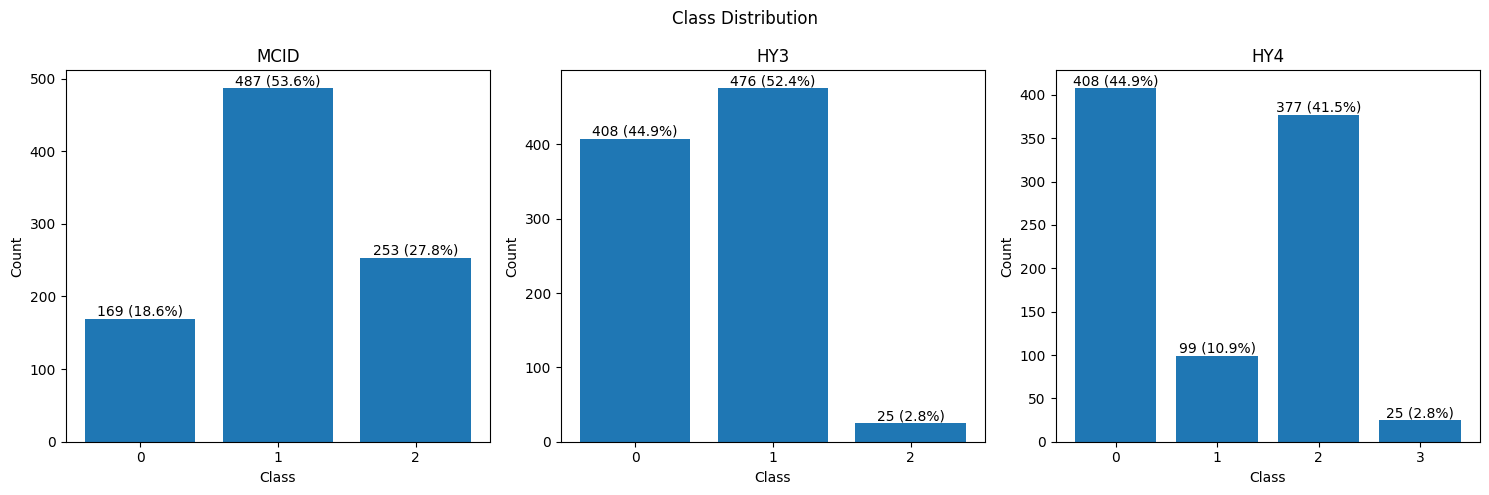

In [51]:
import matplotlib.pyplot as plt

y_MCID_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
y_HY3_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
y_HY4_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("y_MCID_NO_motor_data shape:", y_MCID_NO_motor_data.shape)
print("y_HY3_NO_motor_data shape:", y_HY3_NO_motor_data.shape)
print("y_HY4_NO_motor_data shape:", y_HY4_NO_motor_data.shape)

datasets = {
    "MCID": y_MCID_NO_motor_data,
    "HY3": y_HY3_NO_motor_data,
    "HY4": y_HY4_NO_motor_data
}

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Class Distribution")
plt.tight_layout()
plt.show()

In [55]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import pandas as pd

from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN


from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

def evaluate_models_10x10_oof_and_test_OVERSAMPLING(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
    sampling_strategy="auto",
    k_neighbors: int = 5,
):
    y = y_df.iloc[:, 0].to_numpy()
    X = X_df.to_numpy()
    classes = np.unique(y)

    def build_pipeline(estimator):
        return Pipeline([
            ("scaler", StandardScaler()),
            ("smoteenn", SMOTEENN(
                sampling_strategy=sampling_strategy,
                smote=SMOTE(
                    sampling_strategy=sampling_strategy,
                    k_neighbors=k_neighbors,
                    random_state=random_state
                ),
                random_state=random_state
            )),
            ("model", clone(estimator)),
        ])
    

    def compute_metrics(y_true, y_pred, y_proba):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "AUC_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
            "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "AUC_weighted": roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"),
        }

    def summarize(metrics_list, suffix):
        df = pd.DataFrame(metrics_list)
        mean = df.mean()
        std = df.std(ddof=1)
        return {
            f"{col}_{suffix}": f"{mean[col]:.{decimals}f} ± {std[col]:.{decimals}f}"
            for col in df.columns
        }

    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    test_summary_rows = []
    cv_summary_rows = []

    for model_name, estimator in models.items():
        print(f"Evaluating {model_name}...")

        test_metrics_all = []
        cv_metrics_all = []

        for train_idx, test_idx in outer.split(X, y):
            X_train, y_train = X[train_idx], y[train_idx]
            X_test, y_test = X[test_idx], y[test_idx]

            inner = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=random_state
            )

            oof_pred = np.zeros(len(y_train), dtype=y_train.dtype)
            oof_proba = np.zeros((len(y_train), len(classes)))

            for tr_idx, val_idx in inner.split(X_train, y_train):
                X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
                X_val = X_train[val_idx]

                model = build_pipeline(estimator)
                model.fit(X_tr, y_tr)

                oof_pred[val_idx] = model.predict(X_val)

                fold_proba = model.predict_proba(X_val)
                fold_classes = model.named_steps["model"].classes_

                aligned_proba = np.zeros((len(val_idx), len(classes)))
                for j, cls in enumerate(fold_classes):
                    aligned_proba[:, np.where(classes == cls)[0][0]] = fold_proba[:, j]

                oof_proba[val_idx] = aligned_proba

            cv_metrics_all.append(compute_metrics(y_train, oof_pred, oof_proba))

            model_full = build_pipeline(estimator)
            model_full.fit(X_train, y_train)

            test_pred = model_full.predict(X_test)
            test_proba_raw = model_full.predict_proba(X_test)
            test_classes = model_full.named_steps["model"].classes_

            test_proba = np.zeros((len(y_test), len(classes)))
            for j, cls in enumerate(test_classes):
                test_proba[:, np.where(classes == cls)[0][0]] = test_proba_raw[:, j]

            test_metrics_all.append(compute_metrics(y_test, test_pred, test_proba))

        test_summary_rows.append(
            pd.Series(summarize(test_metrics_all, "Testing"), name=model_name)
        )
        cv_summary_rows.append(
            pd.Series(summarize(cv_metrics_all, "CV"), name=model_name)
        )

    df_test_summary = pd.DataFrame(test_summary_rows)[[
        "Accuracy_Testing",
        "Precision_macro_Testing", "Recall_macro_Testing", "F1_macro_Testing", "AUC_macro_Testing",
        "Precision_weighted_Testing", "Recall_weighted_Testing", "F1_weighted_Testing", "AUC_weighted_Testing"
    ]]

    df_cv_summary = pd.DataFrame(cv_summary_rows)[[
        "Accuracy_CV",
        "Precision_macro_CV", "Recall_macro_CV", "F1_macro_CV", "AUC_macro_CV",
        "Precision_weighted_CV", "Recall_weighted_CV", "F1_weighted_CV", "AUC_weighted_CV"
    ]]

    df_final_summary = pd.concat([df_test_summary, df_cv_summary], axis=1)
    return df_final_summary

# ALL SET OF FEATURES SC M AND NM

## HY3

In [166]:
X_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)
y_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_data shape:", X_HY3_data.shape)
print("y_HY3_data shape:", y_HY3_data.shape)

X_HY3_data shape: (909, 931)
y_HY3_data shape: (909, 1)


In [167]:
df_HY3_full_OVER = evaluate_models_10x10_oof_and_test_OVERSAMPLING(
    X_df=X_HY3_data, 
    y_df=y_HY3_data, 
    models=classification_models, 
    random_state=42
)

df_HY3_full_OVER.to_csv(full_set_path_HY3 / "HY3_full_OVER.csv", index=False)
df_HY3_full_OVER.head(10)


Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7011 ± 0.0706,0.5984 ± 0.0265,0.6688 ± 0.0494,0.5445 ± 0.0595,0.7617 ± 0.0358,0.8349 ± 0.0295,0.7011 ± 0.0706,0.7097 ± 0.0764,0.7819 ± 0.0446,0.6917 ± 0.0520,0.5962 ± 0.0243,0.6715 ± 0.0611,0.5443 ± 0.0510,0.7588 ± 0.0403,0.8231 ± 0.0226,0.6917 ± 0.0520,0.6953 ± 0.0591,0.7691 ± 0.0360
random_forest,0.5985 ± 0.0653,0.5801 ± 0.0181,0.6675 ± 0.0325,0.4578 ± 0.0726,0.9354 ± 0.0101,0.7992 ± 0.0183,0.5985 ± 0.0653,0.5521 ± 0.0968,0.9487 ± 0.0102,0.6061 ± 0.0822,0.5880 ± 0.0297,0.6914 ± 0.0430,0.4767 ± 0.0943,0.9451 ± 0.0094,0.7940 ± 0.0245,0.6061 ± 0.0822,0.5558 ± 0.1194,0.9506 ± 0.0072
extra_trees,0.6542 ± 0.1006,0.6045 ± 0.0251,0.6984 ± 0.0399,0.5127 ± 0.1021,0.9357 ± 0.0057,0.8243 ± 0.0155,0.6542 ± 0.1006,0.6245 ± 0.1349,0.9508 ± 0.0074,0.6572 ± 0.1072,0.6057 ± 0.0424,0.6994 ± 0.0481,0.5248 ± 0.1130,0.9412 ± 0.0112,0.8124 ± 0.0304,0.6572 ± 0.1072,0.6259 ± 0.1383,0.9493 ± 0.0066
xgboost,0.6564 ± 0.0727,0.5969 ± 0.0144,0.6862 ± 0.0430,0.5100 ± 0.0661,0.9253 ± 0.0107,0.8257 ± 0.0155,0.6564 ± 0.0727,0.6385 ± 0.0964,0.9433 ± 0.0106,0.6667 ± 0.0689,0.6095 ± 0.0263,0.7246 ± 0.0475,0.5370 ± 0.0720,0.9387 ± 0.0114,0.8267 ± 0.0188,0.6667 ± 0.0689,0.6519 ± 0.0841,0.9476 ± 0.0069
adaboost,0.7451 ± 0.0475,0.6272 ± 0.0218,0.7377 ± 0.0691,0.5970 ± 0.0456,0.9116 ± 0.0116,0.8554 ± 0.0156,0.7451 ± 0.0475,0.7544 ± 0.0484,0.9243 ± 0.0156,0.7390 ± 0.0647,0.6318 ± 0.0330,0.7406 ± 0.0376,0.6031 ± 0.0667,0.9066 ± 0.0251,0.8448 ± 0.0194,0.7390 ± 0.0647,0.7412 ± 0.0687,0.9023 ± 0.0279
svm,0.5755 ± 0.1023,0.5096 ± 0.1691,0.5849 ± 0.1036,0.4310 ± 0.1332,0.9333 ± 0.0154,0.6703 ± 0.2349,0.5755 ± 0.1023,0.4941 ± 0.1640,0.9444 ± 0.0086,0.5882 ± 0.0988,0.5832 ± 0.0454,0.6152 ± 0.0483,0.4659 ± 0.1119,0.9357 ± 0.0165,0.7582 ± 0.0439,0.5882 ± 0.0988,0.5132 ± 0.1528,0.9437 ± 0.0082
logistic_regression,0.7022 ± 0.0482,0.6131 ± 0.0161,0.7286 ± 0.0472,0.5594 ± 0.0421,0.9339 ± 0.0177,0.8419 ± 0.0155,0.7022 ± 0.0482,0.7032 ± 0.0565,0.9421 ± 0.0136,0.7006 ± 0.0628,0.6193 ± 0.0238,0.7424 ± 0.0365,0.5690 ± 0.0604,0.9364 ± 0.0082,0.8371 ± 0.0184,0.7006 ± 0.0628,0.6975 ± 0.0736,0.9434 ± 0.0038
knn,0.4711 ± 0.0060,0.3623 ± 0.1666,0.6312 ± 0.0318,0.3084 ± 0.0078,0.7192 ± 0.0135,0.4764 ± 0.2587,0.4711 ± 0.0060,0.3412 ± 0.0105,0.6472 ± 0.0136,0.4733 ± 0.0055,0.4660 ± 0.1597,0.6396 ± 0.0152,0.3169 ± 0.0098,0.7337 ± 0.0116,0.6319 ± 0.2447,0.4733 ± 0.0055,0.3428 ± 0.0043,0.6524 ± 0.0075
gaussian_nb,0.5198 ± 0.0859,0.4532 ± 0.0598,0.5529 ± 0.0492,0.4041 ± 0.0749,0.6626 ± 0.0303,0.6286 ± 0.0901,0.5198 ± 0.0859,0.5228 ± 0.1068,0.6611 ± 0.0339,0.5112 ± 0.0618,0.4582 ± 0.0378,0.5622 ± 0.0332,0.4021 ± 0.0607,0.6663 ± 0.0263,0.6327 ± 0.0544,0.5112 ± 0.0618,0.5141 ± 0.0858,0.6562 ± 0.0279


# SET OF FEATURES M

## HY3

In [56]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[valid_cols]
y_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_motor_data shape:", X_HY3_motor_data.shape)
print("y_HY3_motor_data shape:", y_HY3_motor_data.shape)

X_HY3_motor_data shape: (909, 300)
y_HY3_motor_data shape: (909, 1)


In [169]:
df_HY3_motor_data_OVER = evaluate_models_10x10_oof_and_test_OVERSAMPLING(
    X_df=X_HY3_motor_data, 
    y_df=y_HY3_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY3_motor_data_OVER.to_csv(full_set_path_HY3 / "HY3_motor_data_OVER.csv", index=False)
df_HY3_motor_data_OVER.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8275 ± 0.0289,0.6438 ± 0.0259,0.6943 ± 0.0293,0.6460 ± 0.0299,0.8006 ± 0.0177,0.8666 ± 0.0154,0.8275 ± 0.0289,0.8351 ± 0.0252,0.8604 ± 0.0203,0.8305 ± 0.0169,0.6638 ± 0.0236,0.7431 ± 0.0467,0.6774 ± 0.0305,0.8257 ± 0.0255,0.8651 ± 0.0113,0.8305 ± 0.0169,0.8372 ± 0.0150,0.8623 ± 0.0127
random_forest,0.8835 ± 0.0142,0.7278 ± 0.0396,0.7807 ± 0.0522,0.7390 ± 0.0363,0.9470 ± 0.0087,0.9023 ± 0.0076,0.8835 ± 0.0142,0.8855 ± 0.0120,0.9585 ± 0.0076,0.8939 ± 0.0081,0.7419 ± 0.0247,0.7883 ± 0.0284,0.7573 ± 0.0253,0.9556 ± 0.0071,0.9063 ± 0.0050,0.8939 ± 0.0081,0.8954 ± 0.0072,0.9622 ± 0.0025
extra_trees,0.8861 ± 0.0108,0.7142 ± 0.0407,0.7505 ± 0.0570,0.7225 ± 0.0409,0.9449 ± 0.0125,0.9004 ± 0.0070,0.8861 ± 0.0108,0.8874 ± 0.0092,0.9578 ± 0.0094,0.8936 ± 0.0090,0.7427 ± 0.0282,0.7792 ± 0.0257,0.7550 ± 0.0275,0.9537 ± 0.0052,0.9042 ± 0.0055,0.8936 ± 0.0090,0.8947 ± 0.0079,0.9609 ± 0.0030
xgboost,0.8626 ± 0.0138,0.6850 ± 0.0280,0.7491 ± 0.0500,0.6972 ± 0.0326,0.9406 ± 0.0114,0.8905 ± 0.0084,0.8626 ± 0.0138,0.8672 ± 0.0121,0.9568 ± 0.0065,0.8736 ± 0.0110,0.7155 ± 0.0223,0.7805 ± 0.0383,0.7329 ± 0.0265,0.9505 ± 0.0054,0.8941 ± 0.0070,0.8736 ± 0.0110,0.8763 ± 0.0103,0.9590 ± 0.0036
adaboost,0.8751 ± 0.0190,0.7057 ± 0.0284,0.7649 ± 0.0358,0.7210 ± 0.0241,0.9305 ± 0.0114,0.8917 ± 0.0165,0.8751 ± 0.0190,0.8789 ± 0.0179,0.9378 ± 0.0143,0.8830 ± 0.0094,0.7258 ± 0.0172,0.7943 ± 0.0184,0.7478 ± 0.0180,0.9414 ± 0.0063,0.8976 ± 0.0058,0.8830 ± 0.0094,0.8865 ± 0.0085,0.9450 ± 0.0047
svm,0.8722 ± 0.0150,0.6878 ± 0.0401,0.7187 ± 0.0573,0.6940 ± 0.0456,0.9390 ± 0.0098,0.8866 ± 0.0093,0.8722 ± 0.0150,0.8731 ± 0.0132,0.9538 ± 0.0076,0.8792 ± 0.0102,0.7236 ± 0.0235,0.7399 ± 0.0217,0.7264 ± 0.0190,0.9453 ± 0.0086,0.8881 ± 0.0052,0.8792 ± 0.0102,0.8792 ± 0.0088,0.9567 ± 0.0038
logistic_regression,0.8531 ± 0.0181,0.6839 ± 0.0175,0.7883 ± 0.0533,0.6965 ± 0.0215,0.9384 ± 0.0099,0.8966 ± 0.0066,0.8531 ± 0.0181,0.8614 ± 0.0151,0.9467 ± 0.0095,0.8593 ± 0.0105,0.6925 ± 0.0128,0.7923 ± 0.0232,0.7107 ± 0.0169,0.9409 ± 0.0049,0.8961 ± 0.0042,0.8593 ± 0.0105,0.8673 ± 0.0092,0.9483 ± 0.0026
knn,0.6901 ± 0.0307,0.6113 ± 0.0113,0.7301 ± 0.0397,0.5489 ± 0.0264,0.8547 ± 0.0193,0.8438 ± 0.0148,0.6901 ± 0.0307,0.6931 ± 0.0354,0.8507 ± 0.0147,0.7049 ± 0.0331,0.6246 ± 0.0144,0.7594 ± 0.0290,0.5756 ± 0.0364,0.8638 ± 0.0161,0.8460 ± 0.0079,0.7049 ± 0.0331,0.7072 ± 0.0349,0.8551 ± 0.0113
gaussian_nb,0.7974 ± 0.0256,0.6513 ± 0.0133,0.7949 ± 0.0509,0.6444 ± 0.0208,0.8899 ± 0.0288,0.8877 ± 0.0104,0.7974 ± 0.0256,0.8275 ± 0.0215,0.9093 ± 0.0128,0.8153 ± 0.0118,0.6637 ± 0.0101,0.8109 ± 0.0258,0.6713 ± 0.0144,0.8815 ± 0.0176,0.8844 ± 0.0093,0.8153 ± 0.0118,0.8403 ± 0.0097,0.8994 ± 0.0101


# turning

In [64]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import pandas as pd

from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical


def evaluate_models_nested_bayes_smoteenn(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
    sampling_strategy="auto",
    k_neighbors: int = 5,
    n_iter_search: int = 25,
    n_jobs_search: int = -1,
):
    y = y_df.iloc[:, 0].to_numpy()
    X = X_df.to_numpy()
    classes = np.unique(y)

    def build_pipeline(estimator):
        return Pipeline([
            ("scaler", StandardScaler()),
            ("smoteenn", SMOTEENN(
                sampling_strategy=sampling_strategy,
                smote=SMOTE(
                    sampling_strategy=sampling_strategy,
                    k_neighbors=k_neighbors,
                    random_state=random_state
                ),
                random_state=random_state
            )),
            ("model", clone(estimator)),
        ])

    def get_search_spaces(model_name):

        spaces = {

            "decision_tree": {
                "model__max_depth": Integer(2, 30),
                "model__min_samples_split": Integer(2, 20),
                "model__min_samples_leaf": Integer(1, 10),
                "model__criterion": Categorical(["gini", "entropy"]),
                "model__max_features": Categorical([None, "sqrt"]),
            },

            "random_forest": {
                "model__n_estimators": Integer(200, 800),
                "model__max_depth": Integer(4, 30),
                "model__min_samples_split": Integer(2, 20),
                "model__min_samples_leaf": Integer(1, 10),
                "model__max_features": Categorical(["sqrt", "log2"]),
                "model__bootstrap": Categorical([True]),
            },

            "extra_trees": {
                "model__n_estimators": Integer(200, 800),
                "model__max_depth": Integer(4, 30),
                "model__min_samples_split": Integer(2, 20),
                "model__min_samples_leaf": Integer(1, 10),
                "model__max_features": Categorical(["sqrt", "log2"]),
            },

            "xgboost": {
                "model__n_estimators": Integer(200, 600),
                "model__max_depth": Integer(3, 10),
                "model__learning_rate": Real(0.01, 0.3, prior="log-uniform"),
                "model__subsample": Real(0.6, 1.0),
                "model__colsample_bytree": Real(0.6, 1.0),
                "model__min_child_weight": Integer(1, 10),
                "model__gamma": Real(1e-8, 5.0, prior="log-uniform"),
                "model__reg_alpha": Real(1e-8, 5.0, prior="log-uniform"),
                "model__reg_lambda": Real(1e-8, 5.0, prior="log-uniform"),
            },

            "adaboost": {
                "model__n_estimators": Integer(50, 500),
                "model__learning_rate": Real(0.01, 1.0, prior="log-uniform"),
            },

            "svm": {
                "model__C": Real(1e-3, 1e3, prior="log-uniform"),
                "model__gamma": Real(1e-5, 1.0, prior="log-uniform"),
                "model__kernel": Categorical(["rbf"]),
            },

            "logistic_regression": {
                "model__C": Real(1e-4, 1e2, prior="log-uniform"),
                "model__solver": Categorical(["lbfgs", "saga"]),
                "model__penalty": Categorical(["l2"]),
            },

            "knn": {
                "model__n_neighbors": Integer(3, 51),
                "model__weights": Categorical(["uniform", "distance"]),
                "model__p": Integer(1, 2),
            },

            "gaussian_nb": {
                "model__var_smoothing": Real(1e-10, 1e-6, prior="log-uniform"),
            },
        }

        if model_name not in spaces:
            raise ValueError(f"No hay search space definido para {model_name}")

        return spaces[model_name]

    def compute_metrics(y_true, y_pred, y_proba):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "AUC_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
            "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "AUC_weighted": roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"),
        }

    def summarize(metrics_list, suffix):
        df = pd.DataFrame(metrics_list)
        mean = df.mean(numeric_only=True)
        std = df.std(ddof=1, numeric_only=True)
        return {
            f"{col}_{suffix}": f"{mean[col]:.{decimals}f} ± {std[col]:.{decimals}f}"
            for col in df.columns
        }

    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    test_summary_rows = []
    cv_summary_rows = []
    best_params_rows = []

    for model_name, estimator in models.items():
        print(f"Evaluating {model_name} with Bayesian Search...")

        test_metrics_all = []
        cv_metrics_all = []
        best_params_per_outer_fold = []

        search_spaces = get_search_spaces(model_name)

        for fold_id, (train_idx, test_idx) in enumerate(outer.split(X, y), start=1):
            X_train, y_train = X[train_idx], y[train_idx]
            X_test, y_test = X[test_idx], y[test_idx]

            inner = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=random_state
            )

            base_pipeline = build_pipeline(estimator)

            opt = BayesSearchCV(
                estimator=base_pipeline,
                search_spaces=search_spaces,
                n_iter=n_iter_search,
                scoring="f1_macro",
                cv=inner,
                n_jobs=n_jobs_search,
                refit=True,
                random_state=random_state,
                verbose=0,
            )

            opt.fit(X_train, y_train)

            best_model = opt.best_estimator_
            best_params_per_outer_fold.append(opt.best_params_)

            cv_metrics_all.append({
                "F1_macro": opt.best_score_,
            })

            test_pred = best_model.predict(X_test)
            test_proba_raw = best_model.predict_proba(X_test)

            test_classes = best_model.named_steps["model"].classes_
            test_proba = np.zeros((len(y_test), len(classes)))
            for j, cls in enumerate(test_classes):
                test_proba[:, np.where(classes == cls)[0][0]] = test_proba_raw[:, j]

            test_metrics_all.append(compute_metrics(y_test, test_pred, test_proba))

            print(f"  Fold {fold_id}: best inner F1_macro = {opt.best_score_:.4f}")

        test_summary_rows.append(
            pd.Series(summarize(test_metrics_all, "Testing"), name=model_name)
        )
        cv_summary_rows.append(
            pd.Series(summarize(cv_metrics_all, "CV"), name=model_name)
        )
        best_params_rows.append(
            pd.Series({"Best_Params_Outer_Folds": best_params_per_outer_fold}, name=model_name)
        )

    df_test_summary = pd.DataFrame(test_summary_rows)[[
        "Accuracy_Testing",
        "Precision_macro_Testing", "Recall_macro_Testing", "F1_macro_Testing", "AUC_macro_Testing",
        "Precision_weighted_Testing", "Recall_weighted_Testing", "F1_weighted_Testing", "AUC_weighted_Testing"
    ]]

    df_cv_summary = pd.DataFrame(cv_summary_rows)[[
        "F1_macro_CV"
    ]]

    df_best_params = pd.DataFrame(best_params_rows)

    df_final_summary = pd.concat(
        [df_test_summary, df_cv_summary, df_best_params],
        axis=1
    )

    return df_final_summary

In [ ]:
df_HY3_motor_data_OVER_bayes = evaluate_models_nested_bayes_smoteenn(
    X_df=X_HY3_motor_data, 
    y_df=y_HY3_motor_data, 
    models=classification_models,
    outer_splits=5,
    inner_splits=5,
    n_iter_search=2,
    random_state=42
)

df_HY3_motor_data_OVER_bayes.head(10)

Evaluating decision_tree with Bayesian Search...
  Fold 1: best inner F1_macro = 0.7029
  Fold 2: best inner F1_macro = 0.6871


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  Fold 3: best inner F1_macro = 0.7099
  Fold 4: best inner F1_macro = 0.6768
  Fold 5: best inner F1_macro = 0.7069
Evaluating random_forest with Bayesian Search...
  Fold 1: best inner F1_macro = 0.7710


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  Fold 2: best inner F1_macro = 0.7964


...

/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  Fold 4: best inner F1_macro = 0.7276


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  Fold 5: best inner F1_macro = 0.7450
Evaluating xgboost with Bayesian Search...
  Fold 1: best inner F1_macro = 0.7250
  Fold 2: best inner F1_macro = 0.7349
  Fold 3: best inner F1_macro = 0.7888
  Fold 4: best inner F1_macro = 0.7144
  Fold 5: best inner F1_macro = 0.7421
Evaluating adaboost with Bayesian Search...
  Fold 1: best inner F1_macro = 0.7630
  Fold 2: best inner F1_macro = 0.7542
  Fold 3: best inner F1_macro = 0.7452
  Fold 4: best inner F1_macro = 0.7371
  Fold 5: best inner F1_macro = 0.6941
Evaluating svm with Bayesian Search...
  Fold 1: best inner F1_macro = 0.2499
  Fold 2: best inner F1_macro = 0.2542
  Fold 3: best inner F1_macro = 0.2381
  Fold 4: best inner F1_macro = 0.2472
  Fold 5: best inner F1_macro = 0.2378
Evaluating logistic_regression with Bayesian Search...
  Fold 1: best inner F1_macro = 0.7252
  Fold 2: best inner F1_macro = 0.7118
  Fold 3: best inner F1_macro = 0.7172
  Fold 4: best inner F1_macro = 0.7301
  Fold 5: best inner F1_macro = 0.7312


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,F1_macro_CV,Best_Params_Outer_Folds
decision_tree,0.8015 ± 0.0343,0.6238 ± 0.0438,0.6717 ± 0.0521,0.6250 ± 0.0465,0.8240 ± 0.0123,0.8410 ± 0.0313,0.8015 ± 0.0343,0.8096 ± 0.0334,0.8799 ± 0.0123,0.6967 ± 0.0142,"[{'model__criterion': 'entropy', 'model__max_d..."
random_forest,0.8967 ± 0.0180,0.7561 ± 0.0760,0.7610 ± 0.0372,0.7508 ± 0.0518,0.9491 ± 0.0096,0.9043 ± 0.0126,0.8967 ± 0.0180,0.8976 ± 0.0148,0.9580 ± 0.0095,0.7788 ± 0.0110,"[{'model__bootstrap': True, 'model__max_depth'..."
extra_trees,0.8667 ± 0.0106,0.6944 ± 0.0083,0.8058 ± 0.0348,0.7132 ± 0.0121,0.9498 ± 0.0091,0.9040 ± 0.0055,0.8667 ± 0.0106,0.8758 ± 0.0071,0.9583 ± 0.0091,0.7492 ± 0.0178,"[{'model__max_depth': 26, 'model__max_features..."
xgboost,0.8637 ± 0.0180,0.6762 ± 0.0244,0.7498 ± 0.0689,0.6880 ± 0.0333,0.9408 ± 0.0109,0.8958 ± 0.0117,0.8637 ± 0.0180,0.8707 ± 0.0162,0.9554 ± 0.0072,0.7410 ± 0.0287,[{'model__colsample_bytree': 0.934955342221313...
adaboost,0.8740 ± 0.0084,0.6957 ± 0.0572,0.7278 ± 0.0358,0.6996 ± 0.0387,0.9310 ± 0.0078,0.8909 ± 0.0061,0.8740 ± 0.0084,0.8790 ± 0.0053,0.9372 ± 0.0140,0.7387 ± 0.0268,"[{'model__learning_rate': 0.4729080547055919, ..."
svm,0.2454 ± 0.0239,0.3221 ± 0.0092,0.4959 ± 0.0177,0.2347 ± 0.0152,0.8690 ± 0.0279,0.4211 ± 0.0126,0.2454 ± 0.0239,0.2896 ± 0.0195,0.9255 ± 0.0110,0.2454 ± 0.0073,"[{'model__C': 0.28881766539144715, 'model__gam..."
logistic_regression,0.8535 ± 0.0135,0.6835 ± 0.0141,0.7884 ± 0.0478,0.6986 ± 0.0179,0.9406 ± 0.0117,0.8942 ± 0.0095,0.8535 ± 0.0135,0.8617 ± 0.0106,0.9491 ± 0.0131,0.7231 ± 0.0084,"[{'model__C': 0.028881766539144718, 'model__pe..."
knn,0.6293 ± 0.0283,0.5944 ± 0.0112,0.7095 ± 0.0344,0.4951 ± 0.0279,0.8991 ± 0.0201,0.8231 ± 0.0205,0.6293 ± 0.0283,0.6137 ± 0.0333,0.8978 ± 0.0095,0.5029 ± 0.0432,"[{'model__n_neighbors': 23, 'model__p': 2, 'mo..."
gaussian_nb,0.8044 ± 0.0233,0.6501 ± 0.0133,0.7805 ± 0.0634,0.6459 ± 0.0190,0.8748 ± 0.0332,0.8869 ± 0.0093,0.8044 ± 0.0233,0.8344 ± 0.0185,0.9078 ± 0.0132,0.6764 ± 0.0151,[{'model__var_smoothing': 4.36933994751032e-09...


In [65]:
Random_forest_result = evaluate_models_nested_bayes_smoteenn(
    X_df=X_HY3_motor_data, 
    y_df=y_HY3_motor_data, 
    models={"random_forest": RandomForestClassifier(
                                random_state=42,
                                n_jobs=-1,
                                class_weight="balanced")},
    outer_splits=10,
    inner_splits=5,
    n_iter_search=120,
    random_state=42
)

Random_forest_result

Evaluating random_forest with Bayesian Search...
  Fold 1: best inner F1_macro = 0.7763
  Fold 2: best inner F1_macro = 0.8173
  Fold 3: best inner F1_macro = 0.7865
  Fold 4: best inner F1_macro = 0.7954
  Fold 5: best inner F1_macro = 0.8027
  Fold 6: best inner F1_macro = 0.8196
  Fold 7: best inner F1_macro = 0.8121
  Fold 8: best inner F1_macro = 0.7620
  Fold 9: best inner F1_macro = 0.7957
  Fold 10: best inner F1_macro = 0.7861


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,F1_macro_CV,Best_Params_Outer_Folds
random_forest,0.8930 ± 0.0157,0.7367 ± 0.0642,0.7593 ± 0.0577,0.7374 ± 0.0509,0.9502 ± 0.0083,0.9045 ± 0.0091,0.8930 ± 0.0157,0.8939 ± 0.0129,0.9612 ± 0.0072,0.7954 ± 0.0184,"[{'model__bootstrap': True, 'model__max_depth'..."
